In [1]:
import os 
import sys
import pandas as pd 
import numpy as np 

OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

import plot_functions as pf
import color_function as cf 
import voxel_functions as vf 


In [2]:
import importlib 

importlib.reload(pf)
importlib.reload(cf)
importlib.reload(vf)

<module 'voxel_functions' from '/mnt/data2/Justice/OR_learning/utils/voxel_functions.py'>

In [3]:
Cbc_cav_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_cav_coords2.pkl')
Cbc_res_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_res_coords2.pkl')

Cbc_cav_coords = {_key: Cbc_cav_coords[_key] for _key in list(Cbc_cav_coords) if _key.split('_')[0] == 'Or2t43'}
Cbc_res_coords = {_key: Cbc_res_coords[_key] for _key in list(Cbc_res_coords) if _key.split('_')[0] == 'Or2t43'}


center_reference = np.load('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_center_reference.npy')
voxels, grid_shape = vf.voxelize_cavity(cavity_coords = Cbc_cav_coords,
                                      residue_coords = Cbc_res_coords,
                                      resolution = 1, 
                                      encode_method='res', 
                                      esm_order = list(Cbc_cav_coords), 
                                      cube_dim = 32, reference_center = center_reference, 
                                      vdw_radius = False, 
                                      sparse_mode = True)
print(f'Grid shape: {grid_shape}')

Encoding voxels via res...
Generating voxels. . .


100%|██████████| 5/5 [00:00<00:00, 161.36it/s]

Grid shape: [32 32 32]


In [ ]:
"""
for figure cavity visualization... 
"""
import plotly.graph_objects as go 
from scipy.spatial.transform import Rotation as R

# default_rot = R.from_euler("xyz", [140, 320, 180], degrees=True)
default_rot = R.from_euler("xyz", [160, 330, 120], degrees=True)


plot_voxel = 'Or2t43_1'
res = Cbc_res_coords[plot_voxel][:, 0]
color = cf.distinct_colors(np.unique(list(res)), category='tab20')

res_data = ()
for _res in np.unique(res):
    plot_res = [Cbc_res_coords[plot_voxel][i, 3:6].astype(float) for i, r in enumerate(res) if r == _res]
    
    X, Y, Z = np.array(plot_res)[:,0], np.array(plot_res)[:,1], np.array(plot_res)[:,2]
    coords = np.vstack([X, Y, Z ]).T         # shape (N, 3)
    coords_rot = default_rot.apply(coords)
    X, Y, Z = coords_rot[:,0], coords_rot[:,1], coords_rot[:,2]
    
    res_data = res_data + (pf.plot_coordinates(np.array([X,Y,Z]).T,
                                colors = color[_res],
                                size = 7, 
                                opacity =0.8).data)

coords = Cbc_cav_coords[plot_voxel]
coords_rot = default_rot.apply(coords)
x, y, z = coords_rot[:,0], coords_rot[:,1], coords_rot[:,2]
cavity = pf.plot_coordinates(np.array([x,y,z]).T, colors = 'black', opacity =0.05).data

fig = go.Figure(data = cavity + res_data)
fig.update_layout(showlegend = False)
fig = pf._plotly_blank_style(fig)
fig.show()

# fig.write_html(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/DEMO_cavity_voxels.html')
fig.write_image(f'/mnt/data2/Justice/OR_learning/output/pub_Figures/model/DEMO_cavity_voxels_rotated.svg')

### Extract Model Features

## SpatialESM Chem classification

#### Re-Define and run model for extraction 

In [57]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.decomposition import PCA

# Replace with saved best model dir
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/final_model/20251118_173316_lr0.0001_bs4_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

params_path = os.path.join(base_dir, "params.json")
model_path = os.path.join(base_dir, "best_model.pt")

# Load pS6-IP data 
ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()

ps6_df = ps6_df[ps6_df.odor_category != 'Others']

# Predefine the family classes once
ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODORS = sorted(ps6_df.odor.unique())
ODOR_TO_CAT = dict(zip(ps6_df.odor, ps6_df.odor_category))

ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODORS)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODORS)}
NUM_ODORS = len(ODORS)


with open(params_path, "r") as f:
    params = json.load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset definition 
class ORVoxelDataset(Dataset):
    def __init__(self, voxel_tensor, or_index_map, ps6_df, score_threshold=2.0):
        """
        voxel_tensor: [N_or, D, H, W, C]
        or_index_map: dict mapping OR name -> index in voxel_tensor
        ps6_df: dataframe containing DL_OR, odor_category, activation_zscore
        score_threshold: only include categories with zscore >= threshold
        """
        self.voxel_tensor = voxel_tensor
        self.or_names = list(or_index_map.keys())
        self.or_indices = list(or_index_map.values())

        self.targets = []

        for or_name in self.or_names:
            clean_or_name = or_name.split('_')[0].lower()
            df_sub = ps6_df[(ps6_df.DL_OR.str.lower() == clean_or_name) &
                            (ps6_df.activation_zscore >= score_threshold)]
            
            # print(clean_or_name, ps6_df.DL_OR.str.lower().unique())

            # Build binary target vector: 1 if activation_zscore >= threshold else 0
            target_vec = np.zeros(NUM_ODORS, dtype=np.float32)
            for _, row in df_sub.iterrows():
                idx = ODOR_TO_IDX[row.odor]
                target_vec[idx] = 1.0 

            self.targets.append(target_vec)

        self.targets = torch.tensor(np.array(self.targets), dtype=torch.float32)

    def __len__(self):
        return len(self.or_names)

    def __getitem__(self, idx):
        voxel = self.voxel_tensor[self.or_indices[idx]]
        target = self.targets[idx]
        return voxel, target
    
    
# ---------------- Model ----------------
class OROdorCNN(nn.Module):
    def __init__(self, voxel_shape=(41, 42, 65), num_classes=None,
                 kernel_size=3, hidden_dim=256,
                 num_conv_layers=2, conv_channels=(16, 32),
                 dropout=0.0, pool_type='AVG'):
        super().__init__()
        C, D, H, W = voxel_shape
        assert num_classes is not None, "num_classes must be set to number of odor categories"

        layers = []
        in_channels = C
        pool = nn.AvgPool3d if pool_type == 'AVG' else nn.MaxPool3d

        for i in range(num_conv_layers):
            out_channels = conv_channels[i]
            layers.append(
                nn.Conv3d(in_channels, out_channels,
                          kernel_size=kernel_size,
                          padding=kernel_size // 2)
            )
            layers.append(nn.ReLU())
            layers.append(pool(2))
            in_channels = out_channels

        self.cnn = nn.Sequential(*layers)

        # Compute flattened CNN output size
        dummy = torch.zeros(1, C, D, H, W)
        with torch.no_grad():
            out = self.cnn(dummy)
        self.cnn_out_dim = out.reshape(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(self.cnn_out_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)  # multi-label logits
        )

    def forward(self, voxel):
        # voxel: [B, D, H, W, C] → reorder for Conv3d
        voxel = voxel.permute(0, 4, 1, 2, 3)  # [B, C, D, H, W]
        cnn_out = self.cnn(voxel)
        cnn_out = cnn_out.reshape(cnn_out.size(0), -1)
        return self.fc(cnn_out)  # logits [B, num_classes]

    


In [ ]:
# """
# Replicating the exact dataset model is trained on. 

# It's important as the grid shape needs to match up as well. Or voxel grid may be misaligned. 
# """

# import random

# random.seed(0)

# # Load pS6-IP data 
# ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
# ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
# ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()

# activated_ps6_df = ps6_df[ps6_df.activation_zscore >= 2]
# zero_ps6_df = ps6_df[((ps6_df.activation_zscore <= 0.2) | 
#                      (ps6_df.activation_zscore >= -0.2)) & 
#                      (~ps6_df.DL_OR.isin(list(activated_ps6_df.DL_OR.unique())))]

# ps6_df = ps6_df[ps6_df.odor_category != 'Others']

# Cbc_cav_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_cav_coords2.pkl')
# Cbc_res_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_res_coords2.pkl')

# # sample_ORs = random.sample(list(zero_ps6_df.DL_OR.unique()), 
# #                            len(list(activated_ps6_df.DL_OR.unique())) // 6) + list(activated_ps6_df.DL_OR.unique())
# # sample_ORs = [_ORs.lower() for _ORs in sample_ORs]

# # Cbc_cav_coords = {_key: Cbc_cav_coords[_key] for _key in list(Cbc_cav_coords) if _key.split('_')[0].lower() in sample_ORs}
# # Cbc_res_coords = {_key: Cbc_res_coords[_key] for _key in list(Cbc_res_coords) if _key.split('_')[0].lower() in sample_ORs}

# # Taking only x prediction of each AF3
# # Cbc_cav_coords = {_key: Cbc_cav_coords[_key] for _key in list(Cbc_cav_coords) if _key.split('_')[1] in (['0','1','2'])}
# # Cbc_res_coords = {_key: Cbc_res_coords[_key] for _key in list(Cbc_res_coords) if _key.split('_')[1] in (['0','1','2'])}
# Cbc_cav_coords = {_key: Cbc_cav_coords[_key] for _key in list(Cbc_cav_coords) if _key.split('_')[1] in (['0'])}
# Cbc_res_coords = {_key: Cbc_res_coords[_key] for _key in list(Cbc_res_coords) if _key.split('_')[1] in (['0'])}
# print('Cbc coords files loaded. . .')

# OR_esm = np.load('/mnt/data2/Justice/OR_learning/files/ESM/reduced_OR_esm.npy', allow_pickle=True).item()
# # Filter Cbc coordinates for ESM keys 
# exclude_OR = [_key for _key in Cbc_cav_coords if _key.split('_')[0] not in OR_esm.keys()]
# if exclude_OR: 
#     Cbc_cav_coords = {_key: _values for _key, _values in Cbc_cav_coords.items() if _key not in exclude_OR}
#     Cbc_res_coords = {_key: _values for _key, _values in Cbc_res_coords.items() if _key not in exclude_OR}

# center_reference = np.load('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_center_reference.npy')
# voxels, grid_shape = vf.voxelize_cavity(cavity_coords = Cbc_cav_coords,
#                                       residue_coords = Cbc_res_coords,
#                                       resolution = 1, 
#                                       encode_method='esm', 
#                                       OR_esm = OR_esm, 
#                                       esm_order = list(Cbc_cav_coords), 
#                                       cube_dim = 32, reference_center = center_reference, 
#                                       vdw_radius = True, 
#                                       sparse_mode = False)
# print(f'Grid shape: {grid_shape}')

# voxel_names = list(Cbc_cav_coords.keys())

# del OR_esm
# del Cbc_cav_coords

In [59]:
"""
Replicating the exact dataset model is trained on. 

It's important as the grid shape needs to match up as well. Or voxel grid may be misaligned. 

Read in human data to map on the map as well 
"""

import random

random.seed(0)

# Load pS6-IP data 
ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()

activated_ps6_df = ps6_df[ps6_df.activation_zscore >= 2]
zero_ps6_df = ps6_df[((ps6_df.activation_zscore <= 0.2) | 
                     (ps6_df.activation_zscore >= -0.2)) & 
                     (~ps6_df.DL_OR.isin(list(activated_ps6_df.DL_OR.unique())))]

ps6_df = ps6_df[ps6_df.odor_category != 'Others']

hOR_to_include = ['OR10J5','OR11A1','OR2W1','OR2J2','OR5P3','OR10G4','OR10G7',
                  'OR51E1','OR51E2','OR1A1','OR10A6','OR2J3','OR5A1','OR2T1',
                  'OR2T6','OR2T11']

# Read in human OR voxels
Hs_Cbc_cav_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/human/AF3_dict_Cbc_cav_coords.pkl')
Hs_Cbc_res_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/human/AF3_dict_Cbc_res_coords.pkl')
# Subset voxels
Hs_Cbc_cav_coords = {_k: _v for _k, _v in Hs_Cbc_cav_coords.items() if _k.split('_')[0] in hOR_to_include}
Hs_Cbc_res_coords = {_k: _v for _k, _v in Hs_Cbc_res_coords.items() if _k.split('_')[0] in hOR_to_include}

Mm_Cbc_cav_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_cav_coords2.pkl')
Mm_Cbc_res_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_res_coords2.pkl')

# sample_ORs = random.sample(list(zero_ps6_df.DL_OR.unique()), 
#                            len(list(activated_ps6_df.DL_OR.unique())) // 6) + list(activated_ps6_df.DL_OR.unique())
# sample_ORs = [_ORs.lower() for _ORs in sample_ORs]

# Mm_Cbc_cav_coords = {_key: Mm_Cbc_cav_coords[_key] for _key in list(Mm_Cbc_cav_coords) if _key.split('_')[0].lower() in sample_ORs}
# Mm_Cbc_res_coords = {_key: Mm_Cbc_res_coords[_key] for _key in list(Mm_Cbc_res_coords) if _key.split('_')[0].lower() in sample_ORs}

# Taking only x prediction of each AF3
# Mm_Cbc_cav_coords = {_key: Mm_Cbc_cav_coords[_key] for _key in list(Mm_Cbc_cav_coords) if _key.split('_')[1] in (['0','1','2'])}
# Mm_Cbc_res_coords = {_key: Mm_Cbc_res_coords[_key] for _key in list(Mm_Cbc_res_coords) if _key.split('_')[1] in (['0','1','2'])}
Mm_Cbc_cav_coords = {_key: Mm_Cbc_cav_coords[_key] for _key in list(Mm_Cbc_cav_coords) if _key.split('_')[1] in (['0'])}
Mm_Cbc_res_coords = {_key: Mm_Cbc_res_coords[_key] for _key in list(Mm_Cbc_res_coords) if _key.split('_')[1] in (['0'])}
print('Cbc coords files loaded. . .')

# Combine Ms and Hs voxels 
# Cbc_cav_coords = Mm_Cbc_cav_coords | Hs_Cbc_cav_coords
# Cbc_res_coords = Mm_Cbc_res_coords | Hs_Cbc_res_coords

# Only use mouse data
Cbc_cav_coords = Mm_Cbc_cav_coords
Cbc_res_coords = Mm_Cbc_res_coords

del Mm_Cbc_cav_coords, Mm_Cbc_res_coords, Hs_Cbc_cav_coords, Hs_Cbc_res_coords

# Combined Mm and Hs ESM
OR_esm = np.load('/mnt/data2/Justice/OR_learning/files/ESM/combined/reduced_OR_esm_mmhs.npy', allow_pickle= True).item()
OR_esm =  {_key: _values for _key, _values in OR_esm.items() if not _key.isupper()} # Exclude human OR 

# Filter Cbc coordinates for ESM keys 
exclude_OR = []
# exclude_OR.extend([_k for _k in Cbc_res_coords.keys() if _k.isupper()]) # Exclude human OR 
exclude_OR.extend([_key for _key in Cbc_cav_coords if _key.split('_')[0] not in OR_esm.keys()]) # Exclude none overlapping OR names in ESM vs coords
if exclude_OR: 
    Cbc_cav_coords = {_key: _values for _key, _values in Cbc_cav_coords.items() if _key not in exclude_OR}
    Cbc_res_coords = {_key: _values for _key, _values in Cbc_res_coords.items() if _key not in exclude_OR}

center_reference = np.load('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_center_reference.npy')
voxels, grid_shape = vf.voxelize_cavity(cavity_coords = Cbc_cav_coords,
                                      residue_coords = Cbc_res_coords,
                                      resolution = 1, 
                                      encode_method='esm', 
                                      OR_esm = OR_esm, 
                                      esm_order = list(Cbc_cav_coords), 
                                      cube_dim = 32, reference_center = center_reference, 
                                      vdw_radius = True, 
                                      sparse_mode = False)
print(f'Grid shape: {grid_shape}')

voxel_names = list(Cbc_cav_coords.keys())

del OR_esm
del Cbc_cav_coords


Cbc coords files loaded. . .
Encoding voxels via esm...
Generating voxels. . .


100%|██████████| 1115/1115 [01:18<00:00, 14.21it/s]


Grid shape: [32 32 32]


In [60]:
# Load Model Weights 
voxel_tensor = torch.stack(voxels) 
voxel_shape = voxel_tensor.shape
C, D, H, W = voxel_shape[-1], voxel_shape[1], voxel_shape[2], voxel_shape[3]

model = OROdorCNN(
    voxel_shape=(C, D, H, W), # adjust if needed
    num_classes=NUM_ODORS,
    kernel_size=params["kernel_size"],
    hidden_dim=params["hidden_dim"],
    num_conv_layers=params["num_conv_layers"],
    conv_channels=tuple([16 * 2**i for i in range(params['num_conv_layers'])]),
    dropout=params["dropout"],
    pool_type=params["pooling"]
)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

OROdorCNN(
  (cnn): Sequential(
    (0): Conv3d(33, 16, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2))
    (1): ReLU()
    (2): AvgPool3d(kernel_size=2, stride=2, padding=0)
    (3): Conv3d(16, 32, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2))
    (4): ReLU()
    (5): AvgPool3d(kernel_size=2, stride=2, padding=0)
  )
  (fc): Sequential(
    (0): Linear(in_features=16384, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=16, out_features=48, bias=True)
  )
)

In [61]:
"""
Feature embedding and Importance extraction
"""

ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODORS = sorted(ps6_df.odor.unique())
ODOR_TO_CAT = dict(zip(ps6_df.odor, ps6_df.odor_category))

ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODORS)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODORS)}
NUM_ODORS = len(ODORS)

TOPK = 0
LEARN_MODE = 'true'
PROB_THRESH = 0.5

def model_wrapper(voxel_input):
    """
    Forward pass through CNN + FC for Captum.
    voxel_input: [B,D,H,W,C]
    returns: logits [B,num_classes]
    """
    x = voxel_input.permute(0, 4, 1, 2, 3)           # [B,D,H,W,C] -> [B,C,D,H,W]
    x = model.cnn(x)
    x = x.reshape(x.size(0), -1)
    x = model.fc(x)                                  # use entire Sequential
    return x

def extract_features(model, x):
    x = x.permute(0, 4, 1, 2, 3)  # [B,D,H,W,C] -> [B,C,D,H,W]
    cnn_out = model.cnn(x)
    cnn_out = cnn_out.reshape(cnn_out.size(0), -1)
    # Use first Linear layer output as features
    features = model.fc[1](model.fc[0](cnn_out))  # fc[0]: Linear, fc[1]: ReLU
    return features


from captum.attr import IntegratedGradients

ig = IntegratedGradients(model_wrapper)

def compute_attributions_multilabel(
    voxel_batch, 
    target_vec=None, 
    mode="pred_or_true",   # "pred", "true", or "pred_or_true"
    top_k=3, 
    n_steps=10, 
    prob_thresh=0.7
):
    """
    Returns: a list of length B.
             Each item is a dict: {class_idx: importance_map [D,H,W]}
    """
    voxel_batch = voxel_batch.to(device)
    voxel_batch.requires_grad_()

    # Forward for probabilities (multi-label)
    with torch.no_grad():
        logits = model_wrapper(voxel_batch)     # [B, C]
        probs = torch.sigmoid(logits)           # [B, C]

    B, C = probs.shape
    per_b_results = []

    for b in range(B):
        # Decide which classes to explain for this sample
        if mode == "pred":
            # classes = probs[b].topk(top_k).indices.tolist()
            classes = (probs[b] > prob_thresh).nonzero(as_tuple=True)[0].tolist()
            if len(classes) == 0:
                # fallback: take top-1 so we don't return empty
                classes = probs[b].topk(top_k).indices.tolist()
        elif mode == "true":
            assert target_vec is not None, "target_vec required for mode='true'"
            classes = torch.where(target_vec[b] > 0)[0].tolist()
            # if len(classes) == 0:
            #     # nothing positive; skip or fall back to top-1
            #     classes = probs[b].topk(top_k).indices.tolist()
        else:  # "pred_or_true"
            assert target_vec is not None, "target_vec required for mode='pred_or_true'"
            classes = torch.where(target_vec[b] > 0)[0].tolist()
            if len(classes) == 0:  # fall back to predictions if no positives
                classes = probs[b].topk(top_k).indices.tolist()

        imps_b = {}
        for cls in classes:
            attrs = ig.attribute(
                voxel_batch[b:b+1],
                target=int(cls),
                baselines=torch.zeros_like(voxel_batch[b:b+1]),  # be explicit
                n_steps=n_steps,
                internal_batch_size=1
            )
            # Sum across channel dim (last dim of input is C after Captum returns)
            imp = attrs.detach().cpu().sum(dim=-1).squeeze(0)   # [D,H,W]
            imps_b[int(cls)] = imp
        per_b_results.append(imps_b)

    return per_b_results


n_voxels = len(voxels)

# Prepare input data 
dataset = ORVoxelDataset(voxels, {k: i for i, k in enumerate(voxel_names)}, ps6_df)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# Extract Embedding
all_features, all_labels = [], []

# Initialize
all_importances = {}   # per OR, per odor
odor_importances = {odor: None for odor in ODORS}  # aggregated
odor_counts = {odor: 0 for odor in ODORS}          # for averaging

all_pred_probs = []
for or_idx, (voxel_batch, label_batch) in enumerate(dataloader):
    voxel_batch = voxel_batch.to(device)
    label_batch = label_batch.to(device)

    # Extract per-OR embeddings
    feats = extract_features(model, voxel_batch)
    all_features.append(feats.cpu())
    all_labels.append(label_batch.cpu())

    # Get model predictions (probabilities)
    with torch.no_grad():
        logits = model_wrapper(voxel_batch)     # [1, num_classes]
        probs = torch.sigmoid(logits).cpu()     # convert to probabilities
    all_pred_probs.append(probs)

    # Compute importances for this OR
    per_b = compute_attributions_multilabel(
        voxel_batch, 
        label_batch, 
        mode=LEARN_MODE, 
        top_k=TOPK, 
        n_steps=10, 
        prob_thresh=PROB_THRESH
    )
    imps_for_or = per_b[0]  # dict {cls_idx: [D,H,W]}

    # Store per-OR importances
    or_name = dataset.or_names[or_idx]
    all_importances.setdefault(or_name, {})
    for cls_idx, imp in imps_for_or.items():
        odor_label = IDX_TO_ODOR[int(cls_idx)]
        all_importances[or_name][odor_label] = imp.numpy().astype("float32")

        # Update aggregated odor_importances
        if odor_importances[odor_label] is None:
            odor_importances[odor_label] = imp.numpy().astype("float32")
        else:
            odor_importances[odor_label] += imp.numpy().astype("float32")
        odor_counts[odor_label] += 1

    del voxel_batch
    torch.cuda.empty_cache()


# Normalize aggregated odor importances by number of ORs contributing
for odor_label in odor_importances:
    if odor_importances[odor_label] is not None:
        odor_importances[odor_label] /= odor_counts[odor_label]

# Stack features and labels
all_features = torch.cat(all_features).detach().numpy()
all_labels = torch.cat(all_labels).detach().numpy()
all_pred_probs = torch.cat(all_pred_probs).detach().numpy() 

# Save everything
np.save(os.path.join(base_dir, f"feature/{LEARN_MODE}_embeddings.npy"), all_features)
np.save(os.path.join(base_dir, f"feature/{LEARN_MODE}_labels.npy"), all_labels)
np.save(os.path.join(base_dir, f"feature/{LEARN_MODE}_probs.npy"), all_pred_probs)

np.save(os.path.join(base_dir, f"feature/{LEARN_MODE}_voxel_names.npy"), voxel_names, allow_pickle=True)

np.save(os.path.join(base_dir, f"feature/{LEARN_MODE}_all_importances.npy"), all_importances, allow_pickle=True)
np.save(os.path.join(base_dir, f"feature/{LEARN_MODE}_odor_importances.npy"), odor_importances, allow_pickle=True)

print("Saved voxel names:", len(voxel_names))
print("Saved embeddings:", all_features.shape)
print("Saved labels:", all_labels.shape)
print("Saved per-OR importances:", len(all_importances))
print("Saved aggregated odor importances:", len(odor_importances))


Saved voxel names: 1115
Saved embeddings: (1115, 16)
Saved labels: (1115, 48)
Saved per-OR importances: 1115
Saved aggregated odor importances: 48


In [62]:
import os 
import sys
import pandas as pd 
import numpy as np 

OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

import plot_functions as pf
import color_function as cf 
import voxel_functions as vf 

LEARN_MODE = 'true'

# Load pS6-IP data 
ps6_df = pd.read_csv('../../files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
ps6_df.odor_category = ps6_df.odor_category.astype(pd.CategoricalDtype(categories=['Alcohols', 'Aldehydes', 'Ketones','CarboxylicAcids', 'Esters',
                                                                                   'Tiglates', 'Pyradine', 'Thiazole', 'Sulfurous', 'Others'], ordered=True))
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()
ps6_df = ps6_df[ps6_df.odor_category != 'Others']

base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/final_model/20251118_173316_lr0.0001_bs4_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

voxel_names = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_voxel_names.npy"), allow_pickle=True)
all_features = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_embeddings.npy"))
all_labels = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_labels.npy"))
all_probs = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_probs.npy"))
all_importances = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_all_importances.npy"), allow_pickle=True).item()
odor_importances = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_odor_importances.npy"), allow_pickle=True).item()

# Save odor_importance_zscore for thresholding
odor_zscores = {}
for odor, imp in odor_importances.items():
    if imp is None:
        continue
    imp = np.asarray(imp)
    mean = imp.mean()
    std = imp.std()
    if std == 0:
        zmap = np.zeros_like(imp)  # flat importance case
    else:
        zmap = (imp - mean) / std
    odor_zscores[odor] = zmap
np.save(os.path.join(base_dir, f"feature/{LEARN_MODE}_odor_importances_zscore.npy"), odor_zscores, allow_pickle=True)

In [63]:
ODOR_CATEGORIES = ps6_df.odor_category.sort_values().unique()
ODORS = [_odor for _cat in ODOR_CATEGORIES for _odor in ps6_df[ps6_df.odor_category == _cat].dropna().sort_values(['cid_mw', 'odor']).odor.unique()]
ODOR_TO_CAT = dict(zip(ps6_df.odor, ps6_df.odor_category))
CATEGORY_COLORS = cf.distinct_colors(ODOR_CATEGORIES, category = 'tab10')
ODOR_COLORS = {}
for _category in ODOR_CATEGORIES:     
    ODOR_COLORS.update(cf.generate_faded_shades(CATEGORY_COLORS[_category],
                                     list(ps6_df[ps6_df.odor_category == _category].sort_values(['cid_mw', 'odor']).odor.unique()), 
                                     (0.4,0.8)))

"""
Make Voxel_info df 
"""

odor_activation = all_labels.astype(bool)
pred_odor_activation = (all_probs > 0.5)
# For convenience, store which ORs are activated by which odor
all_labels_odors = []
pred_label_odors = []
for i in range(odor_activation.shape[0]):
    active_odors = [IDX_TO_ODOR[j] for j, v in enumerate(odor_activation[i]) if v]
    all_labels_odors.append(active_odors)
    
    active_odors = [IDX_TO_ODOR[j] for j, v in enumerate(pred_odor_activation[i]) if v]
    pred_label_odors.append(active_odors)
    
    
import re
fam = []
for or_name in voxel_names:
    fam.append(int(re.match(r'Or(\d+)', or_name, re.IGNORECASE).group(1)))

# Make voxel_info df 
# voxels_info = pd.DataFrame([_name.capitalize() for _name in voxel_names], columns = ['voxel_name'])
voxels_info = pd.DataFrame(voxel_names, columns = ['voxel_name'])

voxels_info['OR'] = voxels_info.voxel_name.str.split('_').str[0]
voxels_info['family'] = fam
# voxels_info['prob'] = list(all_probs)
# voxels_info['label'] = list(all_labels.astype(int))
voxels_info['odor_response'] = list(all_labels_odors)
voxels_info['pred_odor_response'] = list(pred_label_odors)


voxels_info.to_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/{LEARN_MODE}_voxels_info.csv')

In [13]:
# Load your single model outputs
run_name = "your_best_model"  # <-- change this

base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/final_model/20251118_173316_lr0.0001_bs4_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

test_labels = np.load(os.path.join(base_dir, 'test_labels.npy'))
test_probs  = np.load(os.path.join(base_dir, 'test_probs.npy'))

# Load pS6-IP data 
ps6_df = pd.read_csv('../../files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
ps6_df.odor_category = ps6_df.odor_category.astype(pd.CategoricalDtype(categories=['Alcohols', 'Aldehydes', 'Ketones','CarboxylicAcids', 'Esters',
                                                                                   'Tiglates', 'Pyradine', 'Thiazole', 'Sulfurous', 'Others'], ordered=True))
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()
ps6_df = ps6_df[ps6_df.odor_category != 'Others']


ODOR_CATEGORIES = ps6_df.odor_category.sort_values().unique()
ODORS = [_odor for _cat in ODOR_CATEGORIES for _odor in ps6_df[ps6_df.odor_category == _cat].dropna().sort_values(['cid_mw', 'odor']).odor.unique()]
ODOR_TO_CAT = dict(zip(ps6_df.odor, ps6_df.odor_category))
CATEGORY_COLORS = cf.distinct_colors(ODOR_CATEGORIES, category = 'tab10')
ODOR_COLORS = {}
for _category in ODOR_CATEGORIES:     
    ODOR_COLORS.update(cf.generate_faded_shades(CATEGORY_COLORS[_category],
                                     list(ps6_df[ps6_df.odor_category == _category].sort_values(['cid_mw', 'odor']).odor.unique()), 
                                     (0.4,0.8)))


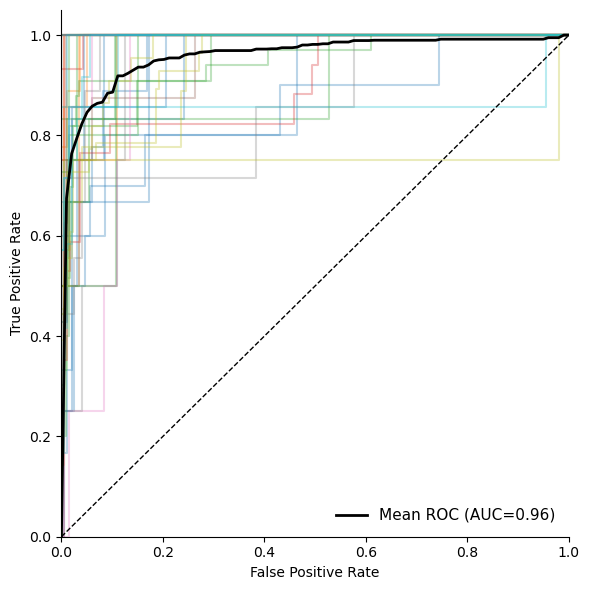

In [64]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve, auc


# Plot ROC curve for each odor separately
# Prepare common FPR grid for averaging
overall_mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

fig, ax = plt.subplots(figsize=(6, 6))
for i, _odor in enumerate(ODORS):
    if np.sum(test_labels[:, i]) == 0:
        continue
    fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
    roc_auc_i = auc(fpr, tpr)
    odor_cat = ODOR_TO_CAT[_odor]
    color = CATEGORY_COLORS[odor_cat]

    # Individual odor line (faded)
    ax.plot(fpr, tpr, color=color, alpha=0.3)
    
    # Collect for category averaging
    roc_auc_macro = auc(fpr, tpr)
    tpr_interp = np.interp(overall_mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)
    aucs.append(roc_auc_macro)

# --- Plot overall mean ROC ---
overall_mean_tpr = np.mean(tprs, axis=0)
overall_mean_tpr[-1] = 1.0
overall_mean_auc = np.mean(aucs)
ax.plot(overall_mean_fpr, overall_mean_tpr, color='black', lw=2,
              label=f"Mean ROC (AUC={overall_mean_auc:.2f})")

# ax.plot(fpr, tpr, color="C0", lw=2, label=f"AUC={roc_auc:.2f}")
ax.plot([0, 1], [0, 1], 'k--', lw=1)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(frameon=False, fontsize=11, loc="lower right")

fig = pf.plt_clean_axes(fig)
fig.tight_layout()
fig.show()

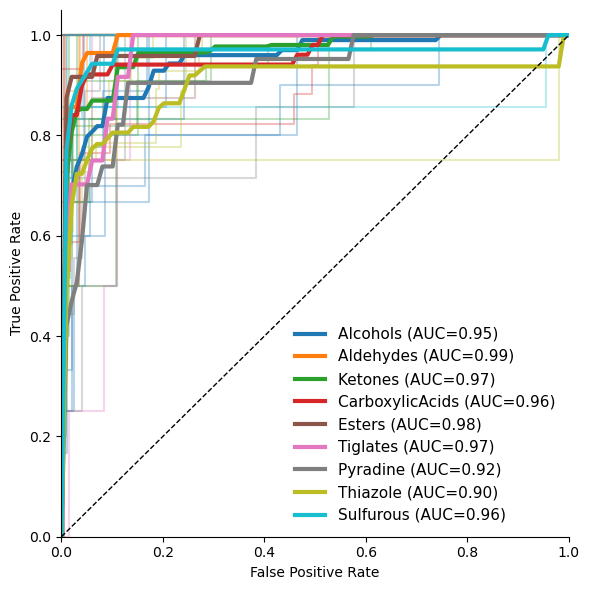

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve, auc


category_curves = {cat: [] for cat in ODOR_CATEGORIES}
fig, ax = plt.subplots(figsize=(6, 6))
for i, _odor in enumerate(ODORS):
    if np.sum(test_labels[:, i]) == 0:
        continue
    fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
    roc_auc_i = auc(fpr, tpr)
    odor_cat = ODOR_TO_CAT[_odor]
    color = CATEGORY_COLORS[odor_cat]

    # Individual odor line (faded)
    ax.plot(fpr, tpr, color=color, alpha=0.3)
    
    # Collect for category averaging
    category_curves[odor_cat].append((fpr, tpr))

# Plot category-averaged ROC for this run
for cat, curves in category_curves.items():
    if not curves:
        continue
    mean_fpr = np.linspace(0, 1, 100)
    tprs_cat = []
    for fpr, tpr in curves:
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs_cat.append(tpr_interp)
    mean_tpr_cat = np.mean(tprs_cat, axis=0)
    mean_tpr_cat[-1] = 1.0
    mean_auc_cat = auc(mean_fpr, mean_tpr_cat)
    ax.plot(mean_fpr, mean_tpr_cat, color=CATEGORY_COLORS[cat], lw=3,
             label=f"{cat} (AUC={mean_auc_cat:.2f})"
                )
    
# ax.plot(fpr, tpr, color="C0", lw=2, label=f"AUC={roc_auc:.2f}")
ax.plot([0, 1], [0, 1], 'k--', lw=1)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(frameon=False, fontsize=11, loc="lower right")

fig = pf.plt_clean_axes(fig)
fig.tight_layout()
fig.show()

### Features

#### Plot Features 

In [3]:
import os 
import sys
import pandas as pd 
import numpy as np 

import plot_functions as pf
import color_function as cf 
import voxel_functions as vf 

base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/final_model/20251118_173316_lr0.0001_bs4_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

# Load pS6-IP data 
ps6_df = pd.read_csv('../../files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
ps6_df.odor_category = ps6_df.odor_category.astype(pd.CategoricalDtype(categories=['Alcohols', 'Aldehydes', 'Ketones','CarboxylicAcids', 'Esters',
                                                                                   'Tiglates', 'Pyradine', 'Thiazole', 'Sulfurous', 'Others'], ordered=True))
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()
ps6_df = ps6_df[ps6_df.odor_category != 'Others']

ODOR_CATEGORIES = ps6_df.odor_category.sort_values().unique()
ODORS = [_odor for _cat in ODOR_CATEGORIES for _odor in ps6_df[ps6_df.odor_category == _cat].dropna().sort_values(['cid_mw', 'odor']).odor.unique()]
ODOR_TO_CAT = dict(zip(ps6_df.odor, ps6_df.odor_category))
CATEGORY_COLORS = cf.distinct_colors(ODOR_CATEGORIES, category = 'tab10')
ODOR_COLORS = {}
for _category in ODOR_CATEGORIES:     
    ODOR_COLORS.update(cf.generate_faded_shades(CATEGORY_COLORS[_category],
                                     list(ps6_df[ps6_df.odor_category == _category].sort_values(['cid_mw', 'odor']).odor.unique()), 
                                     (0.4,0.8)))
    
OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

LEARN_MODE = 'true'

voxel_names = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_voxel_names.npy"), allow_pickle=True)
all_features = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_embeddings.npy"))
all_labels = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_labels.npy"))
all_probs = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_probs.npy"))
all_importances = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_all_importances.npy"), allow_pickle=True).item()
odor_importances = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_odor_importances.npy"), allow_pickle=True).item()

from ast import literal_eval

voxels_info = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/{LEARN_MODE}_voxels_info.csv')
voxels_info['odor_response'] =  voxels_info.odor_response.apply(literal_eval)
voxels_info['pred_odor_response'] =  voxels_info.pred_odor_response.apply(literal_eval)
voxels_info['labels'] = list(all_labels)
voxels_info['probs'] = list(all_probs)


In [5]:
"""
Dimensional reduction via PCA / UMAP 
"""

import os 
import re 
from sklearn.decomposition import PCA

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(all_features)
pca_variance = pca.explained_variance_ratio_

# Build PCA dataframe
pca_df = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

pca_df['odor_response'] = voxels_info.odor_response
pca_df['pred_odor_response'] = voxels_info.pred_odor_response
pca_df['name'] = voxels_info.voxel_name
pca_df['family'] = voxels_info.family
pca_df['species'] = pca_df.name.str.isupper().astype(int)


pca_df.to_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv')
np.save(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_variance.npy', pca_variance)

import umap 
import re 

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(all_features)

# Build PCA dataframe
umap_df = pd.DataFrame(X_umap, columns=['UMAP_1', 'UMAP_2'])

# For convenience, store which ORs are activated by which odor
umap_df['odor_response'] = voxels_info.odor_response
umap_df['pred_odor_response'] = voxels_info.pred_odor_response
umap_df['name'] = voxels_info.voxel_name
umap_df['family'] = voxels_info.family
umap_df['species'] = umap_df.name.str.isupper().astype(int)
# os.mkdir('/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap')
umap_df.to_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/{LEARN_MODE}_umap_df.csv')


/home/hl307@dhe.duke.edu/anaconda3/envs/structure/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### PCA 

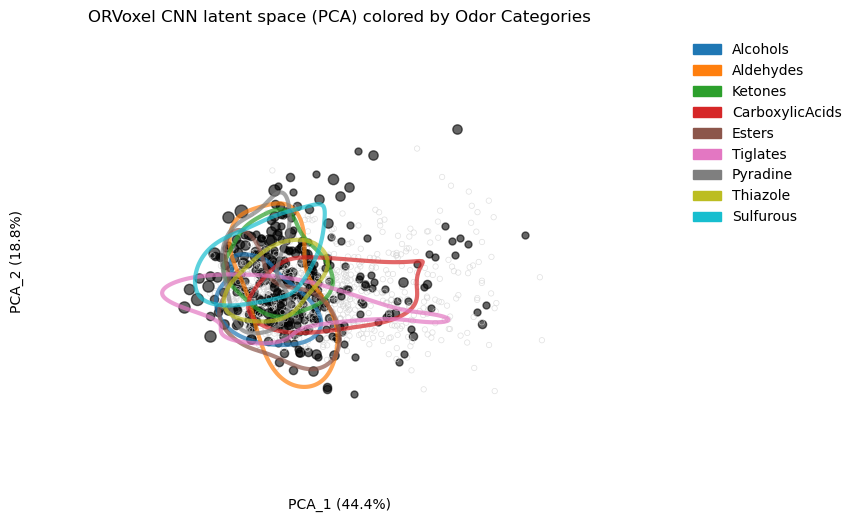

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from ast import literal_eval

pca_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv', index_col = 0)
pca_variance = np.load(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_variance.npy')
pca_df['odor_response'] = pca_df['odor_response'].apply(literal_eval)
pca_df['pred_odor_response'] = pca_df['pred_odor_response'].apply(literal_eval)


# Assign a color per odor
color_map = cf.distinct_colors(ODOR_CATEGORIES, category='tab10')

# --- Plot ---
plt.figure(figsize=(8,6))

# Scatter: individual ORs, color by first active odor (or gray if none)
for idx, row in pca_df.iterrows():
    if row['odor_response']:
        plt.scatter(row['PCA_1'], row['PCA_2'],
                    # color=color_map[row['odor_response'][0]],
                    color = 'black',
                    s=15 + (10*len(row['odor_response'])), alpha=0.6)
    else:
        plt.scatter(row['PCA_1'], row['PCA_2'],
                    edgecolor = '#D3D3D3', facecolor='none',lw=0.5,
                    s=15, alpha=0.7)

# KDE contour per odor category
legend_patches = []
for cat in ODOR_CATEGORIES:
    subset = pca_df[[cat in [ODOR_TO_CAT.get(_odor) for _odor in active] for active in pca_df['odor_response']]]
    if len(subset) < 2:
        continue  # skip odors with too few ORs
    sns.kdeplot(
        x=subset['PCA_1'], y=subset['PCA_2'],
        levels=2,
        thresh=0.5,
        color=color_map[cat],
        linewidths=3,
        alpha=0.7,
        label=cat,
        warn_singular=False
    )
    legend_patches.append(mpatches.Patch(color=color_map[cat], label=cat))

plt.legend(handles=legend_patches,
           edgecolor='None', markerscale=2,
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel(f'PCA_1 ({pca_variance[0]*100:.1f}%)')
plt.ylabel(f'PCA_2 ({pca_variance[1]*100:.1f}%)')
plt.title("ORVoxel CNN latent space (PCA) colored by Odor Categories")

# Hide spines
ax = plt.gca()  # Get current axes
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# Hide ticks (tick marks) but keep axis labels
ax.set_xticks([])
ax.set_yticks([])

# plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_{TOPK}_pca.png', dpi=300)
plt.show()

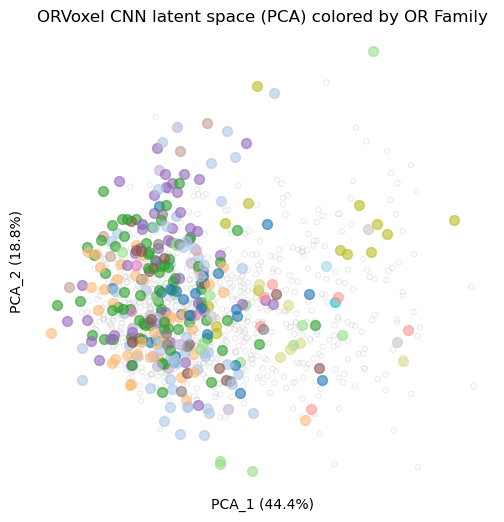

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from ast import literal_eval

pca_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv', index_col = 0)
pca_variance = np.load(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_variance.npy')
pca_df['odor_response'] = pca_df['odor_response'].apply(literal_eval)
pca_df['pred_odor_response'] = pca_df['pred_odor_response'].apply(literal_eval)


# Assign a color per family
scatter_color_by = 'family'
FAM_COLOR = cf.distinct_colors(pca_df[scatter_color_by].sort_values().unique(), category='tab20')

# --- Plot ---
plt.figure(figsize=(6,6))

# Scatter: individual ORs, color by first active odor (or gray if none)
for idx, row in pca_df.sort_values('odor_response').iterrows():
    if row['odor_response']:
        plt.scatter(row['PCA_1'], row['PCA_2'],
                    # color=color_map[row['odor_response'][0]],
                    color = FAM_COLOR.get(row['family']),
                    s=50, alpha=0.6)
    else:
        plt.scatter(row['PCA_1'], row['PCA_2'],
                    edgecolor = '#D3D3D3', facecolor='none',lw=0.5,
                    s=15, alpha=0.7)

# legend_patches=[]
# for _fam in FAM_COLOR: 
#     legend_patches.append(mpatches.Patch(color=FAM_COLOR[_fam], label=_fam))

# plt.legend(handles=legend_patches,
#            edgecolor='None', markerscale=2,
#            bbox_to_anchor=(0.9, 1), loc='upper left')

plt.title("ORVoxel CNN latent space (PCA) colored by OR Family")
plt.xlabel(f'PCA_1 ({pca_variance[0]*100:.1f}%)')
plt.ylabel(f'PCA_2 ({pca_variance[1]*100:.1f}%)')

# Hide spines
ax = plt.gca()  # Get current axes
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# Hide ticks (tick marks) but keep axis labels
ax.set_xticks([])
ax.set_yticks([])
    
plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_family_pca.png', dpi=500)
plt.show()

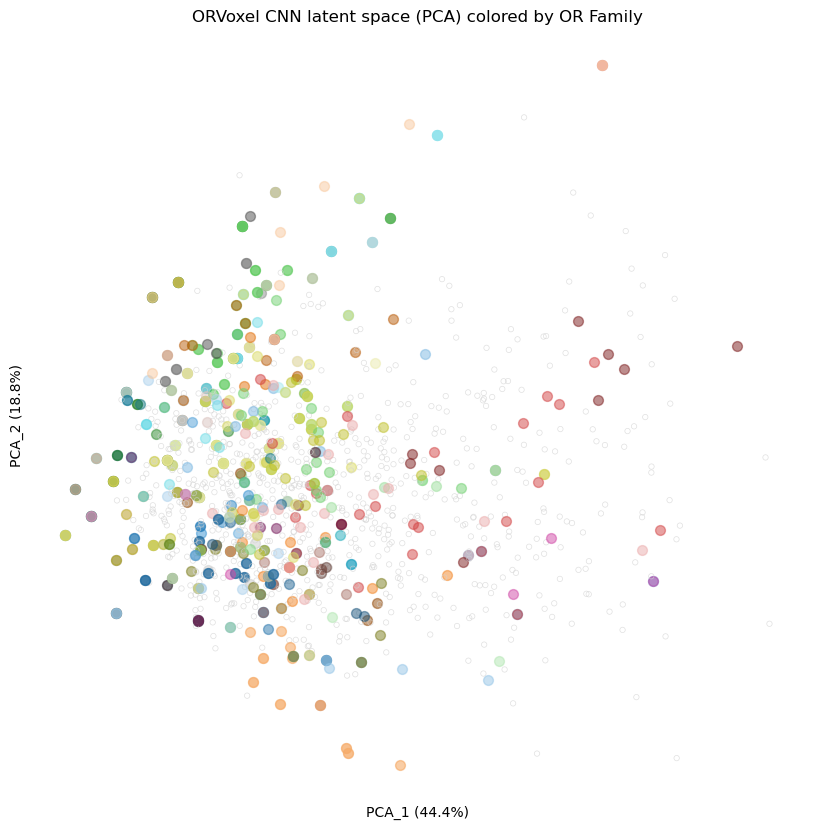

In [9]:
"""
Single OVERALL UMAP 
colored by odor response

"""
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

pca_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv', index_col = 0)
pca_variance = np.load(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_variance.npy')
pca_df['odor_response'] = pca_df['odor_response'].apply(literal_eval)
pca_df['pred_odor_response'] = pca_df['pred_odor_response'].apply(literal_eval)

plot_by = 'odor_response'
# Assign a color per odor
color_map = cf.distinct_colors(ODOR_CATEGORIES, category='tab10')

CATEGORY_COLORS = cf.distinct_colors(ODOR_CATEGORIES, category = 'tab10')
ODOR_COLOR = {}
for _category in ps6_df.odor_category.unique():     
    ODOR_COLOR.update(cf.generate_faded_shades(CATEGORY_COLORS[_category],
                                     list(ps6_df[ps6_df.odor_category == _category].odor.sort_values().unique()), 
                                     (0.3,0.8)))
    

plot_df = pca_df.copy()


# --- Plot ---
plt.figure(figsize=(10,10))
# for _odor in ODORS:
    # _c?ategory = ODOR_TO_CAT.get(_odor)

    
for i, row in plot_df.iterrows(): 
    if row[plot_by]:
        for _odor in row['odor_response']:
            plt.scatter(row['PCA_1'], row['PCA_2'],
                        color= ODOR_COLOR[_odor] if _odor in row['odor_response'] else 'grey',
                        marker= 'o' if row['species'] == 0 else 'v',
                        alpha= 0.5,
                        s=50)
    else:
        plt.scatter(row['PCA_1'], row['PCA_2'],
                    edgecolor='#d3d3d3', facecolor='none', lw=0.5,
                    marker= 'o' if row['species'] == 0 else 'v',
                    s=15, alpha=0.7)
    
# legend_patches = [] 
# for _odor in ODOR_TO_CAT.keys():
#     legend_patches.append(mpatches.Patch(color=ODOR_COLOR[_odor], label=_odor))
# plt.legend(
#     # title=_category,
#             handles=legend_patches,
#             edgecolor='None', markerscale=2,
#             bbox_to_anchor=(0.9, 1), loc='upper left')
plt.title("ORVoxel CNN latent space (PCA) colored by OR Family")
plt.xlabel(f'PCA_1 ({pca_variance[0]*100:.1f}%)')
plt.ylabel(f'PCA_2 ({pca_variance[1]*100:.1f}%)')

# Hide spines
ax = plt.gca()  # Get current axes
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
# Hide ticks (tick marks) but keep axis labels
ax.set_xticks([])
ax.set_yticks([])

# plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/Odor_pca.png', dpi=500)
plt.show()
    # break

In [ ]:
"""
Export individual odor plots 
"""
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from tqdm import tqdm 

pca_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv', index_col = 0)
pca_df['odor_response'] = pca_df['odor_response'].apply(literal_eval)
pca_df['pred_odor_response'] = pca_df['pred_odor_response'].apply(literal_eval)

plot_by = 'odor_response'

    
# ---- Determine subplot layout ----
num_odors = len(ODORS)
cols = 4
rows = int(np.ceil(num_odors / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = axes.flatten()

# ---- Compute global axis limits so all subplots share same zoom ----
x_min, x_max = pca_df['PCA_1'].min(), pca_df['PCA_1'].max()
y_min, y_max = pca_df['PCA_2'].min(), pca_df['PCA_2'].max()
pad_x = 0.25 * (x_max - x_min)
pad_y = 0.25 * (y_max - y_min)
x_min, x_max = x_min - pad_x, x_max + pad_x
y_min, y_max = y_min - pad_y, y_max + pad_y


# ---- Create each subplot ----
for ax, _odor in tqdm(zip(axes, ODORS)):
    # if _odor != 'TBM': 
    #     continue
    _category = ODOR_TO_CAT.get(_odor)

    # Scatter: individual ORs, color by first active odor (or gray if none)
    plot_df = pca_df.copy()
    # Add z-order column
    plot_df['_zorder'] = np.where(
        ~pca_df[plot_by].astype(bool), 0,  # grey
        np.where(plot_df['odor_response'].apply(lambda x: _odor in x), 2, 1)  # red or blue
    )
    
    # Scatter
    for idx, row in plot_df.sort_values('_zorder').iterrows():
        if row[plot_by]:
            ax.scatter(
                row['PCA_1'], row['PCA_2'],
                color=ODOR_COLOR.get(_odor) if _odor in row['odor_response'] else '#D3D3D3',
                marker='o' if row['species'] == 0 else 'v',
                alpha=0.7 if _odor in row['odor_response'] else 0.1,
                s=50
            )
        else:
            ax.scatter(
                row['PCA_1'], row['PCA_2'],
                edgecolor='#d3d3d3', facecolor='none', lw=0.5,
                marker='o' if row['species'] == 0 else 'v',
                s=15, alpha=0.3
            )
    
    # legend_patches = []
    # legend_patches.append(mpatches.Patch(color=ODOR_COLOR[_odor], label=_odor))
        
    # plt.legend(
    #     # title=_category,
    #            handles=legend_patches,
    #            edgecolor='None', markerscale=2,
    #            bbox_to_anchor=(0.7, 1), loc='upper left')
    # Formatting
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(_odor, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

# Remove any unused empty subplots
for empty_ax in axes[num_odors:]:
    empty_ax.axis('off')

plt.tight_layout()

plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/Odor_pca_subplot.png', dpi=300)
plt.show()


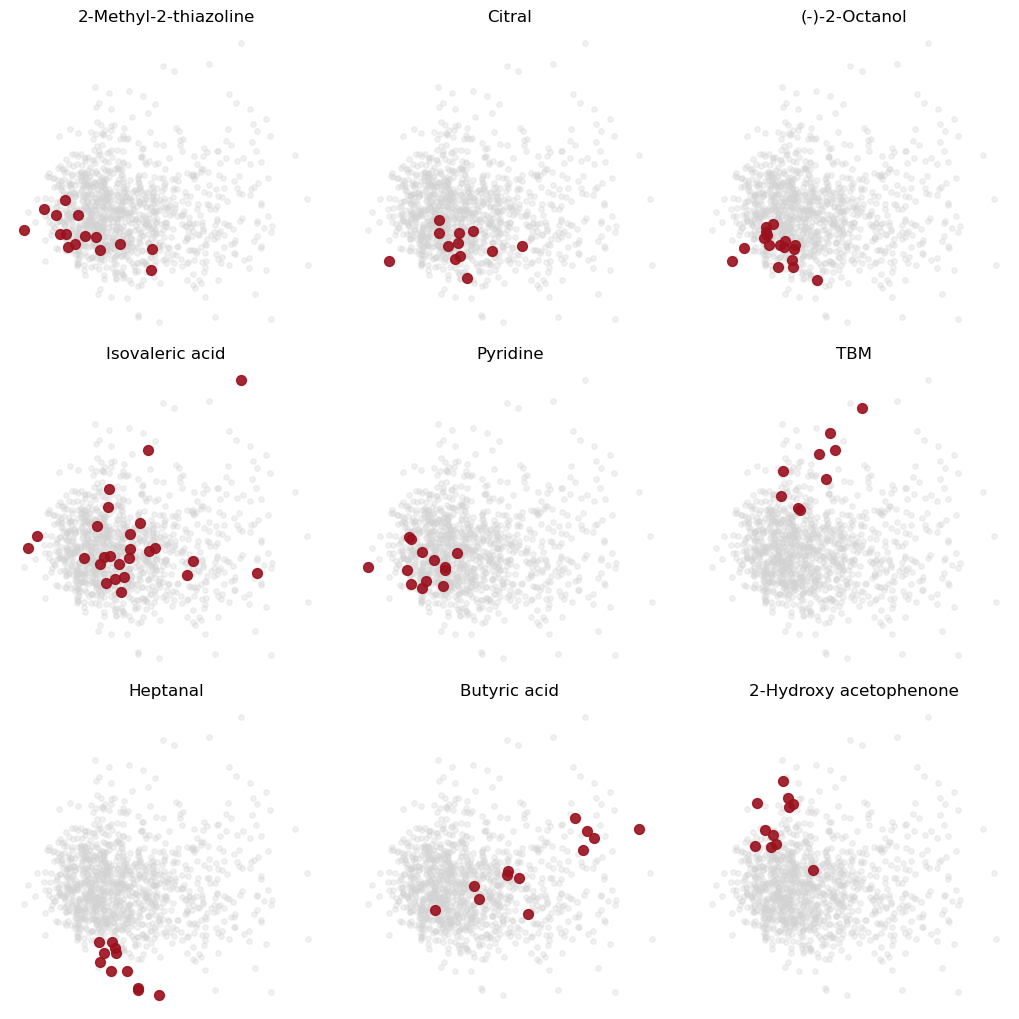

In [38]:
"""
Plot selected odors as facet. 
"""
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from plotly.subplots import make_subplots

pca_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv', index_col = 0)
pca_df['odor_response'] = pca_df['odor_response'].apply(literal_eval)
pca_df['pred_odor_response'] = pca_df['pred_odor_response'].apply(literal_eval)

plot_by = 'odor_response'
# Assign a color per odor

plot_odors = ['2-Methyl-2-thiazoline',
              'Citral',
              '(-)-2-Octanol',
              'Isovaleric acid',
              'Pyridine',
              'TBM',
              'Heptanal', 
              'Butyric acid', 
              '2-Hydroxy acetophenone', 
              ]

n_odors = len(plot_odors)
ncols = 3
nrows = (n_odors + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10,10), squeeze=True)

for idx, _odor in enumerate(plot_odors):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row][col]

    # Plot all ORs in gray
    ax.scatter(pca_df['PCA_1'], pca_df['PCA_2'], color='#D3D3D3', s=15, alpha=0.3, label='All ORs')

    # Highlight ORs responsive to this odor
    mask = pca_df['odor_response'].apply(lambda x: _odor in x)
    subset = pca_df[mask]
    ax.scatter(subset['PCA_1'], subset['PCA_2'], color='#9B111E', s=50, alpha=0.9, label=_odor)

    ax.set_title(_odor)
    ax.axis('off')

# Remove empty subplots if n_odors is not a multiple of ncols
for idx in range(n_odors, nrows * ncols):
    fig.delaxes(axes[idx // ncols][idx % ncols])
    
plt.tight_layout(pad=0)
plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/selected_subplots_feature_pca.png', dpi=300)

plt.show()


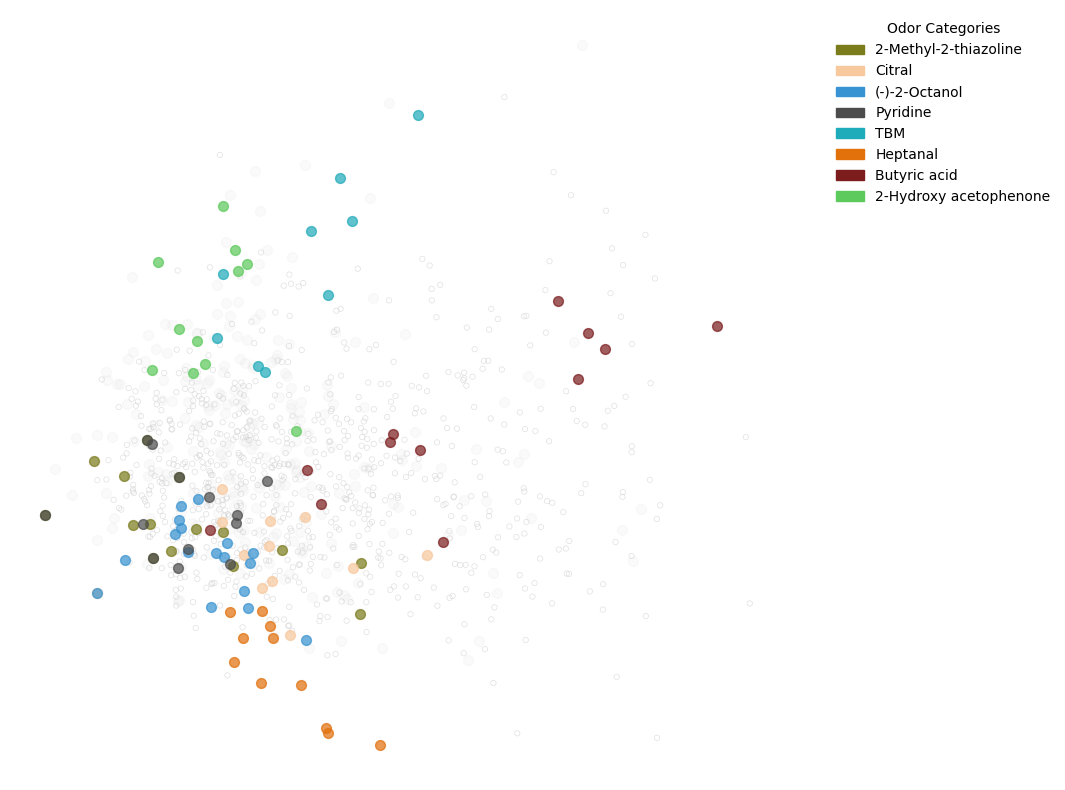

In [22]:
"""
Representative figure plot
"""

import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

pca_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv', index_col = 0)
pca_df['odor_response'] = pca_df['odor_response'].apply(literal_eval)
pca_df['pred_odor_response'] = pca_df['pred_odor_response'].apply(literal_eval)

plot_odors = ['2-Methyl-2-thiazoline',
              'Citral',
              '(-)-2-Octanol',
              # 'Isovaleric acid',
              'Pyridine',
            #   '2-Butene-1-thiol',
              # 'Cyclopentanethiol',
              'TBM',
              'Heptanal', 
              'Butyric acid', 
              '2-Hydroxy acetophenone', 
            #   '(+)-Carvone'
            #   'Ethyl butyrate'
              ]
# --- Plot ---
plt.figure(figsize=(10,10))

# Scatter: individual ORs, color by first active odor (or gray if none)
for idx, row in pca_df.iterrows():
    if row['odor_response']:
        plt.scatter(row['PCA_1'], row['PCA_2'],
                    # color = FAM_COLOR.get(row['family']),
                    # color = 'black', 
                    color = '#D3D3D3',
                    s=50, alpha=0.1)
    else:
        # plt.scatter(row['PCA_1'], row['PCA_2'], color='lightgray', s=15, alpha=0.4)
        plt.scatter(row['PCA_1'], row['PCA_2'],
                    edgecolor = '#d3d3d3', facecolor='none',lw=0.5,
                    s=15, alpha=0.7)
        
legend_patches = []    
for _odor in plot_odors:     
    _category = ODOR_TO_CAT.get(_odor)
    subset = pca_df[[_odor in active for active in pca_df['odor_response']]]
        
    plt.scatter(subset['PCA_1'], subset['PCA_2'],
            # color=CATEGORY_COLORS[_category],
            color=ODOR_COLOR.get(_odor),
            s=50, alpha=0.7)
    
    # legend_patches.append(mpatches.Patch(color=CATEGORY_COLORS[_category], label=_odor))
    legend_patches.append(mpatches.Patch(color=ODOR_COLOR[_odor], label=_odor))


# plt.title("ORVoxel CNN latent space (UMAP) colored by Odor Categories")
plt.legend(title='Odor Categories',
            handles=legend_patches,
            edgecolor='None', markerscale=2,
            bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('off')


# plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/pca_subcategory2.png', dpi=300)
plt.show()


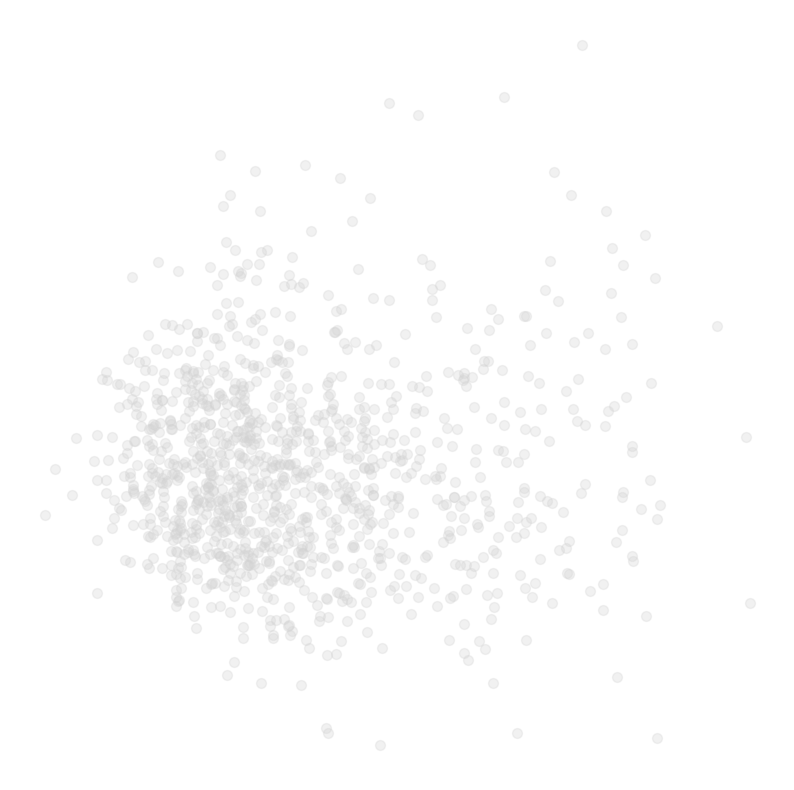

In [31]:
"""
background pca plot 
"""

import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

pca_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv', index_col = 0)
pca_df['odor_response'] = pca_df['odor_response'].apply(literal_eval)
pca_df['pred_odor_response'] = pca_df['pred_odor_response'].apply(literal_eval)

# --- Plot ---
plt.figure(figsize=(10,10))

# Scatter: individual ORs, color by first active odor (or gray if none)
plt.scatter(pca_df['PCA_1'], pca_df['PCA_2'],
            # color = FAM_COLOR.get(row['family']),
            # color = 'black', 
            color = '#D3D3D3', 
            s=50, alpha=0.3)

plt.axis('off')


# plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/pca_subcategory2.png', dpi=300)
plt.show()


In [ ]:
"""
Plot for response broadness. How many category is a OR responding to 
"""

pca_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv', index_col = 0)
pca_df['odor_response'] = pca_df['odor_response'].apply(literal_eval)
pca_df['pred_odor_response'] = pca_df['pred_odor_response'].apply(literal_eval)

plot_by = 'odor_response'
# Assign a color per odor
color_map = cf.distinct_colors(ODOR_CATEGORIES, category='tab10')
    
plot_df = pca_df.copy()
plot_df['num_response'] = plot_df.odor_response.apply(lambda x : len(x))
plot_df['num_category_response'] = plot_df.odor_response.apply(lambda x : len(np.unique([ODOR_TO_CAT.get(_x) for _x in x])))


for _plot_by in ['num_response', 'num_category_response']: 
    
    plt.figure(figsize=(10,10))  
    
    # Assign color
    plot_df['color'] = cf.get_continuous_colors(plot_df[_plot_by], colormap='viridis')

    for i, row in plot_df.sort_values(_plot_by).iterrows(): 
        if row[plot_by]:
            plt.scatter(row['PCA_1'], row['PCA_2'],
                        color= row.color,
                        marker= 'o' if row['species'] == 0 else 'v',
                        alpha= 1,
                        s=50)
        else:
            plt.scatter(row['PCA_1'], row['PCA_2'],
                        edgecolor='#d3d3d3', facecolor='none', lw=0.5,
                        marker= 'o' if row['species'] == 0 else 'v',
                        s=15, alpha=0.7)    

    # plt.title(f"ORVoxel CNN latent space (PCA) colored by {_plot_by}")
    # plt.xlabel(f'PCA_1 ({pca_variance[0]*100:.1f}%)')
    # plt.ylabel(f'PCA_2 ({pca_variance[1]*100:.1f}%)')

    # Hide spines
    ax = plt.gca()  # Get current axes
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)
    # Hide ticks (tick marks) but keep axis labels
    ax.set_xticks([])
    ax.set_yticks([])

    plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{_plot_by}_pca.png', dpi=300)
    plt.show()
        # break


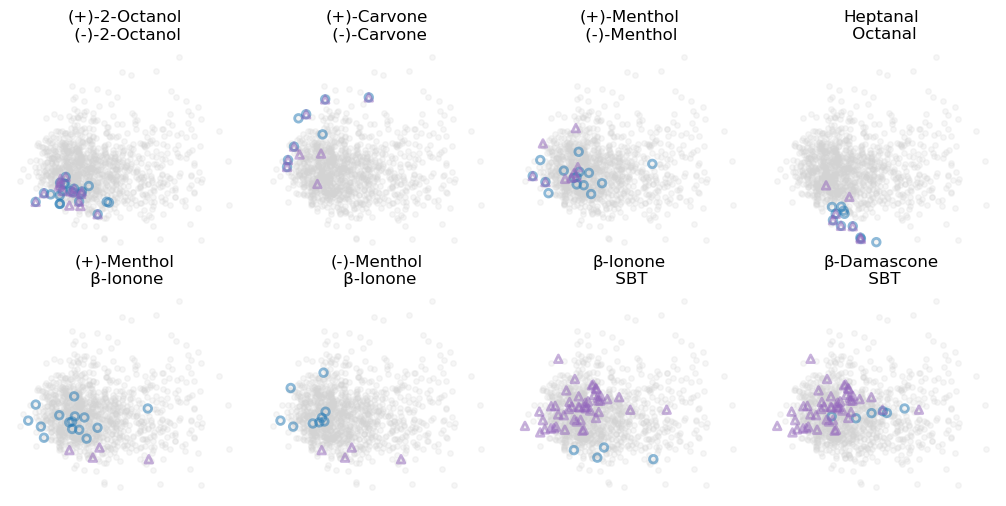

In [87]:
"""
Similar cid plot. To visualize the similarity in ORs across ligand
"""
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from plotly.subplots import make_subplots

pca_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv', index_col = 0)
pca_variance = np.load(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_variance.npy')
pca_df['odor_response'] = pca_df['odor_response'].apply(literal_eval)
pca_df['pred_odor_response'] = pca_df['pred_odor_response'].apply(literal_eval)

plot_by = 'odor_response'

# most similar cid pairs via morgan_fp 
cid_euclid_distance = pd.read_csv('/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/pairwise/odorOR_cid_distance.csv', index_col = 0 )
cid_to_odor = {ps6_df[ps6_df.odor == _odor].cid.unique()[0]: _odor for _odor in ODORS}

cid_euclid_distance['odor_1'] = [cid_to_odor.get(_cid) for _cid in cid_euclid_distance['cid_1']]
cid_euclid_distance['odor_2'] = [cid_to_odor.get(_cid) for _cid in cid_euclid_distance['cid_2']]

# Assign a color per odor
plot_odors = list(cid_euclid_distance.sort_values('cid_Distance')[['odor_1', 'odor_2']].head(4).values)
plot_odors.extend(cid_euclid_distance.sort_values('cid_Distance')[['odor_1', 'odor_2']].tail(4).values)

markers = ['o', '^', '*']
palette = [sns.color_palette('tab10')[i] for i in [0, 4]]


n_odors = len(plot_odors)
ncols = 4
nrows = (n_odors + ncols - 1) // ncols

panel_size = (2.5, 2.5)  # inches per subplot
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols * panel_size[0], nrows * panel_size[1]),
    squeeze=True
)
for idx, odor_group in enumerate(plot_odors):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row][col]

    # Background: all ORs
    ax.scatter(
        pca_df['PCA_1'],
        pca_df['PCA_2'],
        color='#D3D3D3',
        s=15,
        alpha=0.2
    )

    # # Plot each odor in the group
    for j, odor in enumerate(odor_group):
        mask = pca_df[plot_by].apply(lambda x: odor in x)
        subset = pca_df[mask]

        ax.scatter(
            subset['PCA_1'],
            subset['PCA_2'],
            s=30,
            alpha=0.5,
            marker=markers[j % len(markers)],
            # color=palette[j % len(palette)],
            facecolor='none',
            edgecolor=palette[j % len(palette)],
            linewidth=2,
            label=odor
        )
    # odor_A, odor_B = odor_group   # assumes exactly 2 odors per subplot

    # mask_A = pca_df[plot_by].apply(lambda x: odor_A in x)
    # mask_B = pca_df[plot_by].apply(lambda x: odor_B in x)

    # # Exclusive sets
    # only_A = pca_df[mask_A & ~mask_B]
    # only_B = pca_df[mask_B & ~mask_A]

    # # Overlap
    # both = pca_df[mask_A & mask_B]

    # # --- Plot odor A only ---
    # ax.scatter(
    #     only_A['PCA_1'],
    #     only_A['PCA_2'],
    #     s=30,
    #     alpha=0.5,
    #     color=palette[0],
    #     marker='^'
    # )

    # # --- Plot odor B only ---
    # ax.scatter(
    #     only_B['PCA_1'],
    #     only_B['PCA_2'],
    #     s=30,
    #     alpha=0.5,
    #     color=palette[1],
    #     marker='x'
    # )

    # # --- Plot overlap (outlined) ---
    # ax.scatter(
    #     both['PCA_1'],
    #     both['PCA_2'],
    #     s=30,
    #     facecolor='none',     # hollow
    #     edgecolor='k',        # outline
    #     linewidth=1.2,
    # )
    
    ax.set_title('\n '.join(odor_group))
    ax.axis('off')
    

    # if len(odor_group) > 1:
    #     ax.legend(frameon=False, fontsize=7)

# Remove empty subplots
for idx in range(n_odors, nrows * ncols):
    fig.delaxes(axes[idx // ncols][idx % ncols])

plt.tight_layout(pad=0.5)
plt.subplots_adjust(wspace=0.1, hspace=0.2)


plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/odorOR_comparison_pca.png', dpi=300, transparent=True)

plt.show()


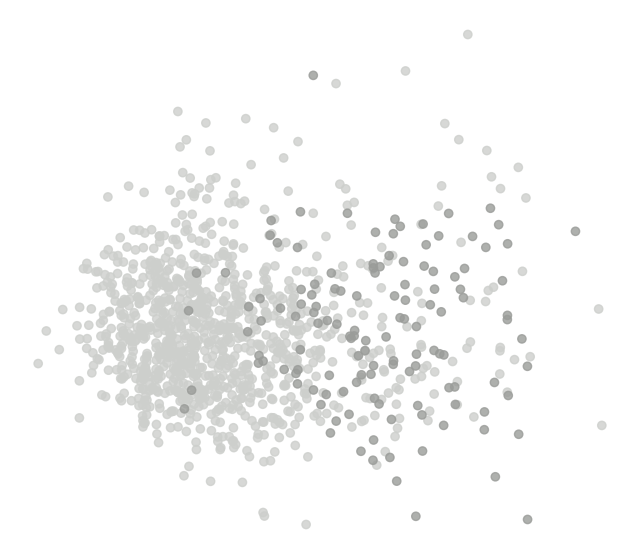

In [25]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

"""
Quickly Visualize family distribution on the overall map 
"""
pca_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv', index_col = 0)
pca_df['odor_response'] = pca_df['odor_response'].apply(literal_eval)
pca_df['pred_odor_response'] = pca_df['pred_odor_response'].apply(literal_eval)


pca_df['class'] = [1 if int(_fam) >= 50 else 2 for _fam in pca_df.family]

scatter_color_by = 'class'
CLASS_COLOR = cf.distinct_colors(np.sort(pca_df[scatter_color_by].unique()), custom_color=['#9A9C99', '#CDCFCC'])


plt.figure(figsize=(8,7))

plot_df = pca_df.sort_values('class', ascending=False)
plt.scatter(plot_df[plot_df.species == 0].PCA_1, plot_df[plot_df.species == 0].PCA_2,
            # c = '#D3D3D3', 
            c = [CLASS_COLOR.get(_fam) for _fam in plot_df[plot_df.species == 0][scatter_color_by]],
            alpha=0.8, 
            marker = 'o')
plt.axis('off')

plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/class_pca.png', dpi=300)
plt.show()

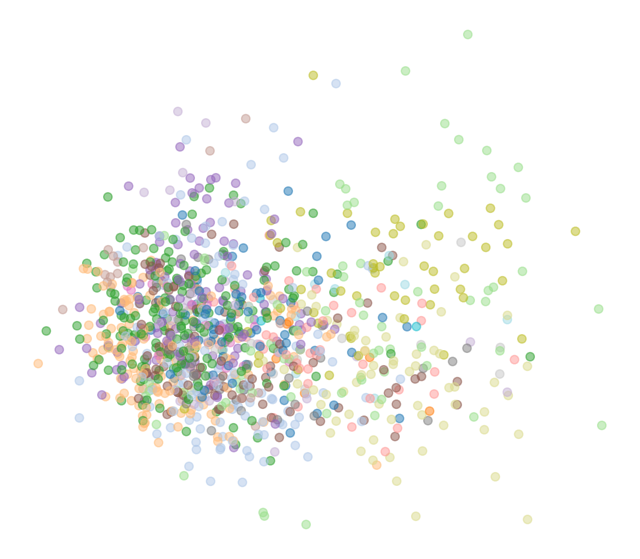

In [32]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

"""
Quickly Visualize family distribution on the overall map 
"""
pca_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv', index_col = 0)
pca_df['odor_response'] = pca_df['odor_response'].apply(literal_eval)
pca_df['pred_odor_response'] = pca_df['pred_odor_response'].apply(literal_eval)


pca_df['class'] = [1 if int(_fam) >= 50 else 2 for _fam in pca_df.family]

scatter_color_by = 'family'
FAM_COLOR = cf.distinct_colors(pca_df[scatter_color_by].sort_values().unique(), category='tab20')


plt.figure(figsize=(8,7))

plot_df = pca_df
plt.scatter(plot_df[plot_df.species == 0].PCA_1, plot_df[plot_df.species == 0].PCA_2,
            # c = '#D3D3D3', 
            c = [FAM_COLOR.get(_fam) for _fam in plot_df[plot_df.species == 0][scatter_color_by]],
            alpha=0.5, 
            marker = 'o')
plt.axis('off')

# plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/family_pca.png', dpi=300)
plt.show()

In [46]:
(pca_df[pca_df.name.str.contains('Or1e1c')].odor_response.values[0])

['2,5-Dimethylpyrazine',
 '2-Methyl-2-thiazoline',
 'Acetophenone',
 'Pyridine',
 'SBT',
 'TMT',
 'nTMT']

In [62]:
list(activated_or['n']).count(7)

2

<Axes: >

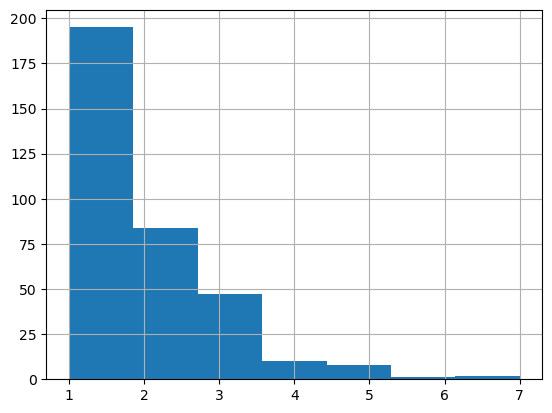

In [64]:
activated_or['n'].hist(bins=7)

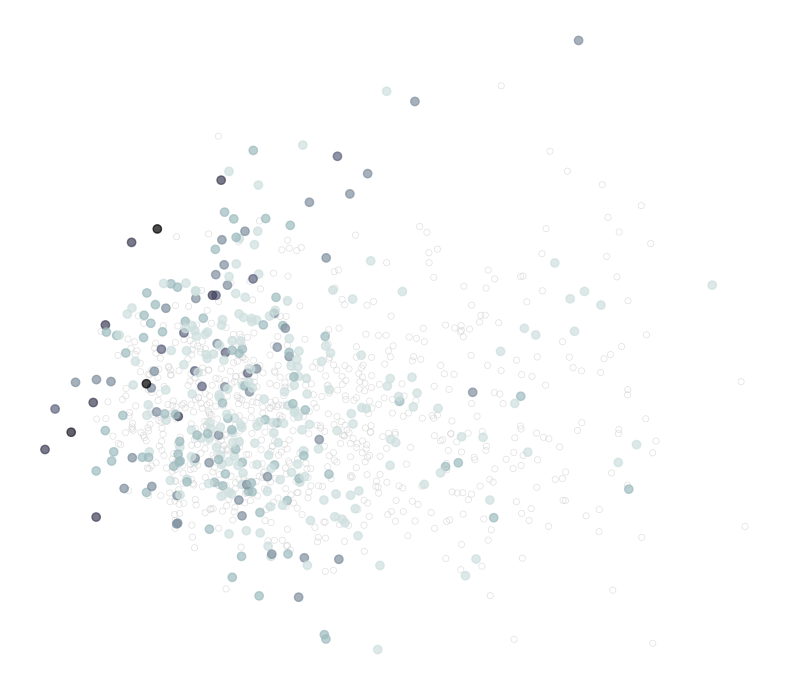

/tmp/ipykernel_3141012/3509192890.py:49: UserWarning:

Adding colorbar to a different Figure <Figure size 800x700 with 1 Axes> than <Figure size 100x400 with 1 Axes> which fig.colorbar is called on.



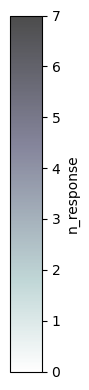

In [86]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

"""
Quickly Visualize family distribution on the overall map 
"""

pca_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv', index_col = 0)
pca_df['odor_response'] = pca_df['odor_response'].apply(literal_eval)
pca_df['pred_odor_response'] = pca_df['pred_odor_response'].apply(literal_eval)

pca_df['n_response'] = pca_df.odor_response.apply(lambda x: len(x) if len(x) > 0 else np.nan)

scatter_color_by = 'n_response'

# Main scatter plot without colorbar
fig, ax = plt.subplots(figsize=(8,7))

plot_df = pca_df[pca_df.species == 0]

# Separate data: non-zero/non-nan vs zero/nan
mask_valid = ~plot_df['n_response'].isna() & (plot_df['n_response'] != 0)
mask_invalid = plot_df['n_response'].isna() | (plot_df['n_response'] == 0)

# Plot invalid data (0/NaN) in grey
ax.scatter(plot_df[mask_invalid].PCA_1, plot_df[mask_invalid].PCA_2,
          edgecolor = '#d3d3d3', facecolor='none',lw=0.5,
                    s=20, alpha=0.7)


# Plot valid data with colorscale
scat = ax.scatter(plot_df[mask_valid].PCA_1, plot_df[mask_valid].PCA_2,
            cmap='bone_r',
            # vmax=10, 
            vmin=0,
            c = plot_df[mask_valid]['n_response'],
            alpha=0.7, 
            marker = 'o')


ax.axis('off')
plt.tight_layout()
plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/n_activation_pca.png', dpi=300, transparent=True)
plt.show()

# Separate colorbar plot
fig_cbar, ax_cbar = plt.subplots(figsize=(1, 4))
cbar = plt.colorbar(scat, cax=ax_cbar)
cbar.set_label(scatter_color_by)
plt.tight_layout()
plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/n_activation_colorbar.png', dpi=300, bbox_inches='tight')
# plt.show()

#### UMAP 

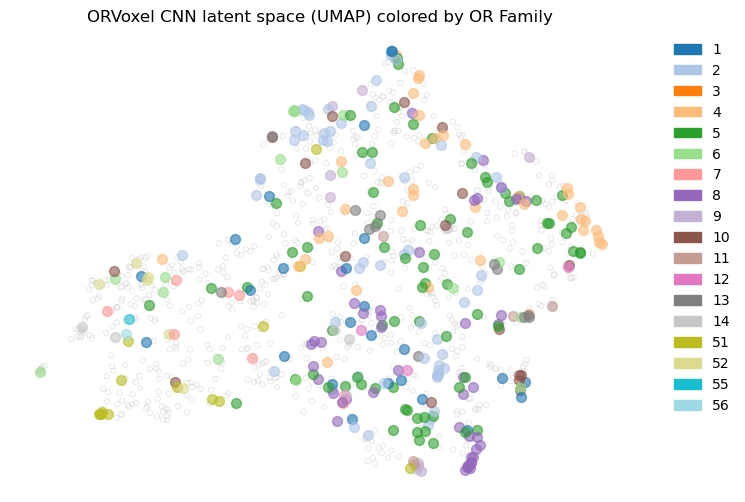

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from ast import literal_eval

umap_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/{LEARN_MODE}_umap_df.csv', index_col = 0)
umap_df['odor_response'] = umap_df['odor_response'].apply(literal_eval)
umap_df['pred_odor_response'] = umap_df['pred_odor_response'].apply(literal_eval)
    
scatter_color_by = 'family'
FAM_COLOR = cf.distinct_colors(umap_df[scatter_color_by].sort_values().unique(), category='tab20')

# --- Plot ---
plt.figure(figsize=(8,6))

# Scatter: individual ORs, color by first active odor (or gray if none)
for idx, row in umap_df.sort_values('odor_response').iterrows():
    if row['odor_response']:
        plt.scatter(row['UMAP_1'], row['UMAP_2'],
                    # color=color_map[row['odor_response'][0]],
                    color = FAM_COLOR.get(row['family']),
                    s=50, alpha=0.6)
    else:
        plt.scatter(row['UMAP_1'], row['UMAP_2'],
                    edgecolor = '#D3D3D3', facecolor='none',lw=0.5,
                    s=15, alpha=0.7)

# legend_patches=[]
# for _fam in FAM_COLOR: 
#     legend_patches.append(mpatches.Patch(color=FAM_COLOR[_fam], label=_fam))

# plt.legend(handles=legend_patches,
#            edgecolor='None', markerscale=2,
#            bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("ORVoxel CNN latent space (UMAP) colored by OR Family")
# plt.xlabel(f'UMAP_1')
# plt.ylabel(f'UMAP_2')

# Hide spines
ax = plt.gca()  # Get current axes
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# Hide ticks (tick marks) but keep axis labels
ax.set_xticks([])
ax.set_yticks([])

    
plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/{LEARN_MODE}_family_umap.png', dpi=300)
# plt.show()

In [ ]:
"""
Export individual odor plots with contour 
"""
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

umap_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/{LEARN_MODE}_umap_df.csv', index_col = 0)
umap_df['odor_response'] = umap_df['odor_response'].apply(literal_eval)
umap_df['pred_odor_response'] = umap_df['pred_odor_response'].apply(literal_eval)


plot_by = 'odor_response'


# ---- Determine subplot layout ----
num_odors = len(ODORS)
cols = 4
rows = int(np.ceil(num_odors / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = axes.flatten()

# ---- Compute global axis limits so all subplots share same zoom ----
x_min, x_max = umap_df['UMAP_1'].min(), umap_df['UMAP_1'].max()
y_min, y_max = umap_df['UMAP_2'].min(), umap_df['UMAP_2'].max()
pad_x = 0.25 * (x_max - x_min)
pad_y = 0.25 * (y_max - y_min)
x_min, x_max = x_min - pad_x, x_max + pad_x
y_min, y_max = y_min - pad_y, y_max + pad_y


# ---- Create each subplot ----
for ax, _odor in zip(axes, ODORS):

    # Scatter: individual ORs, color by first active odor (or gray if none)
    plot_df = umap_df.copy()
    # Add z-order column
    plot_df['_zorder'] = np.where(
        ~umap_df[plot_by].astype(bool), 0,  # grey
        np.where(plot_df['odor_response'].apply(lambda x: _odor in x), 2, 1)  # red or blue
    )
    for idx, row in plot_df.sort_values('_zorder').iterrows():
        if row[plot_by]:
            ax.scatter(row['UMAP_1'], row['UMAP_2'],
                        color= ODOR_COLORS.get(_odor) if _odor in row['odor_response'] else '#D3D3D3',
                        marker= 'o' if row['species'] == 0 else 'v',
                        alpha= 0.7 if _odor in row['odor_response'] else 0.3,
                        s=50 )
        else:
            ax.scatter(row['UMAP_1'], row['UMAP_2'],
                        edgecolor='#d3d3d3', facecolor='none', lw=0.5,
                        marker= 'o' if row['species'] == 0 else 'v',
                        s=20, alpha=0.3)

    
    # Formatting
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(_odor, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    

# Remove any unused empty subplots
for empty_ax in axes[num_odors:]:
    empty_ax.axis('off')

plt.tight_layout()

plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/Odor_umap_subplot.png', dpi=300)
plt.show()

In [ ]:
# """
# Export individual odor plots with contour 
# """
# import seaborn as sns 
# import matplotlib.pyplot as plt 
# import matplotlib.patches as mpatches

# umap_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/{LEARN_MODE}_{TOPK}_umap_df.csv', index_col = 0)
# umap_df['odor_response'] = umap_df['odor_response'].apply(literal_eval)
# umap_df['pred_odor_response'] = umap_df['pred_odor_response'].apply(literal_eval)


# plot_by = 'odor_response'
# # Assign a color per odor
# color_map = cf.distinct_colors(ODOR_CATEGORIES, category='tab10')

# CATEGORY_COLORS = cf.distinct_colors(ODOR_CATEGORIES, category = 'tab10')
# ODOR_COLOR = {}
# for _category in ps6_df.odor_category.unique():     
#     ODOR_COLOR.update(cf.generate_faded_shades(CATEGORY_COLORS[_category],
#                                      list(ps6_df[ps6_df.odor_category == _category].odor.sort_values().unique()), 
#                                      (0.3,0.8)))
    
# scatter_color_by = 'family'
# FAM_COLOR = cf.distinct_colors(umap_df[scatter_color_by].sort_values().unique(), category='tab20')



# # KDE contour per odor category
# for _odor in ODORS:
#     _category = ODOR_TO_CAT.get(_odor)

#     # --- Plot ---
#     plt.figure(figsize=(8,7))

#     # Scatter: individual ORs, color by first active odor (or gray if none)
#     plot_df = umap_df.copy()
#     # Add z-order column
#     plot_df['_zorder'] = np.where(
#         ~umap_df[plot_by].astype(bool), 0,  # grey
#         np.where(plot_df['odor_response'].apply(lambda x: _odor in x), 2, 1)  # red or blue
#     )
#     for idx, row in plot_df.sort_values('_zorder').iterrows():
#         if row[plot_by]:
#             plt.scatter(row['UMAP_1'], row['UMAP_2'],
#                         # color= ODOR_COLOR.get(_odor) if _odor in row['odor_response'] else '#D3D3D3',
#                         color = FAM_COLOR.get(row['family']) if _odor in row['odor_response'] else '#D3D3D3',
#                         marker= 'o' if row['species'] == 0 else 'v',
#                         alpha= 0.7 if _odor in row['odor_response'] else 0.1,
#                         s=50 )
#         else:
#             plt.scatter(row['UMAP_1'], row['UMAP_2'],
#                         edgecolor='#d3d3d3', facecolor='none', lw=0.5,
#                         marker= 'o' if row['species'] == 0 else 'v',
#                         s=20, alpha=0.3)
    
#     legend_patches = []
#     # subset = umap_df[[_odor in active for active in umap_df[plot_by]]]
#     # if len(subset) < 2:
#     #     continue  # skip odors with too few ORs
#     # sns.kdeplot(
#     #     x=subset['UMAP_1'], y=subset['UMAP_2'],
#     #     levels=2,
#     #     thresh=0.5,
#     #     color=ODOR_COLOR[_odor],
#     #     # color = '#D3D3D3',
#     #     linewidths=3,
#     #     alpha=0.8,
#     #     label=_odor,
#     #     warn_singular=False, 
#     #     legend=True, 
#     #     zorder=0
#     # )
#     legend_patches.append(mpatches.Patch(color=ODOR_COLOR[_odor], label=_odor))
        
#     # subset = umap_df[[_category in [ODOR_TO_CAT.get(_odor) for _odor in active] for active in umap_df[plot_by]]]
#     # sns.kdeplot(
#     #     x=subset['UMAP_1'], y=subset['UMAP_2'],
#     #     levels=2,
#     #     thresh=0.2,
#     #     color=CATEGORY_COLORS[_category],
#     #     fill=True, 
#     #     linewidths=0,
#     #     alpha=0.15,
#     #     label=_category,
#     #     warn_singular=False, 
#     #     legend=True
#     # )

# # for cat in ODOR_CATEGORIES:
# #     subset = umap_df[[cat in [ODOR_TO_CAT.get(_odor) for _odor in active] for active in umap_df['active_odors']]]
# #     if len(subset) < 2:
# #         continue  # skip odors with too few ORs
# #     sns.kdeplot(
# #         x=subset['UMAP_1'], y=subset['UMAP_2'],
# #         levels=2,
# #         thresh=0.1,
# #         color=color_map[cat],
# #         linewidths=3,
# #         alpha=0.5,
# #         label=cat,
# #         warn_singular=False, 
# #         legend=True
# #     )
# #     legend_patches.append(mpatches.Patch(color=color_map[cat], label=cat))


#     # plt.title("ORVoxel CNN latent space (UMAP) colored by Odor Categories")
#     plt.legend(
#         # title=_category,
#                handles=legend_patches,
#                edgecolor='None', markerscale=2,
#                bbox_to_anchor=(0.7, 1), loc='upper left')
#     plt.axis('off')
    
#     # --- Fix axis limits so all plots have the same zoom ---
#     x_min, x_max = umap_df['UMAP_1'].min(), umap_df['UMAP_1'].max()
#     y_min, y_max = umap_df['UMAP_2'].min(), umap_df['UMAP_2'].max()
#     pad_x = 0.25 * (x_max - x_min)
#     pad_y = 0.25 * (y_max - y_min)
#     x_min, x_max = x_min - pad_x, x_max + pad_x
#     y_min, y_max = y_min - pad_y, y_max + pad_y
    
#     plt.xlim(x_min, x_max)
#     plt.ylim(y_min, y_max)
    
#     plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/odor/{_category}_{_odor}_family_umap.png', dpi=300)
#     plt.show()
#     # break

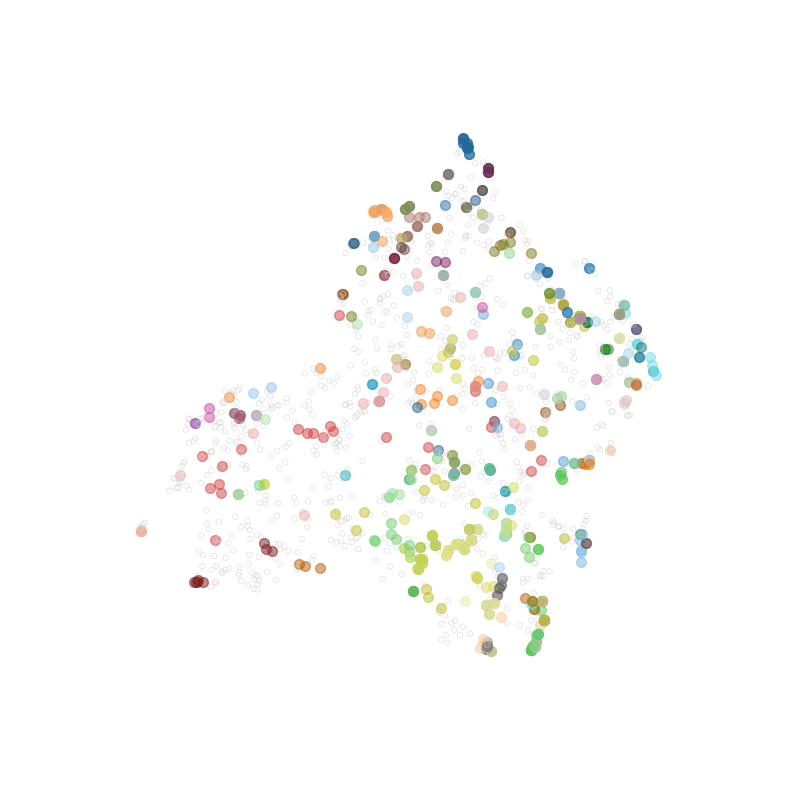

In [47]:
"""
Single OVERALL UMAP 
colored by odor response

"""
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

umap_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/{LEARN_MODE}_umap_df.csv', index_col = 0)
umap_df['odor_response'] = umap_df['odor_response'].apply(literal_eval)
umap_df['pred_odor_response'] = umap_df['pred_odor_response'].apply(literal_eval)


plot_by = 'odor_response'
# Assign a color per odor
color_map = cf.distinct_colors(ODOR_CATEGORIES, category='tab10')

CATEGORY_COLORS = cf.distinct_colors(ODOR_CATEGORIES, category = 'tab10')
ODOR_COLOR = {}
for _category in ps6_df.odor_category.unique():     
    ODOR_COLOR.update(cf.generate_faded_shades(CATEGORY_COLORS[_category],
                                     list(ps6_df[ps6_df.odor_category == _category].odor.sort_values().unique()), 
                                     (0.3,0.8)))
    

plot_df = umap_df.copy()


# --- Plot ---
plt.figure(figsize=(10,10))
# for _odor in ODORS:
    # _c?ategory = ODOR_TO_CAT.get(_odor)

    
for i, row in plot_df.iterrows(): 
    if row[plot_by]:
        for _odor in row['odor_response']:
            plt.scatter(row['UMAP_1'], row['UMAP_2'],
                        color= ODOR_COLOR[_odor] if _odor in row['odor_response'] else 'grey',
                        marker= 'o' if row['species'] == 0 else 'v',
                        alpha= 0.5,
                        s=50)
    else:
        plt.scatter(row['UMAP_1'], row['UMAP_2'],
                    edgecolor='#d3d3d3', facecolor='none', lw=0.5,
                    marker= 'o' if row['species'] == 0 else 'v',
                    s=15, alpha=0.7)
    
# legend_patches = [] 
# for _odor in ODOR_TO_CAT.keys():
#     legend_patches.append(mpatches.Patch(color=ODOR_COLOR[_odor], label=_odor))
        

# plt.legend(
#     # title=_category,
#             handles=legend_patches,
#             edgecolor='None', markerscale=2,
#             bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('off')

# --- Fix axis limits so all plots have the same zoom ---
x_min, x_max = umap_df['UMAP_1'].min(), umap_df['UMAP_1'].max()
y_min, y_max = umap_df['UMAP_2'].min(), umap_df['UMAP_2'].max()
pad_x = 0.25 * (x_max - x_min)
pad_y = 0.25 * (y_max - y_min)
x_min, x_max = x_min - pad_x, x_max + pad_x
y_min, y_max = y_min - pad_y, y_max + pad_y

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/Odor_umap.png', dpi=500)
plt.show()


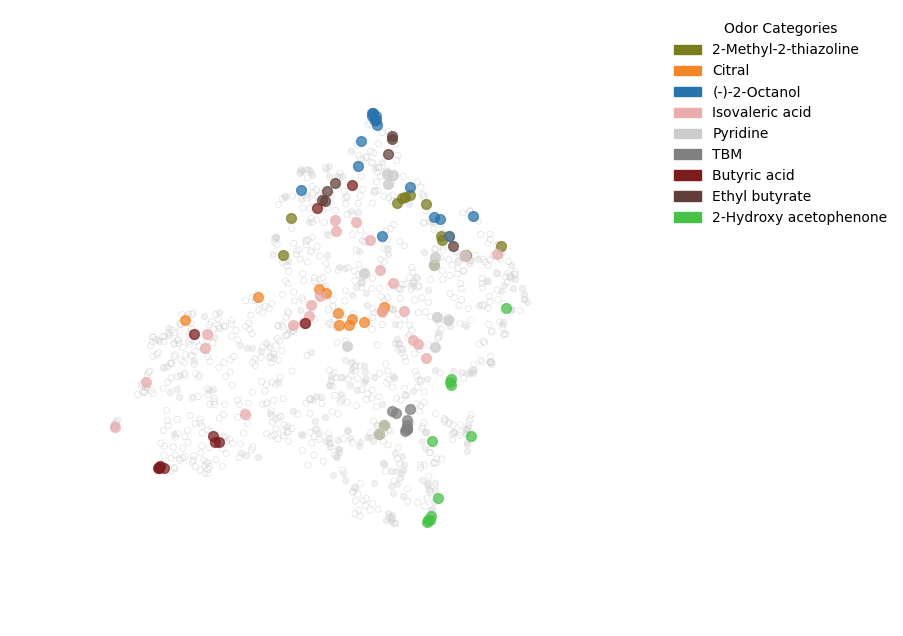

In [48]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

umap_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/{LEARN_MODE}_umap_df.csv', index_col = 0)
umap_df['odor_response'] = umap_df['odor_response'].apply(literal_eval)
umap_df['pred_odor_response'] = umap_df['pred_odor_response'].apply(literal_eval)

plot_odors = ['2-Methyl-2-thiazoline',
              'Citral',
              '(-)-2-Octanol',
              'Isovaleric acid',
              'Pyridine',
              'TBM',
              'Heptanal', 
              'Butyric acid', 
              '2-Hydroxy acetophenone', 
              ]


# --- Plot ---
plt.figure(figsize=(8,8))

# Scatter: individual ORs, color by first active odor (or gray if none)
for idx, row in umap_df.iterrows():
    if row['odor_response']:
        plt.scatter(row['UMAP_1'], row['UMAP_2'],
                    # color = FAM_COLOR.get(row['family']),
                    # color = 'black', 
                    color = '#D3D3D3',
                    s=20, alpha=0.3)
    else:
        # plt.scatter(row['UMAP_1'], row['UMAP_2'], color='lightgray', s=15, alpha=0.4)
        plt.scatter(row['UMAP_1'], row['UMAP_2'],
                    edgecolor = '#d3d3d3', facecolor='none',lw=0.5,
                    s=20, alpha=0.7)
        
# --- Fix axis limits so all plots have the same zoom ---
x_min, x_max = umap_df['UMAP_1'].min(), umap_df['UMAP_1'].max()
y_min, y_max = umap_df['UMAP_2'].min(), umap_df['UMAP_2'].max()

# Add a little padding so points aren't right on the edge
pad_x = 0.25 * (x_max - x_min)
pad_y = 0.25 * (y_max - y_min)

x_min, x_max = x_min - pad_x, x_max + pad_x
y_min, y_max = y_min - pad_y, y_max + pad_y

legend_patches = []
    
for _odor in plot_odors:     
    _category = ODOR_TO_CAT.get(_odor)
    subset = umap_df[[_odor in active for active in umap_df['odor_response']]]
    
    plt.scatter(subset['UMAP_1'], subset['UMAP_2'],
            # color=CATEGORY_COLORS[_category],
            color=ODOR_COLORS[_odor],
            s=50, alpha=0.7)
    
    # legend_patches.append(mpatches.Patch(color=CATEGORY_COLORS[_category], label=_odor))
    legend_patches.append(mpatches.Patch(color=ODOR_COLORS[_odor], label=_odor))

# plt.title("ORVoxel CNN latent space (UMAP) colored by Odor Categories")
plt.legend(title='Odor Categories',
            handles=legend_patches,
            edgecolor='None', markerscale=2,
            bbox_to_anchor=(0.9, 1), loc='upper left')
plt.axis('off')

    # --- Apply fixed zoom here ---
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/selected_odors_subplot_umap.png', dpi=300)
plt.show()


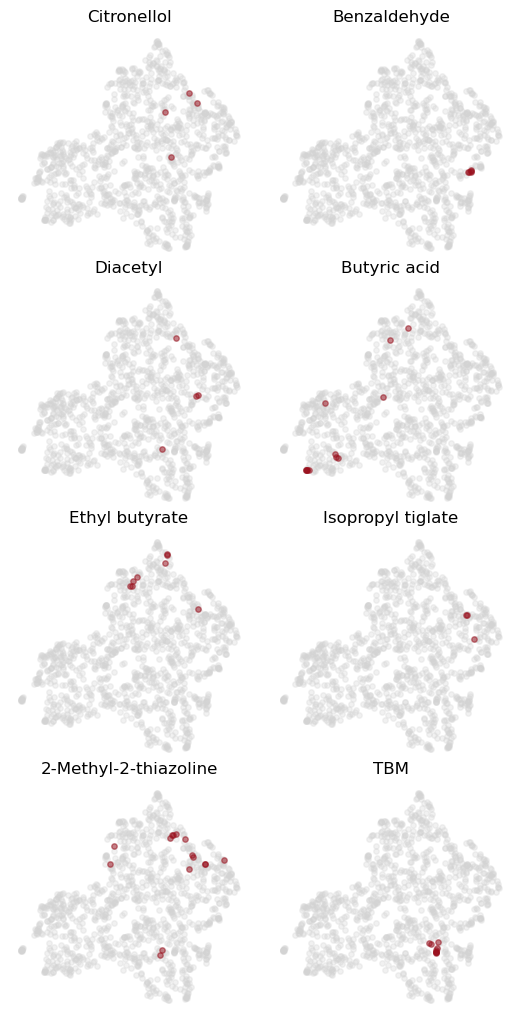

In [23]:
"""
Plot selected odors as facet. 
"""
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from plotly.subplots import make_subplots

umap_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/{LEARN_MODE}_umap_df.csv', index_col = 0)
umap_df['odor_response'] = umap_df['odor_response'].apply(literal_eval)
umap_df['pred_odor_response'] = umap_df['pred_odor_response'].apply(literal_eval)

plot_by = 'odor_response'
# Assign a color per odor

# plot_odors = ['2-Methyl-2-thiazoline',
#               'Citral',
#               '(-)-2-Octanol',
#               'Isovaleric acid',
#               'Pyridine',
#               'TBM',
#               'Heptanal', 
#               'Butyric acid', 
#               '2-Hydroxy acetophenone', 
#               ]
plot_odors = ['Citronellol',
              'Benzaldehyde',
              'Diacetyl',
              'Butyric acid',
              'Ethyl butyrate',
              'Isopropyl tiglate', 
            #   'Pyridine',
              '2-Methyl-2-thiazoline', 
              'TBM', 
              ]

n_odors = len(plot_odors)
ncols = 2
nrows = (n_odors + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5,10), squeeze=True)

for idx, _odor in enumerate(plot_odors):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row][col]

    # Plot all ORs in gray
    ax.scatter(umap_df['UMAP_1'], umap_df['UMAP_2'], color='#D3D3D3', s=15, alpha=0.3, label='All ORs')

    # Highlight ORs responsive to this odor
    mask = umap_df['odor_response'].apply(lambda x: _odor in x)
    subset = umap_df[mask]
    ax.scatter(subset['UMAP_1'], subset['UMAP_2'], color='#9B111E', s=15, alpha=0.5, label=_odor)

    ax.set_title(_odor)
    ax.axis('off')

# Remove empty subplots if n_odors is not a multiple of ncols
for idx in range(n_odors, nrows * ncols):
    fig.delaxes(axes[idx // ncols][idx % ncols])
    
plt.tight_layout(pad=0)
plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/selected_odors_subplot_umap.png', dpi=300)

plt.show()


In [ ]:

# most similar cid pairs via morgan_fp 
cid_euclid_distance = pd.read_csv('/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/pairwise/odorOR_cid_distance.csv', index_col = 0 )
cid_to_odor = {ps6_df[ps6_df.odor == _odor].cid.unique()[0]: _odor for _odor in ODORS}

cid_euclid_distance['odor_1'] = [cid_to_odor.get(_cid) for _cid in cid_euclid_distance['cid_1']]
cid_euclid_distance['odor_2'] = [cid_to_odor.get(_cid) for _cid in cid_euclid_distance['cid_2']]

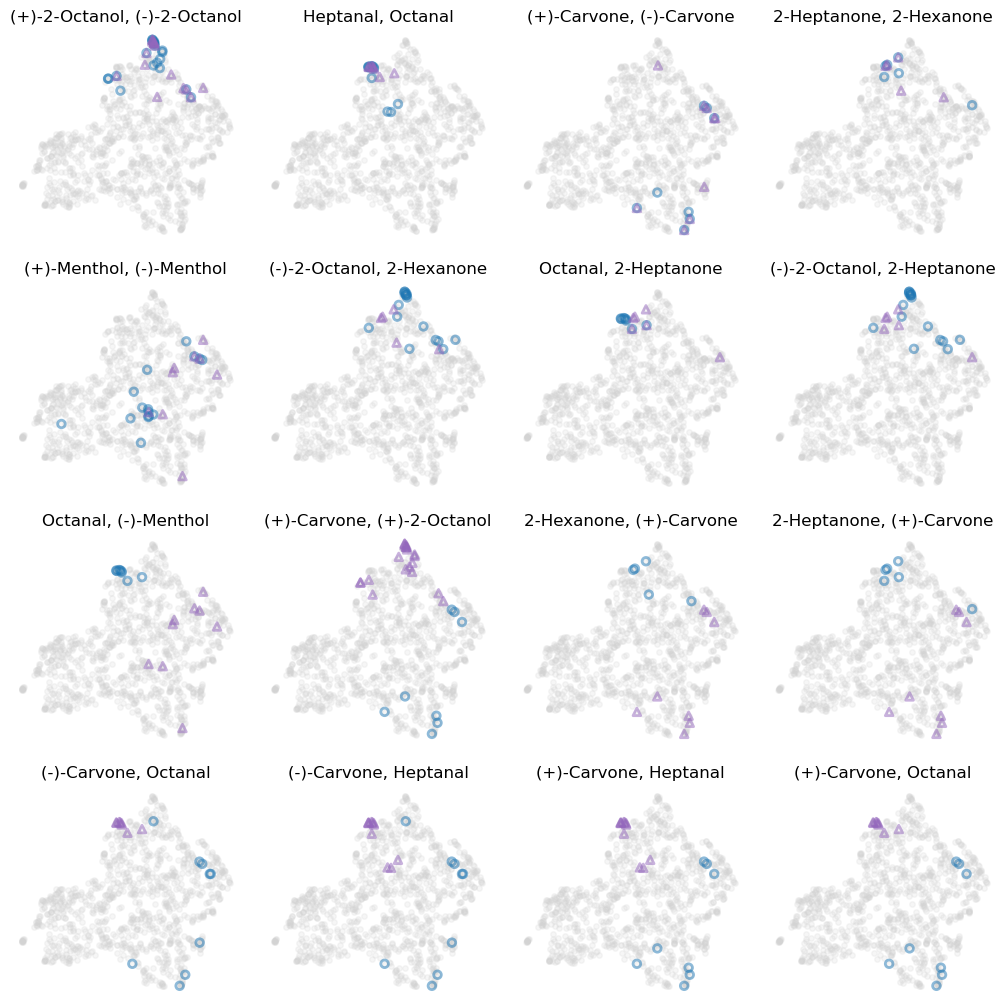

In [39]:
"""
Similar cid plot. To visualize the similarity in ORs across ligand
"""
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from plotly.subplots import make_subplots

umap_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/{LEARN_MODE}_umap_df.csv', index_col = 0)
umap_df['odor_response'] = umap_df['odor_response'].apply(literal_eval)
umap_df['pred_odor_response'] = umap_df['pred_odor_response'].apply(literal_eval)

plot_by = 'odor_response'

# most similar cid pairs via morgan_fp 
cid_euclid_distance = pd.read_csv('/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/pairwise/odorOR_cid_distance.csv', index_col = 0 )
cid_to_odor = {ps6_df[ps6_df.odor == _odor].cid.unique()[0]: _odor for _odor in ODORS}

cid_euclid_distance['odor_1'] = [cid_to_odor.get(_cid) for _cid in cid_euclid_distance['cid_1']]
cid_euclid_distance['odor_2'] = [cid_to_odor.get(_cid) for _cid in cid_euclid_distance['cid_2']]

# Assign a color per odor
unique_odors = np.unique(cid_euclid_distance.sort_values('cid_Distance')[['odor_1', 'odor_2']].head(5).values)
# plot_odors.extend(cid_euclid_distance.sort_values('cid_Distance')[['odor_1', 'odor_2']].tail(4).values)
# unique_odors = np.unique(np.array(plot_odors).ravel())
plot_odors = []
plot_odors.extend(cid_euclid_distance.loc[cid_euclid_distance.odor_1.isin(unique_odors) & cid_euclid_distance.odor_2.isin(unique_odors)].sort_values('wasserstein_zscore')[['odor_1', 'odor_2']].head(8).values)
# Get furthest distance of the similar odors  
plot_odors.extend(cid_euclid_distance.loc[cid_euclid_distance.odor_1.isin(unique_odors) & cid_euclid_distance.odor_2.isin(unique_odors)].sort_values('wasserstein_zscore')[['odor_2', 'odor_1']].tail(8).values)


markers = ['o', '^', '*']
palette = [sns.color_palette('tab10')[i] for i in [0, 4]]


n_odors = len(plot_odors)
ncols = 4
nrows = (n_odors + ncols - 1) // ncols

panel_size = (2.5, 2.5)  # inches per subplot
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols * panel_size[0], nrows * panel_size[1]),
    squeeze=True
)
for idx, odor_group in enumerate(plot_odors):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row][col]

    # Background: all ORs
    ax.scatter(
        umap_df['UMAP_1'],
        umap_df['UMAP_2'],
        color='#D3D3D3',
        s=15,
        alpha=0.2
    )

    # # Plot each odor in the group
    for j, odor in enumerate(odor_group):
        mask = umap_df[plot_by].apply(lambda x: odor in x)
        subset = umap_df[mask]

        ax.scatter(
            subset['UMAP_1'],
            subset['UMAP_2'],
            s=30,
            alpha=0.5,
            marker=markers[j % len(markers)],
            # color=palette[j % len(palette)],
            facecolor='none',
            edgecolor=palette[j % len(palette)],
            linewidth=2,
            label=odor
        )

    ax.set_title(', '.join(odor_group))
    ax.axis('off')
    

    # if len(odor_group) > 1:
    #     ax.legend(frameon=False, fontsize=7)

# Remove empty subplots
for idx in range(n_odors, nrows * ncols):
    fig.delaxes(axes[idx // ncols][idx % ncols])

plt.tight_layout(pad=0.5)
plt.subplots_adjust(wspace=0.1, hspace=0.2)

plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/odorOR_comparison_umap.png', dpi=300, transparent=True)

plt.show()


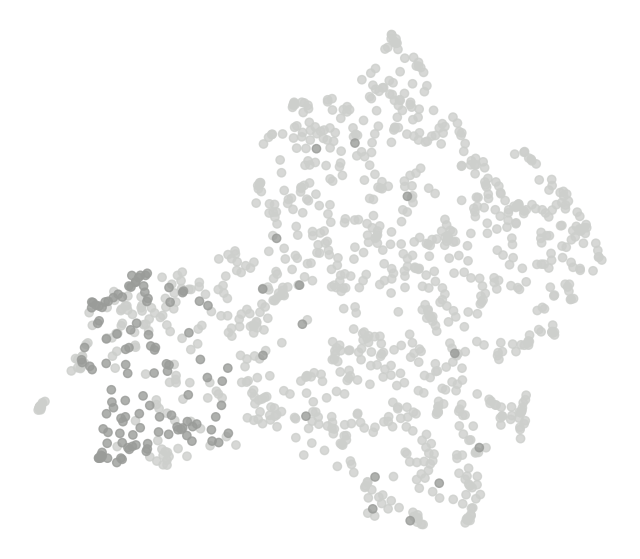

In [19]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

"""
Quickly Visualize family distribution on the overall map 
"""
umap_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/{LEARN_MODE}_umap_df.csv', index_col = 0)
umap_df['odor_response'] = umap_df['odor_response'].apply(literal_eval)
umap_df['pred_odor_response'] = umap_df['pred_odor_response'].apply(literal_eval)
umap_df['species'] = umap_df.name.str.isupper().astype(int)

umap_df['class'] = [1 if int(_fam) >= 50 else 2 for _fam in umap_df.family]

scatter_color_by = 'class'
CLASS_COLOR = cf.distinct_colors(np.sort(umap_df[scatter_color_by].unique()), custom_color=['#9A9C99', '#CDCFCC'])


plt.figure(figsize=(8,7))

plot_df = umap_df.sort_values('class', ascending=False)
plt.scatter(plot_df[plot_df.species == 0].UMAP_1, plot_df[plot_df.species == 0].UMAP_2,
            # c = '#D3D3D3', 
            c = [CLASS_COLOR.get(_fam) for _fam in plot_df[plot_df.species == 0][scatter_color_by]],
            alpha=0.8, 
            marker = 'o')
plt.axis('off')

plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/class_umap.png', dpi=300)
plt.show()

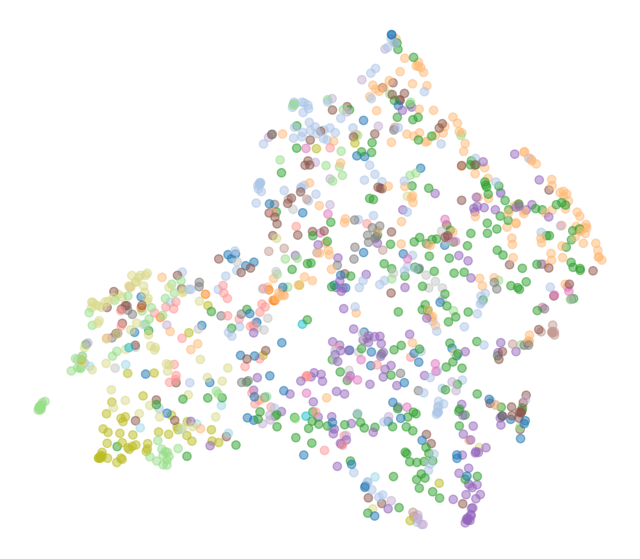

In [ ]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

"""
Quickly Visualize family distribution on the overall map 
"""
umap_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/{LEARN_MODE}_umap_df.csv', index_col = 0)
umap_df['odor_response'] = umap_df['odor_response'].apply(literal_eval)
umap_df['pred_odor_response'] = umap_df['pred_odor_response'].apply(literal_eval)
umap_df['species'] = umap_df.name.str.isupper().astype(int)


scatter_color_by = 'family'
FAM_COLOR = cf.distinct_colors(umap_df[scatter_color_by].sort_values().unique(), category='tab20')


plt.figure(figsize=(8,7))

# plt.scatter(umap_df[umap_df.species > 0].UMAP_1, umap_df[umap_df.species > 0].UMAP_2, 
#             c = [FAM_COLOR.get(_fam) for _fam in umap_df[umap_df.species > 0].family], 
#             marker = 'v', s= 100)
plt.scatter(umap_df[umap_df.species == 0].UMAP_1, umap_df[umap_df.species == 0].UMAP_2,
            # c = '#D3D3D3', 
            c = [FAM_COLOR.get(_fam) for _fam in umap_df[umap_df.species == 0].family], alpha=0.5, 
            marker = 'o')
plt.axis('off')

plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/family_umap.png', dpi=300)
plt.show()

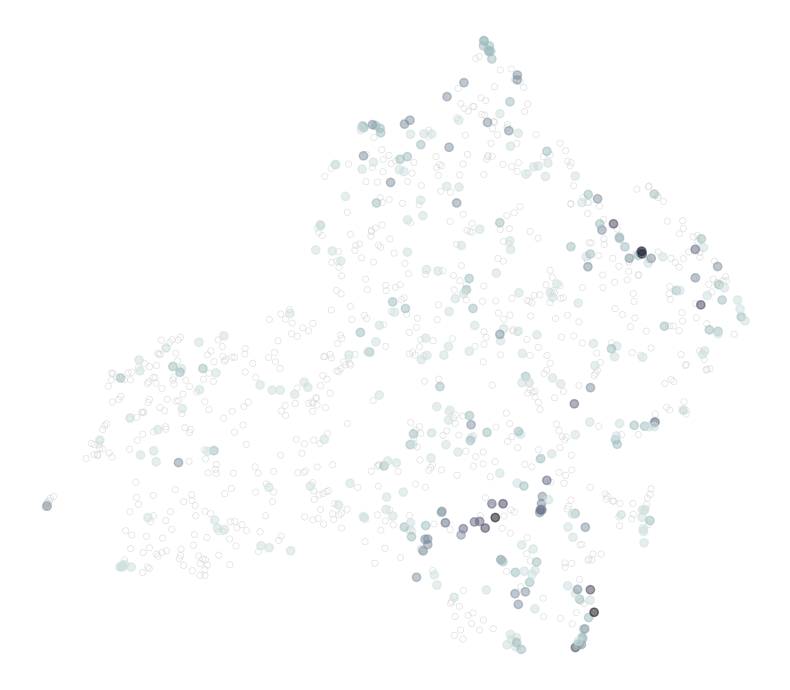

In [84]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches

"""
Quickly Visualize family distribution on the overall map 
"""

umap_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/{LEARN_MODE}_umap_df.csv', index_col = 0)
umap_df['odor_response'] = umap_df['odor_response'].apply(literal_eval)
umap_df['pred_odor_response'] = umap_df['pred_odor_response'].apply(literal_eval)

umap_df['n_response'] = umap_df.odor_response.apply(lambda x: len(x) if len(x) > 0 else np.nan)

scatter_color_by = 'n_response'

# Main scatter plot without colorbar
fig, ax = plt.subplots(figsize=(8,7))

plot_df = umap_df[umap_df.species == 0]

# Separate data: non-zero/non-nan vs zero/nan
mask_valid = ~plot_df['n_response'].isna() & (plot_df['n_response'] != 0)
mask_invalid = plot_df['n_response'].isna() | (plot_df['n_response'] == 0)

# Plot invalid data (0/NaN) in grey
ax.scatter(plot_df[mask_invalid].UMAP_1, plot_df[mask_invalid].UMAP_2,
          edgecolor = '#d3d3d3', facecolor='none',lw=0.5,
                    s=20, alpha=0.7)


# Plot valid data with colorscale
scat = ax.scatter(plot_df[mask_valid].UMAP_1, plot_df[mask_valid].UMAP_2,
            cmap='bone_r',
            # vmax=10, 
            vmin=0,
            c = plot_df[mask_valid]['n_response'],
            alpha=0.5, 
            marker = 'o')


ax.axis('off')
plt.tight_layout()
plt.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/Umap/n_activation_umap.png', dpi=300, transparent=True)
plt.show()



#### Feature Euclidean Distance

In [ ]:
from itertools import combinations
from scipy.spatial.distance import pdist

base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/final_model/20251118_173316_lr0.0001_bs4_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue'
LEARN_MODE = 'true'

voxel_names = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_voxel_names.npy"), allow_pickle=True)
all_features = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_embeddings.npy"))


# Compute pairwise distances (returns condensed form)
euclid_dist = pdist(all_features, metric='euclidean')
eulid_zscore = (euclid_dist - np.mean(euclid_dist)) / np.std(euclid_dist)
or_names = list(pd.DataFrame(voxel_names)[0].str.split('_').str[0])
pairs = list(combinations(or_names, 2))  

# Create labeled DataFrame
eulid_distance = pd.DataFrame(pairs, columns=['OR1', 'OR2'])
eulid_distance['Euclid_Distance'] = euclid_dist
eulid_distance['Euclid_Distance_zscore'] = eulid_zscore

In [ ]:
import plotly.graph_objects as go 
import random

random.seed(0) 

# Bar plot to show ESM euclidean distance between OR responding to the same ligands via pS6

fig = go.Figure()

# Randomly sample same number of comparisons for shuffled control
OR_mask = random.sample(list(ps6_df.DL_OR.unique()), 
                        20)
shuffled_data = eulid_distance[(eulid_distance.OR1.isin(OR_mask)) &
                             (eulid_distance.OR2.isin(OR_mask))]

# Shuffled control bar
fig.add_trace(go.Violin(
    x=['Shuffled'] * len(shuffled_data),
    y=shuffled_data['Euclid_Distance_zscore'],
    meanline=dict(visible=True), 
    name='Shuffled',
    marker=dict(color='#D3D3D3', opacity=1),
    legendgroup='Shuffled'
))


for _odor in ODORS: 
    # Subset: DL_OR comparisons
    ps6_subset = ps6_df[(ps6_df.odor == _odor) & 
                        (ps6_df.activation_zscore >= 2)]
    if len(ps6_subset) <= 2: 
        continue
    
    cid = ps6_subset.cid.unique().astype(str).item()
    # odor_group = ps6_subset.odor_category.unique().item()
    # concentration = ps6_subset.concentration.unique().astype(str).item()
    OR_mask = ps6_subset.DL_OR
    
    odor_data = eulid_distance[(eulid_distance.OR1.isin(OR_mask)) &
                            (eulid_distance.OR2.isin(OR_mask))]
    
    fig.add_trace(go.Violin(
        x=[_odor] * len(odor_data),
        y=odor_data['Euclid_Distance_zscore'].values,
        name=f'{_odor} ({cid})',
        meanline=dict(visible=True), 
        # mode = 'markers', 
        marker=dict(color=ODOR_COLORS[_odor],
                    opacity=0.5),
        # offsetgroup=concentration,
        legendgroup=cid
    ))
    
from scipy import stats  
label = []
label_symbols = []
for _pairs in [[0,i] for i in range(len(fig.data))]:
    tstat, pvalue = stats.ttest_ind(
        fig['data'][_pairs[0]]['y'],
        fig['data'][_pairs[1]]['y'], 
        alternative='greater')
    label.append([_pairs[1], _pairs[1]])
    label_symbols.append(pf.format_pvalue(pvalue, p_round=1, 
                                            show='symbol'
                                            ))
        
fig = pf.add_p_value_annotation(fig, 
                                label, 
                                just_annotate = label_symbols, 
                                y_padding=False,
                                font_size=10, 
                                _format=dict(interline=0.00, text_height=1, color='black'))


# fig.add_hline(y=shuffled_data['ESM_Distance_zscore'].mean(), line_width=3, line_dash="dash", line_color="#D3D3D3", opacity = 0.5)
fig.add_hline(y=0, line_width=3, line_dash="dash", line_color="#D3D3D3", opacity = 0.5)

fig.update_layout(
    title="SpatialESM pairwise Euclidean distance for pS6-IP odor responding ORs <br><sup>ttest_ind against shuffle",
    yaxis_title="SpatialESM pairwise Euclidean distance",
    xaxis_title="", xaxis=dict(tickangle=45),
    barmode='group', 
    height=600, width=1200, 
    showlegend=False
)

fig.update_layout(template = 'simple_white')
fig.show()

# fig.write_html('/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/pairwise/odorOR_euclidist_violin.html')
# fig.write_image('/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/pairwise/odorOR_euclidist_violin.svg', height=600, width=1200, scale=3)



In [34]:
import plotly.graph_objects as go 
import random

random.seed(0) 

# Bar plot to show ESM euclidean distance between OR responding to the same ligands via pS6

fig = go.Figure()


for _odor in ODORS[::-1]: 
    # Subset: DL_OR comparisons
    ps6_subset = ps6_df[(ps6_df.odor == _odor) & 
                        (ps6_df.activation_zscore >= 2)]
    if len(ps6_subset) <= 2: 
        continue
    
    cid = ps6_subset.cid.unique().astype(str).item()
    # odor_group = ps6_subset.odor_category.unique().item()
    # concentration = ps6_subset.concentration.unique().astype(str).item()
    OR_mask = ps6_subset.DL_OR
    
    odor_data = eulid_distance[(eulid_distance.OR1.isin(OR_mask)) &
                            (eulid_distance.OR2.isin(OR_mask))]
    
    fig.add_trace(go.Violin(
        y=[_odor] * len(odor_data),
        x=odor_data['Euclid_Distance_zscore'].values,
        name=f'{_odor} ({cid})',
        meanline=dict(visible=True), 
        pointpos=0.5, 
        # mode = 'markers', 
        marker=dict(color=ODOR_COLORS[_odor],
                    opacity=0.5),
        # offsetgroup=concentration,
        legendgroup=cid
    ))
    
# Randomly sample same number of comparisons for shuffled control
OR_mask = random.sample(list(ps6_df.DL_OR.unique()), 
                        20)
shuffled_data = eulid_distance[(eulid_distance.OR1.isin(OR_mask)) &
                             (eulid_distance.OR2.isin(OR_mask))]

# Shuffled control bar
fig.add_trace(go.Violin(
    y=['Shuffled'] * len(shuffled_data),
    x=shuffled_data['Euclid_Distance_zscore'],
    pointpos=0.5,
    meanline=dict(visible=True), 
    name='Shuffled',
    marker=dict(color='#D3D3D3', opacity=1),
    legendgroup='Shuffled'
))
    
from scipy import stats  
label = []
label_symbols = []
for _pairs in [[len(fig.data)-1,i] for i in range(len(fig.data)-1)]:
    tstat, pvalue = stats.ttest_ind(
        fig['data'][_pairs[0]]['x'],
        fig['data'][_pairs[1]]['x'], 
        alternative='greater')
    label.append([_pairs[1], _pairs[1]])
    label_symbols.append(pf.format_pvalue(pvalue, p_round=1, 
                                            show='symbol'
                                            ))
        
fig = pf.add_p_value_annotation(fig, 
                                label, 
                                just_annotate = label_symbols, 
                                y_padding=False,
                                font_size=10, 
                                _format=dict(interline=0.00, text_height=1, color='black'), 
                                horizontal=True)



fig.add_vline(x=0, line_width=3, line_dash="dash", line_color="#D3D3D3", opacity = 0.8)

fig.update_traces(orientation='h', 
                  points=False, 
                #   points='all', jitter=0.2,
                  side='positive', width=1.8)

fig.update_layout(
    # title="SpatialESM pairwise Euclidean distance for pS6-IP odor responding ORs <br><sup>ttest_ind against shuffle",
    xaxis_title="SpatialESM pairwise Euclidean distance",
    yaxis_title="", 
    barmode='group', violingap=1, 
    height=1500, width=400, 
    showlegend=False, 
    template='simple_white'
)

yrange = [-0.5, (len(ODORS)+1) + 0.5]
fig.update_layout(yaxis_range=yrange, 
                  xaxis_range=[-4,4],
                  margin=dict(l=20, r=50, t=20, b=20))
fig.show()

# fig.write_image('/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/pairwise/odorOR_euclidist_violin2.svg', 
#                 height=1500, width=400)

In [ ]:
# Calculating PCA dist, deprecated. Replaced with Euclidean Distance across all features 


# from itertools import combinations
# from scipy.spatial.distance import pdist

# LEARN_MODE = 'true'

# # SpatialESM PCA
# pca_df = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/{LEARN_MODE}_pca_df.csv', index_col = 0)
# pca_df['odor_response'] = pca_df['odor_response'].apply(literal_eval)
# pca_df['pred_odor_response'] = pca_df['pred_odor_response'].apply(literal_eval)

# # Compute pairwise distances (returns condensed form)
# pca_dist = pdist(pca_df[['PCA_1', 'PCA_2']], metric='euclidean')
# pca_zscore = (pca_dist - np.mean(pca_dist)) / np.std(pca_dist)
# or_names = list(pca_df.name.str.split('_').str[0])
# pairs = list(combinations(or_names, 2))  

# # Create labeled DataFrame
# pca_distance = pd.DataFrame(pairs, columns=['OR1', 'OR2'])
# pca_distance['ESM_Distance'] = pca_dist
# pca_distance['ESM_Distance_zscore'] = pca_zscore

# import plotly.graph_objects as go 
# import random

# random.seed(0) 

# # Bar plot to show ESM euclidean distance between OR responding to the same ligands via pS6

# fig = go.Figure()

# # Randomly sample same number of comparisons for shuffled control
# OR_mask = random.sample(list(ps6_df.DL_OR.unique()), 
#                         20)
# shuffled_data = pca_distance[(pca_distance.OR1.isin(OR_mask)) &
#                              (pca_distance.OR2.isin(OR_mask))]

# # Shuffled control bar
# fig.add_trace(go.Violin(
#     x=['Shuffled'] * len(shuffled_data),
#     y=shuffled_data['ESM_Distance_zscore'],
#     meanline=dict(visible=True), 
#     name='Shuffled',
#     marker=dict(color='#D3D3D3', opacity=1),
#     legendgroup='Shuffled'
# ))


# for _odor in ODORS: 
#     # Subset: DL_OR comparisons
#     ps6_subset = ps6_df[(ps6_df.odor == _odor) & 
#                         (ps6_df.activation_zscore >= 2)]
#     if len(ps6_subset) <= 2: 
#         continue
    
#     cid = ps6_subset.cid.unique().astype(str).item()
#     # odor_group = ps6_subset.odor_category.unique().item()
#     # concentration = ps6_subset.concentration.unique().astype(str).item()
#     OR_mask = ps6_subset.DL_OR
    
#     odor_data = pca_distance[(pca_distance.OR1.isin(OR_mask)) &
#                             (pca_distance.OR2.isin(OR_mask))]
    
#     fig.add_trace(go.Violin(
#         x=[_odor] * len(odor_data),
#         y=odor_data['ESM_Distance_zscore'].values,
#         name=f'{_odor} ({cid})',
#         meanline=dict(visible=True), 
#         # mode = 'markers', 
#         marker=dict(color=ODOR_COLORS[_odor],
#                     opacity=0.5),
#         # offsetgroup=concentration,
#         legendgroup=cid
#     ))
    
# from scipy import stats  
# label = []
# label_symbols = []
# for _pairs in [[0,i] for i in range(len(fig.data))]:
#     tstat, pvalue = stats.ttest_ind(
#         fig['data'][_pairs[0]]['y'],
#         fig['data'][_pairs[1]]['y'], 
#         alternative='two-sided')
#     label.append([_pairs[1], _pairs[1]])
#     label_symbols.append(pf.format_pvalue(pvalue, p_round=1, 
#                                             show='symbol'
#                                             ))
        
# fig = pf.add_p_value_annotation(fig, 
#                                 label, 
#                                 just_annotate = label_symbols, 
#                                 y_padding=False,
#                                 font_size=10, 
#                                 _format=dict(interline=0.00, text_height=1, color='black'))


# # fig.add_hline(y=shuffled_data['ESM_Distance_zscore'].mean(), line_width=3, line_dash="dash", line_color="#D3D3D3", opacity = 0.5)
# fig.add_hline(y=0, line_width=3, line_dash="dash", line_color="#D3D3D3", opacity = 0.5)

# fig.update_layout(
#     title="SpatialESM PCA pairwise euclidean distance for pS6-IP odor responding ORs <br><sup>ttest_ind against shuffle",
#     yaxis_title="SpatialESM pairwise euclidean distance",
#     xaxis_title="", xaxis=dict(tickangle=45),
#     barmode='group', 
#     height=600, width=1200, 
#     showlegend=False
# )

# fig.update_layout(template = 'simple_white')
# fig.show()

# fig.write_html('/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/pairwise/odorOR_PCAdist_violin.html')
# fig.write_image('/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/pairwise/odorOR_PCAdist_violin.svg', height=600, width=1200, scale=3)



In [20]:
"""
by odor category 
"""

import plotly.graph_objects as go 
import random

random.seed(1) 

# Bar plot to show ESM euclidean distance between OR responding to the same ligands via pS6

fig = go.Figure()

# Randomly sample same number of comparisons for shuffled control
OR_mask = random.sample(list(ps6_df.DL_OR.unique()), 
                        100)
shuffled_data = pca_distance[(pca_distance.OR1.isin(OR_mask)) &
                             (pca_distance.OR2.isin(OR_mask))]

# Shuffled control bar
fig.add_trace(go.Violin(
    x=['Shuffled'] * len(shuffled_data),
    y=shuffled_data['ESM_Distance_zscore'],
    meanline=dict(visible=True), 
    name='Shuffled',
    marker=dict(color='#D3D3D3', opacity=1),
    legendgroup='Shuffled'
))

# Assign a color per odor
color_map = cf.distinct_colors(ODOR_CATEGORIES, category='tab10')
CATEGORY_COLORS = cf.distinct_colors(ODOR_CATEGORIES, category = 'tab10')

for _category in ODOR_CATEGORIES:
    # Subset: DL_OR comparisons
    ps6_subset = ps6_df[(ps6_df.odor_category == _category) & 
                        (ps6_df.activation_zscore >= 2)]
    if len(ps6_subset) <= 2: 
        continue
    
    odor_group = ps6_subset.odor_category.unique().item()
    # concentration = ps6_subset.concentration.unique().astype(str).item()
    OR_mask = ps6_subset.DL_OR
    
    odor_data = pca_distance[(pca_distance.OR1.isin(OR_mask)) &
                            (pca_distance.OR2.isin(OR_mask))]
    
    fig.add_trace(go.Violin(
        x=[_category] * len(odor_data),
        y=odor_data['ESM_Distance_zscore'].values,
        name=f'{_category}',
        meanline=dict(visible=True), 
        # mode = 'markers', 
        marker=dict(color=CATEGORY_COLORS[_category],
                    opacity=0.5),
        # offsetgroup=concentration,
        legendgroup=_category
    ))

from scipy import stats  
label = []
label_symbols = []
for _pairs in [[0,i] for i in range(len(fig.data))]:
    tstat, pvalue = stats.ttest_ind(
        fig['data'][_pairs[1]]['y'],
        fig['data'][_pairs[0]]['y'], 
        alternative='less')
    label.append([_pairs[1], _pairs[1]])
    label_symbols.append(pf.format_pvalue(pvalue, p_round=1, 
                                            show='symbol'
                                            ))
        
fig = pf.add_p_value_annotation(fig, 
                                label, 
                                just_annotate = label_symbols, 
                                y_padding=False,
                                font_size=10, 
                                _format=dict(interline=0.00, text_height=1, color='black'))


# fig.add_hline(y=shuffled_data['ESM_Distance_zscore'].mean(), line_width=3, line_dash="dash", line_color="#D3D3D3", opacity = 0.5)
fig.add_hline(y=0, line_width=3, line_dash="dash", line_color="#D3D3D3", opacity = 0.5)

fig.update_layout(
    title="SpatialESM PCA pairwise euclidean distance for pS6-IP odor responding ORs <br><sup>ttest_ind against shuffle",
    yaxis_title="SpatialESM pairwise euclidean distance",
    xaxis_title="", xaxis=dict(tickangle=45),
    barmode='group', 
    height=600, width=600, 
    showlegend=False
)

fig.update_layout(template = 'simple_white')
fig.show()

fig.write_html('/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Features/PCA/pairwise/categoryOR_PCAdist_violin.html')


### Importance Extraction 

In [4]:
"""
Initialize Variables
"""

import os 
import sys
import pandas as pd 
import numpy as np 
from ast import literal_eval

OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

import plot_functions as pf
import color_function as cf 
import voxel_functions as vf 
import SequenceAlignment_functions as sa 

base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/final_model/20251118_173316_lr0.0001_bs4_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

# Load pS6-IP data 
ps6_df = pd.read_csv('../../files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
ps6_df.odor_category = ps6_df.odor_category.astype(pd.CategoricalDtype(categories=['Alcohols', 'Aldehydes', 'Ketones','CarboxylicAcids', 'Esters',
                                                                                   'Tiglates', 'Pyradine', 'Thiazole', 'Sulfurous', 'Others'], ordered=True))
# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()
ps6_df = ps6_df[ps6_df.odor_category != 'Others']

ODOR_CATEGORIES = ps6_df.odor_category.sort_values().unique()
ODORS = [_odor for _cat in ODOR_CATEGORIES for _odor in ps6_df[ps6_df.odor_category == _cat].dropna().sort_values(['cid_mw', 'odor']).odor.unique()]
ODOR_TO_CAT = dict(zip(ps6_df.odor, ps6_df.odor_category))
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODORS)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODORS)}
NUM_ODORS = len(ODORS)
CATEGORY_COLORS = cf.distinct_colors(ODOR_CATEGORIES, category = 'tab10')
ODOR_COLORS = {}
for _category in ODOR_CATEGORIES:     
    ODOR_COLORS.update(cf.generate_faded_shades(CATEGORY_COLORS[_category],
                                     list(ps6_df[ps6_df.odor_category == _category].sort_values(['cid_mw', 'odor']).odor.unique()), 
                                     (0.4,0.8)))
    
OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

LEARN_MODE = 'true'



odor_importances_zscore = np.load(os.path.join(base_dir, f"feature/{LEARN_MODE}_odor_importances_zscore.npy"), allow_pickle=True).item()

# Load in voxel information
voxels_info = pd.read_csv(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/{LEARN_MODE}_voxels_info.csv', index_col=0)
voxels_info['odor_response'] = voxels_info['odor_response'].apply(literal_eval)



In [5]:
"""
Reload the voxel in sparse form and no radius for visualization 
"""


Cbc_cav_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_cav_coords2.pkl')
Cbc_res_coords = pd.read_pickle('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_dict_Cbc_res_coords2.pkl')

# voxel_names = np.load(os.path.join(base_dir, "voxel_names.npy"), allow_pickle=True)

# Extracting the voxels used in model 
Cbc_cav_coords = {_key: _values for _key, _values in Cbc_cav_coords.items() if _key.capitalize() in list(voxels_info.voxel_name)}
Cbc_res_coords = {_key: _values for _key, _values in Cbc_res_coords.items() if _key.capitalize() in list(voxels_info.voxel_name)}

center_reference = np.load('/mnt/data2/Justice/OR_learning/files/binding_cavity/AF3_center_reference.npy')
voxels, grid_shape = vf.voxelize_cavity(cavity_coords = Cbc_cav_coords,
                                        residue_coords = Cbc_res_coords,
                                        resolution = 1, 
                                        cube_dim = 32, reference_center = center_reference, 
                                        encode_method='res', 
                                        sparse_mode = True, 
                                        vdw_radius = True )

voxel_names = list(Cbc_res_coords.keys())

# Trim down voxels to save memory 
del Cbc_cav_coords, Cbc_res_coords

Encoding voxels via res...
Generating voxels. . .


100%|██████████| 1115/1115 [01:10<00:00, 15.89it/s]


In [16]:
for _key in [_k for _k in Cbc_res_coords.keys() if 'Or2t43' in _k]: 
    print(list(np.sort(np.unique(Cbc_res_coords[_key][:,0]).astype(int))))

[71, 102, 103, 106, 107, 110, 153, 201, 204, 205, 249, 253, 257, 276]
[71, 102, 103, 106, 107, 110, 153, 157, 197, 200, 201, 204, 249, 252, 253, 257, 276]
[71, 102, 103, 106, 107, 110, 153, 157, 197, 200, 201, 204, 253, 257, 276]
[71, 102, 103, 106, 107, 110, 153, 201, 204, 249, 253, 257, 276]
[71, 102, 103, 106, 107, 110, 153, 157, 178, 197, 200, 201, 204, 252, 253, 256, 257, 276]


In [8]:
from Bio import SeqIO
import SequenceAlignment_functions as sa
"""
Read in sequence alignment file 
"""
fasta_path = '/mnt/data2/Justice/OR_learning/files/OR_seq/mouseOR_alignment.fasta'
Olfr_DL = np.load('/mnt/data2/Justice/OR_learning/files/Olfr_DL.npy', allow_pickle=True).item()

sequences = []
for record in SeqIO.parse(fasta_path, "fasta"):
    seq_str = str(record.seq)
    sequences.append((record.id, seq_str))

alignment_df = pd.DataFrame(
    [list(seq) for _, seq in sequences],
    columns=range(1, len(sequences[0][1]) + 1),
    index=[Olfr_DL.get(seq_id, seq_id).capitalize() for seq_id, _ in sequences]
)
alignment = alignment_df.apply(lambda row: ''.join(row.values), axis=1).to_dict()


"""
BW position mapping 
"""
Or51E2_bw_positions = {"N41":'1.50', "D69": '2.50', "R121":'3.50', 
                       "V149":'4.50', "C178":'45.50', "D209":'5.50', 
                       "P253":'6.50', "P288":'7.50'}
Or51E2_bw_positions = {f"{_k[0]}{int(_k[1:])}": Or51E2_bw_positions[_k] for _k in Or51E2_bw_positions}

# Create alignment bw reference position, This position is True bw for the entire alignment 
alignment_bw = sa.update_bw_positions("Or51e2", alignment, Or51E2_bw_positions)


In [ ]:
"""
Plotting by aggregated category importance 
"""

import plotly.graph_objects as go 
from scipy.spatial.transform import Rotation as R

# Default rotation (example: rotate 180, 0, 150° about x,y,z) This sets OR in upright view
default_rot = R.from_euler("xyz", [150, 320, 180], degrees=True)


importance_threshold = 2

IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}
IDX_TO_AA_RES_SINGLE = {i+1: sa.AA_THREE_TO_ONE.get(res) for i, res in enumerate(vf.AA_RES_OHE)}

for _category in ODOR_CATEGORIES:
    # if _category != 'Aldehydes': 
    #     continue

    # Make consesnus voxel instead of plotting all the individual voxels overlaying each other 
    subset_voxels_info = voxels_info[voxels_info.odor_response.apply(lambda x: _category in [ODOR_TO_CAT.get(_x) for _x in x])].reset_index(names='voxel_idx')
    plot_voxels = [voxels[i] for i in subset_voxels_info.voxel_idx]

    if len(plot_voxels) == 0: 
        continue
    # Convert voxel indices to residue names + numbers
    for idx, row in subset_voxels_info.iterrows():
        res_to_map = [ IDX_TO_AA_RES.get(int(i[1])) + str(int(i[0])) for i in np.unique(list(plot_voxels[idx].values()), axis=0)]

        res_bw_dict = sa.map_residues_to_bw(residue_list = res_to_map,
                                            alignment = alignment, 
                                            target_seq_name = row.OR, 
                                            bw_positions = alignment_bw)
        
        # Update plot_voxel for the bw labels 
        updated_plot_voxels = {}
        for coord, tensor_val in plot_voxels[idx].items():
            res_num = int(tensor_val[0].item())
            res_idx = int(tensor_val[1].item())
            
            # Convert residue index -> AA letter
            aa = IDX_TO_AA_RES_SINGLE.get(res_idx, "?")
            res_key = f"{aa}{res_num}"
            
            # Lookup BW number if available
            bw_number = res_bw_dict.get(res_key, None)
            
            # Store as (res_num, res_idx, bw_number)
            updated_plot_voxels[coord] = (res_num, res_idx, bw_number)
            
        plot_voxels[idx] = updated_plot_voxels

    plot_voxels_cons = vf.sparse_voxel_consensus_res(plot_voxels, threshold=0.15, use_bw=True)
    positions = np.array(list(plot_voxels_cons))


    X, Y, Z = positions[:,0], positions[:,1], positions[:,2]
    
    # Apply default rotation to your voxel coordinates, set OR upright
    coords = np.vstack([X, Y, Z ]).T         # shape (N, 3)
    coords_rot = default_rot.apply(coords)
    X, Y, Z = coords_rot[:,0], coords_rot[:,1], coords_rot[:,2]

    res = np.array(list(plot_voxels_cons.values()))[:,0].astype(int)
    cons_ratio = np.array(list(plot_voxels_cons.values()))[:,1].astype(float)
    bw = np.array(list(plot_voxels_cons.values()))[:,2].astype(str)

    color = cf.distinct_colors(list(vf.AA_RES_OHE), category='tab20')
    IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}

    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=X, y=Y, z=Z,
        mode='markers',
        name=_category,
        marker=dict(
            size=10,  # adjust marker size
            # color=[color.get(IDX_TO_AA_RES.get(_res)) for _res in res],  
            color = '#D3D3D3',
            opacity=0.1
        ), 
        # text=[f"Residue {n} {IDX_TO_AA_RES.get(r)}" for n, r in zip(res_num.astype(int), res)],  # hover text
        text=[f"{IDX_TO_AA_RES.get(_r)}, {_bw} {np.round(_ratio, 2)*100}%" for _r, _bw, _ratio in zip(res, bw, cons_ratio)],  # hover text
        hoverinfo="text"
    ))
        
        
    # Add importance volumes
    # plot_voxel = odor_importances_zscore[_odor]
    # X, Y, Z = np.indices(plot_voxel.shape)

    # fig.add_trace(go.Volume(
    #     x=X.flatten(),
    #     y=Y.flatten(),
    #     z=Z.flatten(),
    #     name='feature', 
    #     value=[i if np.abs(i) >= importance_threshold else 0 for i in plot_voxel.flatten()],
    #     isomin=-np.max(np.abs(plot_voxel)),
    #     isomax= np.max(np.abs(plot_voxel)),
    #     opacity=0.5,  # global scaling factor
    #     surface_count=10,  # number of contour surfaces
    #     colorscale="RdBu_r", # red/blue diverging
    #     showscale=False,
    #     showlegend=True, 
    #     hoverinfo='skip', 
    #     caps=dict(x_show=False, y_show=False, z_show=False)  # hide box caps
    # ))

    # Add importance as scatter
    odors = [_k for _k, _v in ODOR_TO_CAT.items() if _v == _category]
    plot_voxel = np.sum(np.array([odor_importances_zscore[_odor] for _odor in odors]), axis=0) / len(odors)
    # plot_voxel = odor_importances_zscore[_odor]
    occupied_voxels = np.array(np.where((np.abs(plot_voxel) >= importance_threshold))).T
    x, y, z = occupied_voxels[:, 0], occupied_voxels[:, 1], occupied_voxels[:, 2]
    values = plot_voxel[x, y, z]
    
    # Apply default rotation to your voxel coordinates, set OR upright
    coords = np.vstack([x, y, z ]).T         # shape (N, 3)
    coords_rot = default_rot.apply(coords)
    x, y, z = coords_rot[:,0], coords_rot[:,1], coords_rot[:,2]

    # Plot scatter with color scale
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        name="Importance",
        marker=dict(
            size=5,  # adjust marker size
            color=values,  # importance values
            colorscale="RdBu_r",  # red-blue colormap
            # cmin=-np.max(np.abs(values)),  # symmetric color range
            # cmax=np.max(np.abs(values)),
            cmin=-np.max(values), cmax=np.max(values),
            showscale=True, 
            opacity=1,
            colorbar=dict(title="Importance", 
                          len=0.7,  # Length of the colorbar (fraction of plot height)
                          lenmode='fraction', # Can be 'fraction' or 'pixels'
                          thickness=20, # Thickness of the colorbar in pixels
                          thicknessmode='pixels'
                          )
        )
    ))

    # Determine global min/max from both scatter and volume
    # Collect all x, y, z across traces in fig.data
    all_x, all_y, all_z = [], [], []
    for trace in fig.data:
        if hasattr(trace, "x") and trace.x is not None:
            all_x.extend(trace.x)
        if hasattr(trace, "y") and trace.y is not None:
            all_y.extend(trace.y)
        if hasattr(trace, "z") and trace.z is not None:
            all_z.extend(trace.z)

    # Convert to arrays for min/max
    all_x, all_y, all_z = np.array(all_x), np.array(all_y), np.array(all_z)

    fig.update_layout(
        scene=dict(
            xaxis=dict(range=[all_x.min(), all_x.max()], autorange=False),
            yaxis=dict(range=[all_y.min(), all_y.max()], autorange=False),
            zaxis=dict(range=[all_z.min(), all_z.max()], autorange=False),
            aspectmode="cube"  # keeps scaling equal across axes
        )
    )

    fig = pf._plotly_blank_style(fig)

    fig.write_html(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/scatter/{_category}_Importance_ConsVox_scatter.html')

    fig.show()
    # break
        

In [ ]:
import plotly.graph_objects as go 
from scipy.spatial.transform import Rotation as R

# Default rotation (example: rotate 180, 0, 150° about x,y,z) This sets OR in upright view
default_rot = R.from_euler("xyz", [150, 320, 180], degrees=True)

importance_threshold = 3


IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}
IDX_TO_AA_RES_SINGLE = {i+1: sa.AA_THREE_TO_ONE.get(res) for i, res in enumerate(vf.AA_RES_OHE)}

for _odor in ODORS:
    
    if _odor != 'TBM': 
        continue
    
    _category = ODOR_TO_CAT.get(_odor)

    # Make consesnus voxel instead of plotting all the individual voxels overlaying each other 
    # subset_voxels_info = voxels_info[voxels_info.odor_response.apply(lambda x: _odor in [ODOR_TO_CAT.get(_x) for _x in x])].reset_index(names='voxel_idx')
    subset_voxels_info = voxels_info[voxels_info.odor_response.apply(lambda x: _odor in [_x for _x in x])].reset_index(names='voxel_idx')
    plot_voxels = [voxels[i] for i in subset_voxels_info.voxel_idx]

    if len(plot_voxels) == 0: 
        continue
    # Convert voxel indices to residue names + numbers
    for idx, row in subset_voxels_info.iterrows():
        res_to_map = [ IDX_TO_AA_RES.get(int(i[1])) + str(int(i[0])) for i in np.unique(list(plot_voxels[idx].values()), axis=0)]

        res_bw_dict = sa.map_residues_to_bw(residue_list = res_to_map,
                                            alignment = alignment, 
                                            target_seq_name = row.OR, 
                                            bw_positions = alignment_bw)
        
        # Update plot_voxel for the bw labels 
        updated_plot_voxels = {}
        for coord, tensor_val in plot_voxels[idx].items():
            res_num = int(tensor_val[0].item())
            res_idx = int(tensor_val[1].item())
            
            # Convert residue index -> AA letter
            aa = IDX_TO_AA_RES_SINGLE.get(res_idx, "?")
            res_key = f"{aa}{res_num}"
            
            # Lookup BW number if available
            bw_number = res_bw_dict.get(res_key, None)
            
            # Store as (res_num, res_idx, bw_number)
            updated_plot_voxels[coord] = (res_num, res_idx, bw_number)
            
        plot_voxels[idx] = updated_plot_voxels



    plot_voxels_cons = vf.sparse_voxel_consensus_res(plot_voxels, threshold=0.15, use_bw=True)
    positions = np.array(list(plot_voxels_cons))


    X, Y, Z = positions[:,0], positions[:,1], positions[:,2]
    
    # Apply default rotation to your voxel coordinates, set OR upright
    coords = np.vstack([X, Y, Z ]).T         # shape (N, 3)
    coords_rot = default_rot.apply(coords)
    X, Y, Z = coords_rot[:,0], coords_rot[:,1], coords_rot[:,2]

    res = np.array(list(plot_voxels_cons.values()))[:,0].astype(int)
    cons_ratio = np.array(list(plot_voxels_cons.values()))[:,1].astype(float)
    bw = np.array(list(plot_voxels_cons.values()))[:,2].astype(str)

    color = cf.distinct_colors(list(vf.AA_RES_OHE), category='tab20')
    IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}

    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=X, y=Y, z=Z,
        mode='markers',
        name=_odor,
        marker=dict(
            size=5,  # adjust marker size
            color=[color.get(IDX_TO_AA_RES.get(_res)) for _res in res],  
            # color = '#D3D3D3',
            opacity=0.3
        ), 
        # text=[f"Residue {n} {IDX_TO_AA_RES.get(r)}" for n, r in zip(res_num.astype(int), res)],  # hover text
        text=[f"{IDX_TO_AA_RES.get(_r)}, {_bw} {np.round(_ratio, 2)*100}%" for _r, _bw, _ratio in zip(res, bw, cons_ratio)],  # hover text
        hoverinfo="text"
    ))
    

    # Add importance as scatter
    plot_voxel = odor_importances_zscore[_odor]
    occupied_voxels = np.array(np.where((np.abs(plot_voxel) >= importance_threshold))).T
    x, y, z = occupied_voxels[:, 0], occupied_voxels[:, 1], occupied_voxels[:, 2]
    values = plot_voxel[x, y, z]
    
    # Apply default rotation to your voxel coordinates, set OR upright
    coords = np.vstack([x, y, z ]).T         # shape (N, 3)
    coords_rot = default_rot.apply(coords)
    x, y, z = coords_rot[:,0], coords_rot[:,1], coords_rot[:,2]
    

    # Plot scatter with color scale
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        name="Importance",
        marker=dict(
            size=5,  # adjust marker size
            color=values,  # importance values
            colorscale="RdBu_r",  # red-blue colormap
            cmin=-np.max(np.abs(values)),  # symmetric color range
            cmax=np.max(np.abs(values)),
            opacity=1,
            colorbar=dict(title="Importance", 
                          len=0.7,  # Length of the colorbar (fraction of plot height)
                          lenmode='fraction', # Can be 'fraction' or 'pixels'
                          thickness=20, # Thickness of the colorbar in pixels
                          thicknessmode='pixels'
                          )
        )
    ))
    
    # =========================
    # Add Slice Planes (Plotly)
    # =========================
    # slice_axis = "x"           # <-- choose "x" or "y"
    # plane_angles = [0,90]         # rotate around z
    # n_slices = 3               # number of slices
    # slice_thickness = 5       # thickness of slice slab
    # plane_size = 10            # plane width/height
    
    # # Determine global min/max from both scatter and volume
    # # Collect all x, y, z across traces in fig.data
    # all_x, all_y, all_z = [], [], []
    # for trace in fig.data:
    #     if hasattr(trace, "x") and trace.x is not None:
    #         all_x.extend(trace.x)
    #     if hasattr(trace, "y") and trace.y is not None:
    #         all_y.extend(trace.y)
    #     if hasattr(trace, "z") and trace.z is not None:
    #         all_z.extend(trace.z)

    # # Convert to arrays for min/max
    # all_x, all_y, all_z = np.array(all_x), np.array(all_y), np.array(all_z)

    # center = np.array([all_x.mean(), all_y.mean(), all_z.mean()])

    # prot_pts = np.column_stack([X, Y, Z]) - center
    # imp_pts  = np.column_stack([x, y, z]) - center

    # all_pts = np.vstack([prot_pts, imp_pts])

    # for angle in plane_angles:

    #     # Rotation around Z axis
    #     theta = np.deg2rad(angle)
    #     Rz = np.array([
    #         [np.cos(theta), -np.sin(theta), 0],
    #         [np.sin(theta),  np.cos(theta), 0],
    #         [0, 0, 1]
    #     ])

    #     pts_rot = all_pts @ Rz.T

    #     # -------------------------------------------------
    #     # Decide slicing axis (x or y) in rotated space
    #     # -------------------------------------------------
    #     if slice_axis == "x":
    #         axis_idx = 0
    #     elif slice_axis == "y":
    #         axis_idx = 1
    #     else:
    #         raise ValueError("slice_axis must be 'x' or 'y'")

    #     axis_vals = pts_rot[:, axis_idx]
    #     amin, amax = axis_vals.min(), axis_vals.max()

    #     # Slice centers spaced evenly
    #     # slice_centers = np.linspace(amin, amax, n_slices)
    #     slice_centers = [(amin + amax) / 2 ]

    #     for c in slice_centers:

    #         # Each slice is a slab: c - thickness/2  to  c + thickness/2
    #         # a1 = c - slice_thickness / 2
    #         # a2 = c + slice_thickness / 2
    #         a1 = c
    #         a2 = c + slice_thickness

    #         # -------- plane 1 ---------
    #         if slice_axis == "x":
    #             xx = np.ones(4) * a1
    #             yy = np.array([-plane_size, plane_size, plane_size, -plane_size])
    #             zz = np.array([-plane_size, -plane_size, plane_size, plane_size])
    #         else:  # slice along Y
    #             xx = np.array([-plane_size, plane_size, plane_size, -plane_size])
    #             yy = np.ones(4) * a1
    #             zz = np.array([-plane_size, -plane_size, plane_size, plane_size])

    #         plane1_rot = np.column_stack([xx, yy, zz])

    #         # -------- plane 2 ---------
    #         if slice_axis == "x":
    #             xx2 = np.ones(4) * a2
    #             yy2 = yy
    #             zz2 = zz
    #         else:
    #             xx2 = xx
    #             yy2 = np.ones(4) * a2
    #             zz2 = zz

    #         plane2_rot = np.column_stack([xx2, yy2, zz2])

    #         # Rotate back to original coords
    #         plane1_orig = (plane1_rot @ Rz) + center
    #         plane2_orig = (plane2_rot @ Rz) + center

    #         # Extract corners
    #         px1, py1, pz1 = plane1_orig[:,0], plane1_orig[:,1], plane1_orig[:,2]
    #         px2, py2, pz2 = plane2_orig[:,0], plane2_orig[:,1], plane2_orig[:,2]

    #         # Add first plane
    #         fig.add_trace(go.Mesh3d(
    #             x=px1, y=py1, z=pz1,
    #             i=[0, 0],
    #             j=[1, 2],
    #             k=[2, 3],
    #             opacity=0.35,
    #             color="#cccccc",
    #             name=f"slice_{angle}°_side1",
    #             showscale=False
    #         ))

    #         # Add second plane (slice thickness upper bound)
    #         fig.add_trace(go.Mesh3d(
    #             x=px2, y=py2, z=pz2,
    #             i=[0, 0],
    #             j=[1, 2],
    #             k=[2, 3],
    #             opacity=0.35,
    #             color="#aaaaaa",
    #             name=f"slice_{angle}°_side2",
    #             showscale=False
    #         ))


    # fig.update_layout(
    #     scene=dict(
    #         xaxis=dict(range=[all_x.min(), all_x.max()], autorange=False),
    #         yaxis=dict(range=[all_y.min(), all_y.max()], autorange=False),
    #         zaxis=dict(range=[all_z.min(), all_z.max()], autorange=False),
    #         aspectmode="cube"  # keeps scaling equal across axes
    #     )
    # )

    fig = pf._plotly_blank_style(fig)


    # fig.write_html(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/volume/{_odor}_Importance_ConsVox_volume.html')
    # fig.write_html(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/scatter/odor/{_category}_{_odor}_Importance_ConsVox_scatter.html')

    fig.show()
    break
        

In [ ]:
"""
Export Voxel important slices per Odor
"""
importlib.reload(pf)
from scipy.spatial.transform import Rotation as R


# PLOTLY and MATPLOLIB utilizes different 'camera' viewing. The angle will be different! Adjust as needed
default_rot = R.from_euler("xyz", [150, 320, 50], degrees=True)

importance_threshold = 3

IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}
IDX_TO_AA_RES_SINGLE = {i+1: sa.AA_THREE_TO_ONE.get(res) for i, res in enumerate(vf.AA_RES_OHE)}

for _odor in ODORS:
    # if _odor != 'TBM': 
        # continue
    
    _category = ODOR_TO_CAT.get(_odor)

    # Make consesnus voxel instead of plotting all the individual voxels overlaying each other 
    # subset_voxels_info = voxels_info[voxels_info.odor_response.apply(lambda x: _odor in [ODOR_TO_CAT.get(_x) for _x in x])].reset_index(names='voxel_idx')
    subset_voxels_info = voxels_info[voxels_info.odor_response.apply(lambda x: _odor in [_x for _x in x])].reset_index(names='voxel_idx')
    plot_voxels = [voxels[i] for i in subset_voxels_info.voxel_idx]

    if len(plot_voxels) == 0: 
        continue
    # Convert voxel indices to residue names + numbers
    for idx, row in subset_voxels_info.iterrows():
        res_to_map = [ IDX_TO_AA_RES.get(int(i[1])) + str(int(i[0])) for i in np.unique(list(plot_voxels[idx].values()), axis=0)]

        res_bw_dict = sa.map_residues_to_bw(residue_list = res_to_map,
                                            alignment = alignment, 
                                            target_seq_name = row.OR, 
                                            bw_positions = alignment_bw)
        
        # Update plot_voxel for the bw labels 
        updated_plot_voxels = {}
        for coord, tensor_val in plot_voxels[idx].items():
            res_num = int(tensor_val[0].item())
            res_idx = int(tensor_val[1].item())
            
            # Convert residue index -> AA letter
            aa = IDX_TO_AA_RES_SINGLE.get(res_idx, "?")
            res_key = f"{aa}{res_num}"
            
            # Lookup BW number if available
            bw_number = res_bw_dict.get(res_key, None)
            
            # Store as (res_num, res_idx, bw_number)
            updated_plot_voxels[coord] = (res_num, res_idx, bw_number)
            
        plot_voxels[idx] = updated_plot_voxels

    # Generate consensus voxels 
    plot_voxels_cons = vf.sparse_voxel_consensus_res(plot_voxels, threshold=0.15, use_bw=True)
    positions = np.array(list(plot_voxels_cons))

    X, Y, Z = positions[:,0], positions[:,1], positions[:,2]
    
    # Apply default rotation to your voxel coordinates, set OR upright
    coords = np.vstack([X, Y, Z ]).T         # shape (N, 3)
    coords_rot = default_rot.apply(coords)
    X, Y, Z = coords_rot[:,0], coords_rot[:,1], coords_rot[:,2]

    res = np.array(list(plot_voxels_cons.values()))[:,0].astype(int)
    cons_ratio = np.array(list(plot_voxels_cons.values()))[:,1].astype(float)
    bw = np.array(list(plot_voxels_cons.values()))[:,2].astype(str)

    color = cf.distinct_colors(list(vf.AA_RES_OHE), category='tab20')
    IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}
    # Protein consensus voxels
    protein_points = np.column_stack([X, Y, Z])       # consensus residue coordinates
    protein_res    = res                               # or bw, or tuple if you want labels

    # Importance voxels
    # Add importance as scatter
    plot_voxel = odor_importances_zscore[_odor]
    occupied_voxels = np.array(np.where((np.abs(plot_voxel) >= importance_threshold))).T
    x, y, z = occupied_voxels[:, 0], occupied_voxels[:, 1], occupied_voxels[:, 2]
    values = plot_voxel[x, y, z]
    
    # Apply default rotation to your voxel coordinates, set OR upright
    coords = np.vstack([x, y, z ]).T         # shape (N, 3)
    coords_rot = default_rot.apply(coords)
    x, y, z = coords_rot[:,0], coords_rot[:,1], coords_rot[:,2]


    # Generate 3D and 2D slice images
    try: 
        fig3D, axes3D, fig2D, axes2D = pf.plt_voxel_slices(
            protein_points=np.column_stack([X, Y, Z]),
            protein_res=bw,
            imp_points=np.column_stack([x, y, z]),
            imp_values=values,
            imp_min=-10, 
            imp_max=10,  
            angles=[45, 315],
            slice_axis="x",
            slice_thickness=6,
            # n_slices=2,
            slice_position=[0.2, 0.5, 0.7],
            protein_color="silver",
            protein_size=30,
            imp_size=16,
            show_slice_planes=True, 
            cmap='RdBu_r',
            label_residues=True
        )
    except: 
        print(f'SKIPPED... {_category} {_odor}')
    # break
    fig3D.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/scatter/odor/{_category}_{_odor}_Importance_ConsVox_slices.svg')
    fig2D.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/scatter/odor/{_category}_{_odor}_Importance_ConsVox_scatter_2D.svg')

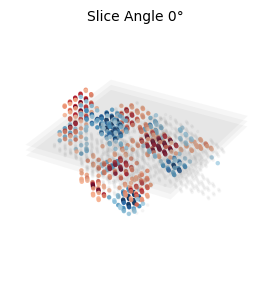

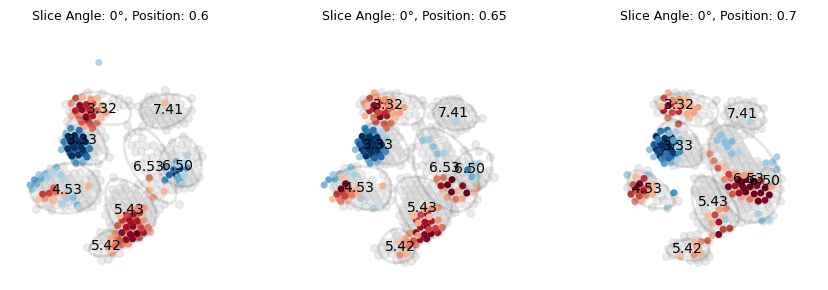

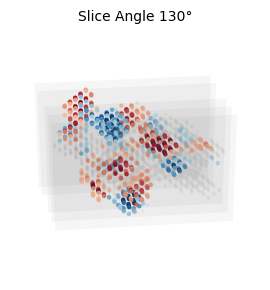

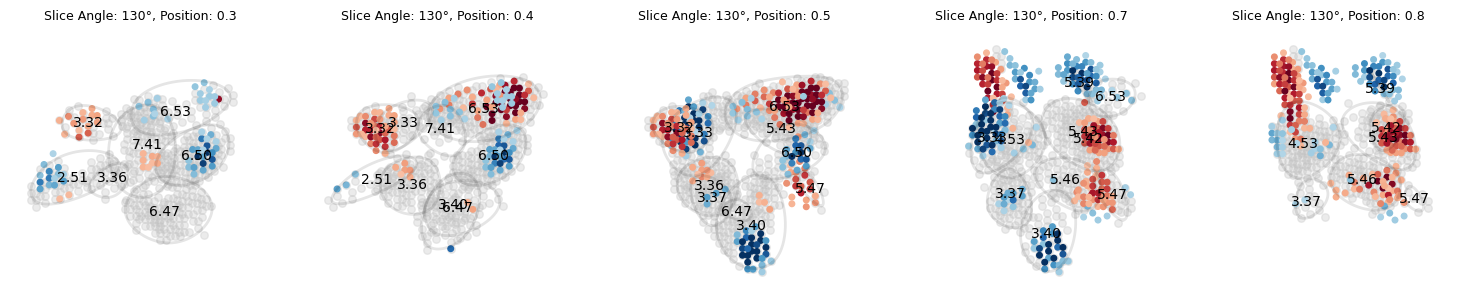

In [ ]:
"""
Export Voxel important slices per Odor

Exporting for TBM specific angles
"""
from scipy.spatial.transform import Rotation as R

importlib.reload(pf)

# PLOTLY and MATPLOLIB utilizes different 'camera' viewing. The angle will be different! Adjust as needed
default_rot = R.from_euler("xyz", [150, 320, 50], degrees=True)

importance_threshold = 3

IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}
IDX_TO_AA_RES_SINGLE = {i+1: sa.AA_THREE_TO_ONE.get(res) for i, res in enumerate(vf.AA_RES_OHE)}


_odor = 'TBM'    
_category = ODOR_TO_CAT.get(_odor)

# Make consesnus voxel instead of plotting all the individual voxels overlaying each other 
subset_voxels_info = voxels_info[voxels_info.odor_response.apply(lambda x: _category in [ODOR_TO_CAT.get(_x) for _x in x])].reset_index(names='voxel_idx')
# subset_voxels_info = voxels_info[voxels_info.odor_response.apply(lambda x: _odor in [_x for _x in x])].reset_index(names='voxel_idx')
plot_voxels = [voxels[i] for i in subset_voxels_info.voxel_idx]

# Convert voxel indices to residue names + numbers
for idx, row in subset_voxels_info.iterrows():
    res_to_map = [ IDX_TO_AA_RES.get(int(i[1])) + str(int(i[0])) for i in np.unique(list(plot_voxels[idx].values()), axis=0)]

    res_bw_dict = sa.map_residues_to_bw(residue_list = res_to_map,
                                        alignment = alignment, 
                                        target_seq_name = row.OR, 
                                        bw_positions = alignment_bw)
    
    # Update plot_voxel for the bw labels 
    updated_plot_voxels = {}
    for coord, tensor_val in plot_voxels[idx].items():
        res_num = int(tensor_val[0].item())
        res_idx = int(tensor_val[1].item())
        
        # Convert residue index -> AA letter
        aa = IDX_TO_AA_RES_SINGLE.get(res_idx, "?")
        res_key = f"{aa}{res_num}"
        
        # Lookup BW number if available
        bw_number = res_bw_dict.get(res_key, None)
        
        # Store as (res_num, res_idx, bw_number)
        updated_plot_voxels[coord] = (res_num, res_idx, bw_number)
        
    plot_voxels[idx] = updated_plot_voxels

# Generate consensus voxels 
plot_voxels_cons = vf.sparse_voxel_consensus_res(plot_voxels, threshold=0.15, use_bw=True)
positions = np.array(list(plot_voxels_cons))

X, Y, Z = positions[:,0], positions[:,1], positions[:,2]

# Apply default rotation to your voxel coordinates, set OR upright
coords = np.vstack([X, Y, Z ]).T         # shape (N, 3)
coords_rot = default_rot.apply(coords)
X, Y, Z = coords_rot[:,0], coords_rot[:,1], coords_rot[:,2]

res = np.array(list(plot_voxels_cons.values()))[:,0].astype(int)
cons_ratio = np.array(list(plot_voxels_cons.values()))[:,1].astype(float)
bw = np.array(list(plot_voxels_cons.values()))[:,2].astype(str)

color = cf.distinct_colors(list(vf.AA_RES_OHE), category='tab20')
IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}
# Protein consensus voxels
protein_points = np.column_stack([X, Y, Z])       # consensus residue coordinates
protein_res    = res                               # or bw, or tuple if you want labels

# Importance voxels
# Add importance as scatter
plot_voxel = odor_importances_zscore[_odor]
occupied_voxels = np.array(np.where((np.abs(plot_voxel) >= importance_threshold))).T
x, y, z = occupied_voxels[:, 0], occupied_voxels[:, 1], occupied_voxels[:, 2]
values = plot_voxel[x, y, z]

# Apply default rotation to your voxel coordinates, set OR upright
coords = np.vstack([x, y, z ]).T         # shape (N, 3)
coords_rot = default_rot.apply(coords)
x, y, z = coords_rot[:,0], coords_rot[:,1], coords_rot[:,2]


# Generate 3D and 2D slice images

fig3D, axes3D, fig2D, axes2D = pf.plt_voxel_slices(
    protein_points=np.column_stack([X, Y, Z]),
    protein_res=bw,
    imp_points=np.column_stack([x, y, z]),
    imp_values=values,
    imp_min=-10, imp_max=10,  
    angles=[0],
    slice_axis="z",
    slice_thickness=3,
    # n_slices=2,
    slice_position=[0.6, 0.65, 0.7],
    protein_color="silver",
    protein_size=30,
    imp_size=16,
    show_slice_planes=True, 
    cmap='RdBu_r',
    label_residues=True
)
fig2D.show()
fig3D.show()
# fig3D.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/scatter/odor/{_category}_{_odor}_Importance_ConsVox_slices_2.svg')
# fig2D.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/scatter/odor/{_category}_{_odor}_Importance_ConsVox_scatter_2D_2.svg')


fig3D, axes3D, fig2D, axes2D = pf.plt_voxel_slices(
    protein_points=np.column_stack([X, Y, Z]),
    protein_res=bw,
    imp_points=np.column_stack([x, y, z]),
    imp_values=values,
    imp_min=-10, imp_max=10,  
    angles=[130],
    slice_axis="x",
    slice_thickness=3,
    # n_slices=2,
    slice_position=[0.5, 0.7,0.8],
    protein_color="silver",
    protein_size=30,
    imp_size=16,
    show_slice_planes=True, 
    cmap='RdBu_r',
    label_residues=True
)
fig2D.show()
fig3D.show()
# fig3D.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/scatter/odor/{_category}_{_odor}_Importance_ConsVox_slices_3.svg')
# fig2D.savefig(f'/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/scatter/odor/{_category}_{_odor}_Importance_ConsVox_scatter_2D_3.svg')

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import imageio.v2 as imageio
from io import BytesIO
from PIL import Image
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.spatial.transform import Rotation as R


default_rot = R.from_euler("xyz", [150, 320, 50], degrees=True)

importance_threshold = 3

n_frames = 45  # frames for rotation
n_rotations = 3

IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}
IDX_TO_AA_RES_SINGLE = {i+1: sa.AA_THREE_TO_ONE.get(res) for i, res in enumerate(vf.AA_RES_OHE)}

# Prepare AA colors (same as your Plotly color dict)
aa_colors = cf.distinct_colors(list(vf.AA_RES_OHE), category='tab20')  # dict from AA letter -> color

for _odor in ODORS:
    
    if _odor != 'TBM': 
        continue    
    
    _category = ODOR_TO_CAT.get(_odor)

    # Skip existing category_odor
    # if len([_x for _x in os.listdir('/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/scatter_gif/') if f'{_category}_{_odor}' in _x ]) > 0: 
    #     continue
    
    # --- Consensus voxel residues ---
    # subset_voxels_info = voxels_info[
    #     voxels_info.odor_response.apply(lambda x: _category in [ODOR_TO_CAT.get(_x) for _x in x])
    # ].reset_index(names='voxel_idx')
    subset_voxels_info = voxels_info[
        voxels_info.odor_response.apply(lambda x: _odor in x)
    ].reset_index(names='voxel_idx')
    
    plot_voxels = [voxels[i] for i in subset_voxels_info.voxel_idx]
    
    if len(plot_voxels) == 0: 
        continue 

    # Convert voxel indices to residue names + numbers
    for idx, row in subset_voxels_info.iterrows():
        res_to_map = [ IDX_TO_AA_RES.get(int(i[1])) + str(int(i[0])) for i in np.unique(list(plot_voxels[idx].values()), axis=0)]

        res_bw_dict = sa.map_residues_to_bw(residue_list = res_to_map,
                                            alignment = alignment, 
                                            target_seq_name = row.OR, 
                                            bw_positions = alignment_bw)
        
        # Update plot_voxel for the bw labels 
        updated_plot_voxels = {}
        for coord, tensor_val in plot_voxels[idx].items():
            res_num = int(tensor_val[0].item())
            res_idx = int(tensor_val[1].item())
            
            # Convert residue index -> AA letter
            aa = IDX_TO_AA_RES_SINGLE.get(res_idx, "?")
            res_key = f"{aa}{res_num}"
            
            # Lookup BW number if available
            bw_number = res_bw_dict.get(res_key, None)
            
            # Store as (res_num, res_idx, bw_number)
            updated_plot_voxels[coord] = (res_num, res_idx, bw_number)
            
        plot_voxels[idx] = updated_plot_voxels

    plot_voxels_cons = vf.sparse_voxel_consensus_res(plot_voxels, threshold=0.15, use_bw=True)
    positions = np.array(list(plot_voxels_cons))

    X, Y, Z = positions[:,0], positions[:,1], positions[:,2]
    # Apply default rotation to your voxel coordinates, set OR upright
    # Pre-rotation
    coords = np.vstack([X, Y, Z]).T
    center_before = coords.mean(axis=0)
    coords_rot = default_rot.apply(coords)
    # center AFTER rotation (it moves!)
    center_after = coords_rot.mean(axis=0)
    coords_rot = coords_rot - center_after + center_before
    X, Y, Z = coords_rot[:,0], coords_rot[:,1], coords_rot[:,2]
    
    res = np.array(list(plot_voxels_cons.values()))[:,0].astype(int)
    cons_ratio = np.array(list(plot_voxels_cons.values()))[:,1].astype(float)
    bw = np.array(list(plot_voxels_cons.values()))[:,2].astype(str)
    colors1 = [aa_colors.get(IDX_TO_AA_RES.get(_res)) for _res in res]

    # --- Importance voxels ---
    # odors = [_k for _k, _v in ODOR_TO_CAT.items() if _v == _ODOR]
    # plot_voxel = np.sum(np.array([odor_importances_zscore[_odor] for _odor in odors]), axis=0) / len(odors)
    
    plot_voxel = odor_importances_zscore[_odor] # For individual odors
    
    occupied_voxels = np.array(np.where(np.abs(plot_voxel) >= importance_threshold)).T
    x, y, z = occupied_voxels[:,0], occupied_voxels[:,1], occupied_voxels[:,2]
    values2 = plot_voxel[x, y, z]
    
    # Apply default rotation to your voxel coordinates, set OR upright
    coords2 = np.vstack([x, y, z]).T
    center_before2 = coords2.mean(axis=0)
    coords2_rot = default_rot.apply(coords2)
    center_after2 = coords2_rot.mean(axis=0)
    coords2_rot = coords2_rot - center_after2 + center_before2
    x, y, z = coords2_rot[:,0], coords2_rot[:,1], coords2_rot[:,2]


    # Normalize importance for colormap
    # norm = mcolors.Normalize(vmin=-np.max(np.abs(values2)), vmax=np.max(np.abs(values2)))
    norm = mcolors.Normalize(vmin=-10, vmax=10)
    cmap = cm.get_cmap("RdBu_r")
    colors2 = cmap(norm(values2))

    # Determine plot limits (cube)
    all_coords = np.concatenate([positions, occupied_voxels], axis=0)
    min_val, max_val = all_coords.min(), all_coords.max()

    frames = []
    gif_path = f"/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/scatter_gif/{_category}_{_odor}_rotate.gif"

    for _rot in list(range(n_rotations)): 
        
        for angle in np.linspace(0, 360, n_frames):
            fig_mpl = plt.figure(figsize=(10,10), dpi=150)
            ax = fig_mpl.add_subplot(111, projection="3d")

            # Consensus residues scatter
            if _rot in [0,2,]: 
                ax.scatter(X, Y, Z, 
                        #    c=colors1, 
                           marker='o',
                        #    facecolor=colors1, edgecolors=colors1,
                           facecolor='#D3D3D3', edgecolors='#D3D3D3',
                           s=200, alpha=0.05)

            # Importance scatter
            if _rot in [1,2]: 
                ax.scatter(x, y, z, c=colors2, s=25, alpha=1)

            # Rotate
            ax.view_init(elev=20, azim=angle)

            # Set cube limits
            ax.set_xlim(min_val, max_val)
            ax.set_ylim(min_val, max_val)
            ax.set_zlim(min_val, max_val)
            ax.set_box_aspect([1,1,1])
            ax.set_axis_off()

            # Save frame in memory
            buf = BytesIO()
            plt.savefig(buf, format="png", bbox_inches="tight")
            buf.seek(0)
            img = Image.open(buf)
            frames.append(img)
            plt.close(fig_mpl)

    # Save GIF
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=100,  # 10 fps
        loop=0
    )
    print(f"Saved rotating GIF for {_category} {_odor}: {gif_path}")
    
    break


/tmp/ipykernel_3274203/440919748.py:116: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu_r")


Saved rotating GIF for Sulfurous TBM: /mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/scatter_gif/Sulfurous_TBM_rotate.gif


In [28]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import imageio.v2 as imageio
from io import BytesIO
from PIL import Image
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from skimage import measure
from scipy.spatial.transform import Rotation as R

default_rot = R.from_euler("xyz", [150, 320, 50], degrees=True)

importance_threshold = 3
n_frames = 45  # frames for rotation
n_rotations = 2

# Prepare AA colors (same as your Plotly color dict)
aa_colors = cf.distinct_colors(list(vf.AA_RES_OHE), category='tab20')  # dict from AA letter -> color

for _odor in ODORS:
    if _odor != 'TBM':
        continue
    _category = ODOR_TO_CAT.get(_odor)

    subset_voxels_info = voxels_info[voxels_info.odor_response.apply(lambda x: _odor in x)].reset_index(names='voxel_idx')
    plot_voxels = [voxels[i] for i in subset_voxels_info.voxel_idx]

    # map residues (your existing mapping)
    for idx, row in subset_voxels_info.iterrows():
        res_to_map = [IDX_TO_AA_RES.get(int(i[1])) + str(int(i[0])) for i in np.unique(list(plot_voxels[idx].values()), axis=0)]
        res_bw_dict = sa.map_residues_to_bw(residue_list=res_to_map,
                                           alignment=alignment,
                                           target_seq_name=row.OR,
                                           bw_positions=alignment_bw)
        updated_plot_voxels = {}
        for coord, tensor_val in plot_voxels[idx].items():
            res_num = int(tensor_val[0].item())
            res_idx = int(tensor_val[1].item())
            aa = IDX_TO_AA_RES_SINGLE.get(res_idx, "?")
            res_key = f"{aa}{res_num}"
            bw_number = res_bw_dict.get(res_key, None)
            updated_plot_voxels[coord] = (res_num, res_idx, bw_number)
        plot_voxels[idx] = updated_plot_voxels

    # Consensus voxel positions (original, integer grid coordinates)
    positions_orig = np.array(list(vf.sparse_voxel_consensus_res(plot_voxels, threshold=0.15, use_bw=True)))
    # positions_orig shape (N,3) integer coordinates (world grid)
    # Keep a copy for marching-cubes grid creation BEFORE rotation

    # --- Build marching-cubes mesh ONCE from the ORIGINAL integer grid ---
    # Shift to zero-based indices for volume creation
    min_pos = positions_orig.min(axis=0)
    positions_shift = positions_orig - min_pos
    positions_shift_int = np.round(positions_shift).astype(int)

    # build volume (pad +1)
    grid_size = positions_shift_int.max(axis=0) + 3
    volume = np.zeros(tuple(grid_size.astype(int)), dtype=np.uint8)
    volume[positions_shift_int[:, 0], positions_shift_int[:, 1], positions_shift_int[:, 2]] = 1.0

    # compute mesh on unrotated integer grid
    # note: use level=0.5 for binary volume
    verts_local, faces, normals, values = measure.marching_cubes(volume.astype(float), level=0.5)

    # convert local verts back to original world coordinates (undo shift)
    verts_world = verts_local + min_pos  # now verts_world in same coordinate space as positions_orig

    # --- Importance voxels (original grid coordinates) ---
    plot_voxel = odor_importances_zscore[_odor]
    occupied_voxels_orig = np.array(np.where(np.abs(plot_voxel) >= importance_threshold)).T  # shape (M,3), integer coords

    # color values for importance
    x0, y0, z0 = occupied_voxels_orig[:, 0], occupied_voxels_orig[:, 1], occupied_voxels_orig[:, 2]
    values2 = plot_voxel[x0, y0, z0]
    norm = mcolors.Normalize(vmin=-10, vmax=10)
    cmap = cm.get_cmap("RdBu_r")
    colors2 = cmap(norm(values2))

    # --- Compute a single global center to rotate everything about ---
    # using the original coords (before rotation)
    combined = np.vstack([positions_orig, occupied_voxels_orig])
    global_center = combined.mean(axis=0)

    # --- Rotate mesh verts and points about global_center using default_rot ---
    verts_rot = default_rot.apply(verts_world - global_center) + global_center
    positions_rot = default_rot.apply(positions_orig - global_center) + global_center
    occ_rot = default_rot.apply(occupied_voxels_orig - global_center) + global_center

    # Colors for consensus residues (you already had these)
    res = np.array(list(vf.sparse_voxel_consensus_res(plot_voxels, threshold=0.15, use_bw=True).values()))[:,0].astype(int) \
          if isinstance(plot_voxels_cons := vf.sparse_voxel_consensus_res(plot_voxels, threshold=0.15, use_bw=True), dict) else None
    # In case your existing mapping is used elsewhere, fallback:
    try:
        res = np.array(list(plot_voxels_cons.values()))[:,0].astype(int)
        colors1 = [aa_colors.get(IDX_TO_AA_RES.get(_res)) for _res in res]
    except Exception:
        colors1 = "lightgrey"

    # Determine plotting bounds based on rotated coordinates (so nothing gets cut off)
    all_rot = np.vstack([positions_rot, occ_rot, verts_rot])
    min_val, max_val = all_rot.min(), all_rot.max()

    frames = []
    gif_path = f"/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/scatter_gif/{_category}_{_odor}_rotate_surf.gif"

    # --- Now create GIF: mesh and importance points are fixed in object space; camera orbits ---
    for _rot in range(n_rotations):
        for angle in np.linspace(0, 360, n_frames, endpoint=False):
            fig_mpl = plt.figure(figsize=(10, 10), dpi=150)
            ax = fig_mpl.add_subplot(111, projection="3d")

            # Plot mesh (triangulated surface) — verts_rot is in global rotated coords
            ax.plot_trisurf(
                verts_rot[:, 0], verts_rot[:, 1], faces, verts_rot[:, 2],
                color="grey", lw=0.2, alpha=0.12, zorder=0
            )

            # Plot consensus voxels as subtle points if you want (optional)
            # ax.scatter(positions_rot[:,0], positions_rot[:,1], positions_rot[:,2],
            #            c='lightgrey', s=4, alpha=0.2)

            # Importance scatter (plot on top)
            if _rot in [1]:
                ax.scatter(occ_rot[:,0], occ_rot[:,1], occ_rot[:,2],
                           c=colors2, s=25, alpha=1, depthshade=True, zorder=2)

            # Camera rotation only (object stays fixed)
            ax.view_init(elev=20, azim=angle)

            # Set cube limits from rotated bounds so nothing is clipped
            ax.set_xlim(min_val, max_val)
            ax.set_ylim(min_val, max_val)
            ax.set_zlim(min_val, max_val)
            ax.set_box_aspect([1,1,1])
            ax.set_axis_off()

            # Save frame in memory
            buf = BytesIO()
            plt.savefig(buf, format="png", bbox_inches='tight', pad_inches=0)
            buf.seek(0)
            img = Image.open(buf).convert("RGBA")
            frames.append(img)
            plt.close(fig_mpl)

    # Save GIF
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=100,  # 10 fps
        loop=0
    )
    print(f"Saved rotating GIF for {_category} {_odor}: {gif_path}")

    break

/tmp/ipykernel_3274203/126039458.py:77: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu_r")


Saved rotating GIF for Sulfurous TBM: /mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/scatter_gif/Sulfurous_TBM_rotate_surf.gif


#### Importance snakeplot 

In [6]:
from Bio import SeqIO
import SequenceAlignment_functions as sa
"""
Read in sequence alignment file 
"""
fasta_path = '/mnt/data2/Justice/OR_learning/files/OR_seq/mouseOR_alignment.fasta'
Olfr_DL = np.load('/mnt/data2/Justice/OR_learning/files/Olfr_DL.npy', allow_pickle=True).item()

sequences = []
for record in SeqIO.parse(fasta_path, "fasta"):
    seq_str = str(record.seq)
    sequences.append((record.id, seq_str))

alignment_df = pd.DataFrame(
    [list(seq) for _, seq in sequences],
    columns=range(1, len(sequences[0][1]) + 1),
    index=[Olfr_DL.get(seq_id, seq_id).capitalize() for seq_id, _ in sequences]
)
alignment = alignment_df.apply(lambda row: ''.join(row.values), axis=1).to_dict()


"""
Generate BW position mapping 
"""
Or51E2_bw_positions = {"N41":'1.50', "D69": '2.50', "R121":'3.50', 
                       "V149":'4.50', "C178":'45.50', "D209":'5.50', 
                       "P253":'6.50', "P288":'7.50'}
Or51E2_bw_positions = {f"{_k[0]}{int(_k[1:])}": Or51E2_bw_positions[_k] for _k in Or51E2_bw_positions}

# Create alignment bw reference position, This position is True bw for the entire alignment 
alignment_bw = sa.update_bw_positions("Or51e2", alignment, Or51E2_bw_positions)


In [7]:
from collections import Counter

pd.set_option('display.max_columns', None)
percent_dashes = (alignment_df == '-').sum(axis=0) / alignment_df.shape[0] * 100
drop_threshold = 60

cols_to_drop = percent_dashes[percent_dashes >= drop_threshold].index.tolist()
consensus_df = alignment_df.drop(columns=cols_to_drop)
consensus_df.columns = list(range(len(consensus_df.columns))) # Re-name columns 

print("Filtered DataFrame shape:", consensus_df.shape)
consensus_letters = []
for col in consensus_df.columns:
    col_data = consensus_df[col]
    counts = Counter(col_data[col_data != '-'])
    if counts:
        consensus_letters.append(counts.most_common(1)[0][0])
    else:
        consensus_letters.append(' ')

# Rename to DL_OR instead 
# np.load('../files/Olfr_DL.npy', allow_pickle=False).item
consensus_df.head()

Filtered DataFrame shape: (1107, 317)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316
Or12d12,-,-,M,S,N,Q,T,S,V,T,E,F,L,L,L,G,V,T,D,I,Q,E,L,N,P,I,L,F,V,I,F,F,T,I,Y,F,I,N,I,T,G,N,G,A,I,L,M,I,V,I,L,D,P,L,H,S,-,P,M,Y,F,F,L,G,N,L,A,C,L,D,I,S,Y,S,T,V,T,V,P,K,L,L,Q,N,L,L,S,-,-,-,K,A,I,S,F,L,G,C,I,T,Q,L,H,F,F,H,F,L,G,S,T,E,T,M,L,L,P,V,M,A,F,D,R,F,V,A,I,C,R,P,L,H,Y,S,V,I,M,N,H,Q,L,C,I,H,M,T,V,T,I,W,T,L,G,-,F,F,H,A,L,L,H,S,V,M,T,S,R,L,S,F,C,G,P,N,-,V,H,H,F,F,C,D,I,K,P,L,L,D,L,A,C,G,N,T,E,L,N,L,W,L,L,N,T,V,T,G,T,I,A,L,T,S,F,F,L,I,F,L,S,Y,F,Y,I,I,T,N,L,L,L,K,T,R,S,C,S,M,H,K,A,L,S,T,C,A,S,H,F,M,V,V,V,L,F,Y,A,P,V,L,F,T,Y,I,R,P,A,S,G,-,-,S,S,L,D,Q,D,T,I,A,I,M,Y,S,V,V,T,P,A,L,N,P,L,I,Y,T,L,R,N,K,E,V,R,S,A,L,N,R,K,V,R,R,W,L,-,-,-,-,-
Or12d2,-,-,M,S,N,Q,T,S,V,T,E,F,L,L,L,G,V,T,D,V,Q,E,L,N,P,I,L,F,V,I,F,F,T,I,Y,F,V,N,I,T,G,N,G,A,I,L,M,I,V,I,L,D,P,L,H,S,-,P,M,Y,F,F,L,G,N,L,A,C,L,D,I,C,F,S,T,V,T,L,P,K,M,L,Q,N,L,L,S,-,-,-,K,A,I,S,F,L,G,C,I,T,Q,L,H,F,F,H,F,L,G,S,T,E,A,M,L,L,P,V,M,A,F,D,R,F,V,A,I,C,R,P,L,H,Y,S,V,I,M,N,H,Q,L,C,I,H,M,T,V,T,I,W,T,L,G,-,F,F,H,A,L,L,H,S,V,M,T,S,R,L,S,F,C,G,P,N,-,V,H,H,F,F,C,D,I,K,P,L,L,D,L,A,C,G,N,T,E,L,N,L,W,L,L,N,T,V,T,G,T,I,A,L,T,P,F,F,L,T,F,L,S,Y,F,Y,I,I,I,Y,L,L,L,K,T,R,S,C,S,M,H,K,A,L,S,T,C,A,S,H,F,M,V,V,F,L,F,Y,A,P,V,L,F,I,Y,I,S,P,T,S,G,-,-,S,S,L,D,Q,D,R,I,A,I,M,Y,S,V,V,T,P,A,L,N,P,L,I,Y,T,L,R,N,K,E,V,R,S,A,L,N,R,K,L,R,R,W,L,-,-,-,-,-
Or12d13,-,-,M,L,N,Q,T,S,V,T,E,F,I,L,L,G,V,R,D,I,Q,E,P,Q,P,F,L,F,A,I,F,F,T,I,Y,F,V,N,I,T,G,N,G,A,I,L,M,I,V,I,L,D,P,L,H,S,-,P,M,Y,F,F,L,G,N,L,A,C,L,D,I,S,Y,S,T,V,T,V,P,K,M,L,E,N,L,L,S,-,-,-,K,A,I,S,L,L,G,C,I,T,Q,L,H,F,F,H,F,L,G,T,T,E,S,L,L,L,A,V,M,A,F,D,R,F,V,A,I,C,R,P,L,H,Y,S,V,I,M,N,W,Q,V,C,I,L,M,A,V,T,I,W,T,I,A,-,F,L,H,A,L,L,H,S,V,M,T,S,R,L,S,F,C,G,L,N,-,I,H,H,F,F,C,D,V,K,P,L,L,E,L,A,C,G,N,T,E,L,N,L,W,L,L,N,T,V,T,G,T,I,A,S,V,P,F,F,L,T,F,L,S,Y,F,Y,I,I,T,Y,L,F,L,K,T,R,S,C,S,M,H,K,A,L,S,T,C,A,S,H,F,M,V,V,V,L,F,Y,A,P,V,L,F,T,Y,I,R,P,T,S,G,-,-,S,S,L,D,Q,D,R,I,A,I,M,Y,S,V,V,T,P,A,L,N,P,L,I,Y,T,L,R,N,K,E,V,R,S,A,L,N,R,K,V,R,R,C,L,L,L,E,E,I
Or12d17,-,-,M,E,N,S,T,S,V,D,E,F,L,L,L,G,L,T,S,V,Q,K,L,Q,P,I,I,F,V,M,F,L,T,I,Y,L,L,N,L,V,G,N,G,V,I,L,M,I,V,T,L,E,R,L,H,S,-,P,M,Y,F,F,L,G,N,L,S,C,L,D,I,C,Y,S,S,V,T,L,P,K,V,L,I,N,L,L,S,-,-,-,R,A,I,S,F,L,G,C,I,T,Q,L,Y,F,F,H,F,L,G,S,T,E,A,I,L,L,A,V,M,A,F,D,R,F,V,A,I,C,S,P,L,R,Y,T,A,I,M,N,P,Q,L,C,I,L,L,A,A,T,A,W,F,T,S,-,F,F,Y,A,L,L,H,S,V,M,T,A,H,L,N,F,C,H,S,H,-,L,S,H,F,F,C,D,V,K,P,L,L,E,V,A,C,G,N,T,V,L,N,Q,W,L,L,S,V,V,T,G,S,I,S,M,G,A,F,L,L,I,L,L,S,Y,F,Y,I,I,A,F,L,L,F,K,N,R,S,C,R,M,K,K,A,L,S,T,C,T,S,H,F,M,V,V,C,L,F,Y,G,P,V,G,F,T,Y,I,R,P,A,T,A,S,A,S,S,M,S,E,D,R,V,A,I,I,Y,S,A,V,T,P,V,L,N,P,L,I,Y,T,L,R,N,K,E,V,M,L,A,L,K,K,N,F,G,K,K,L,F,K,G,N,-
Or4p18,-,-,M,E,S,T,N,N,I,T,E,F,I,L,L,G,L,S,Q,N,K,K,I,K,A,L,C,F,L,M,F,L,F,C,Y,I,A,I,L,G,G,N,M,I,I,L,I,S,I,T,C,S,Q,I,E,-,Q,P,M,Y,F,F,L,N,Y,L,A,L,S,D,L,C,Y,T,S,T,V,T,P,K,F,L,T,D,L,L,V,-,-,-,N,K,I,S,Y,T,S,C,M,A,Q,L,F,T,M,H,F,F,G,G,I,E,I,L,I,L,T,V,M,A,Y,D,R,Y,V,A,I,C,K,P,L,H,Y,S

In [ ]:
"""
PER ODOR CATEGORY
Generate Snakeplot importance for both
    - strongest importance. 
    - conservation
Note that for a given BW there may be both importance assigned to different 3D spatial location ! 
"""
from collections import defaultdict, Counter
import snakeplot as sp 
from scipy.stats import binomtest

ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODOR_CATEGORIES)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODOR_CATEGORIES)}
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}
IDX_TO_AA_RES_SINGLE = {i+1: sa.AA_THREE_TO_ONE.get(res) for i, res in enumerate(vf.AA_RES_OHE)}

# Estimate empirical background from the entire alignment to calculate the signifcance of residue position
positive_residues = consensus_df[consensus_df.index.isin(list(ps6_df[ps6_df.activation_zscore >= 2].DL_OR.str.capitalize().unique()))].values.flatten()
aa_counts = Counter(positive_residues)
total = sum(aa_counts.values())
background_freqs = {aa: count/total for aa, count in aa_counts.items()}

for _category in ODOR_CATEGORIES:    
    # if _category != 'Sulfurous': # FOR DEBUGGING
    #     continue
    # Make consesnus voxel instead of plotting all the individual voxels overlaying each other 
    subset_voxels_info = voxels_info[voxels_info.odor_response.apply(lambda x: _category in [ODOR_TO_CAT.get(_x) for _x in x])].reset_index(names='voxel_idx')
    if len(subset_voxels_info) == 0: 
        continue

    plot_voxels = [voxels[i] for i in subset_voxels_info.voxel_idx]

    # Convert voxel indices to residue names + numbers
    for idx, row in subset_voxels_info.iterrows():
        res_to_map = [ IDX_TO_AA_RES.get(int(i[1])) + str(int(i[0])) for i in np.unique(list(plot_voxels[idx].values()), axis=0)]

        res_bw_dict = sa.map_residues_to_bw(residue_list = res_to_map,
                                            alignment = alignment, 
                                            target_seq_name = row.OR, 
                                            bw_positions = alignment_bw)
        # Update plot_voxel for the bw labels 
        updated_plot_voxels = {}
        for coord, tensor_val in plot_voxels[idx].items():
            res_num = int(tensor_val[0].item())
            res_idx = int(tensor_val[1].item())
            
            # Convert residue index -> AA letter
            aa = IDX_TO_AA_RES_SINGLE.get(res_idx, "?")
            res_key = f"{aa}{res_num}"
            
            # Lookup BW number if available
            bw_number = res_bw_dict.get(res_key, None)
            
            # Store as (res_num, res_idx, bw_number)
            updated_plot_voxels[coord] = (res_num, res_idx, bw_number) 
        plot_voxels[idx] = updated_plot_voxels

    cons_voxel = vf.sparse_voxel_consensus_res(plot_voxels, threshold=0.2, use_bw=True)
    
        
    # Consensus voxel: (x,y,z) -> (res_num, consensus_ratio, bw_number)
    threshold = 2
    # importance_vol = odor_importances_zscore[_category] # [(odor_importances[_odor] >= threshold) | (odor_importances[_odor]  <= -threshold)]
    
    odors = [_k for _k, _v in ODOR_TO_CAT.items() if _v == _category]
    importance_vol = np.sum(np.array([odor_importances_zscore[_odor] for _odor in odors]), axis=0) / len(odors)
    # Store per-BW importances
    bw_importances = defaultdict(list)

    for (x, y, z), (_, _, bw_num) in cons_voxel.items():
        if bw_num is None:  # skip if no BW mapping
            continue
        if (x >= importance_vol.shape[0]) | (y >= importance_vol.shape[0]) | (z >= importance_vol.shape[0]) :
            # HARD FIX for somehow if sparse voxels coordinates are > original voxel dim 32x32x32
            continue
        imp_val = importance_vol[x, y, z]
        if np.abs(imp_val) >= threshold:
            bw_importances[bw_num].append(imp_val)

    # Collapse per-BW: max abs or separate pos/neg
    bw_importances_strongest = {}
    for bw, vals in bw_importances.items():
        vals = np.array(vals)
        bw_importances_strongest[bw] = vals[np.argmax(np.abs(vals))]
        
    # Predetermined bw location for the default snake plot 
    bw_ref = {'1.50':42, '2.50':70, '3.50':123, '4.50':150, '45.50':181, '5.50':212, '6.50':256, '7.50':290} 

    # Get consensus_seq of responding ORs 
    alignment_df, consensus_seq, consensus_perc = sa.filter_get_conservation(consensus_df.loc[list(subset_voxels_info.OR)])
    snakeplot_df = sp.make_snakedf(snake_labels = consensus_seq)
    snakeplot_df = sp.snake_df_label_bw(snakeplot_df, bw_ref)
    snakeplot_df['Consensus_perc'] = np.round(consensus_perc,2)
    
    # Label residue locations that were used in voxels
    cons_voxel = vf.sparse_voxel_consensus_res(plot_voxels, threshold=0, use_bw=True)
    cons_voxel = np.array(list(cons_voxel.values()))[:,2]
    cons_voxel = [_v for _v in cons_voxel if _v is not None]
    snakeplot_df['voxel_res'] = False
    for _bw in np.unique(cons_voxel): 
        snakeplot_df.loc[snakeplot_df.bw == _bw, 'voxel_res'] = True
        
    snakeplot_df.loc[snakeplot_df.voxel_res, 'Importance'] = 0  # Iniitalize importance as 0 firs 
    for _bw in bw_importances_strongest: 
        snakeplot_df.loc[snakeplot_df.bw == _bw, 'Importance'] = abs(bw_importances_strongest[_bw])
        
    # # Importance plot
    ax = sp.plt_snakeplot(snakeplot_df, 
                        label_position=[[42, 70, 123, 150, 181, 212, 256, 290], 
                                        list(snakeplot_df[snakeplot_df.voxel_res].position)],
                        label_color=['#3892e8', 'black'], # Labels BW position
                        color_by="Importance", 
                        cmap='Reds', cmin=0, 
                        show_colorbar=True, 
                        figsize=(13,13),
                        title=f'{_category} Strongest BW Importance', title_text_size=15)
    
    ax.figure.savefig(f"/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/snakeplot/{_category}_Importance.png", dpi=300)
    
    # Conservation plot 
    ax = sp.plt_snakeplot(snakeplot_df, 
                        label_position=[42, 70, 123, 150, 181, 212, 256, 290],
                        label_color='#3892e8', # Labels BW position
                        color_by="Consensus_perc", 
                        cmap='bone_r', cmin=0, 
                        show_colorbar=True, 
                        figsize=(13,13),
                        title=f'{_category} Conservation', title_text_size=15)
    # break
    ax.figure.savefig(f"/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/consensus/snakeplot/{_category}_Consensus.png", dpi=300)
    
    
    # Calculate significance of conserved residues 
    for i in snakeplot_df.index: 
        k = sum(alignment_df[i].values == consensus_seq[i])
        n = len(alignment_df[i].values)
        p0 = background_freqs[consensus_seq[i]]

        bin_result = binomtest(k, n, 
                            p=p0, 
                            alternative='greater')
        snakeplot_df.loc[i, 'pvalue'] = bin_result.pvalue
    snakeplot_df.to_csv(f"/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/consensus/position_info/{_category}_snakeplot_df.csv")
    # break

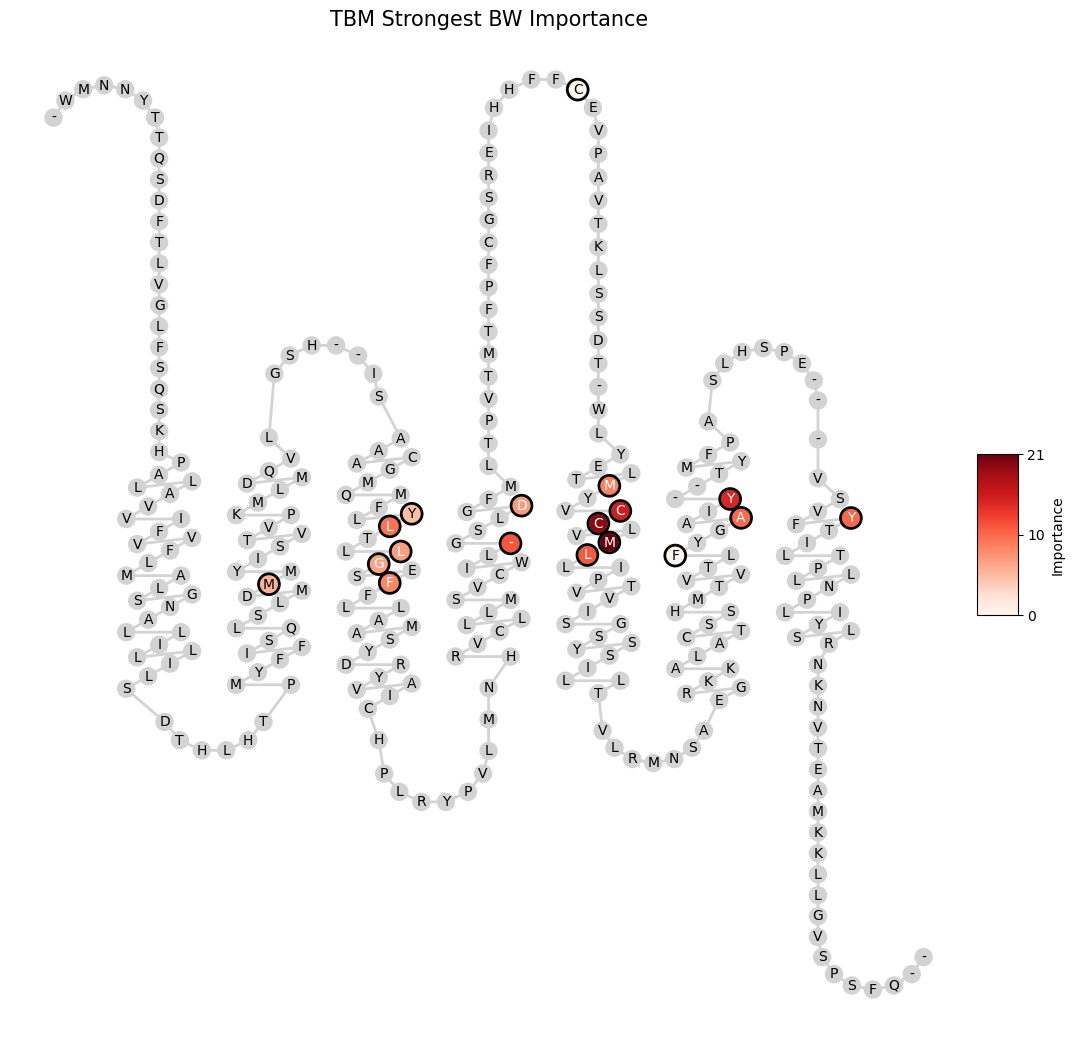

In [ ]:
"""
PER ODORS
Generate Snakeplot importance for both
    - strongest importance. 
    - conservation
Note that for a given BW there may be both importance assigned to different 3D spatial location ! 
"""
from collections import defaultdict, Counter
import snakeplot as sp 
from scipy.stats import binomtest

ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODOR_CATEGORIES)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODOR_CATEGORIES)}
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

IDX_TO_AA_RES = {i+1: aa for i, aa in enumerate(vf.AA_RES_OHE)}
IDX_TO_AA_RES_SINGLE = {i+1: sa.AA_THREE_TO_ONE.get(res) for i, res in enumerate(vf.AA_RES_OHE)}

# Estimate empirical background from the entire alignment to calculate the signifcance of residue position
positive_residues = consensus_df[consensus_df.index.isin(list(ps6_df[ps6_df.activation_zscore >= 2].DL_OR.str.capitalize().unique()))].values.flatten()
aa_counts = Counter(positive_residues)
total = sum(aa_counts.values())
background_freqs = {aa: count/total for aa, count in aa_counts.items()}

for _odor in ODORS:    
    _category = ODOR_TO_CAT.get(_odor)
    
    # if _odor != 'TBM': # FOR DEBUGGING
    #     continue 
    
    # Skip existing category_odor
    # if len([_x for _x in os.listdir('/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/snakeplot/odor/') if f'{_category}_{_odor}' in _x ]) > 0: 
    #     continue
    
    
    # Make consesnus voxel instead of plotting all the individual voxels overlaying each other 
    # subset_voxels_info = voxels_info[voxels_info.odor_response.apply(lambda x: _odor in [ODOR_TO_CAT.get(_x) for _x in x])].reset_index(names='voxel_idx')
    subset_voxels_info = voxels_info[voxels_info.odor_response.apply(lambda x: _odor in x)].reset_index(names='voxel_idx')
    if len(subset_voxels_info) == 0: 
        continue

    plot_voxels = [voxels[i] for i in subset_voxels_info.voxel_idx]

    # Convert voxel indices to residue names + numbers
    for idx, row in subset_voxels_info.iterrows():
        res_to_map = [ IDX_TO_AA_RES.get(int(i[1])) + str(int(i[0])) for i in np.unique(list(plot_voxels[idx].values()), axis=0)]

        res_bw_dict = sa.map_residues_to_bw(residue_list = res_to_map,
                                            alignment = alignment, 
                                            target_seq_name = row.OR, 
                                            bw_positions = alignment_bw)
        # Update plot_voxel for the bw labels 
        updated_plot_voxels = {}
        for coord, tensor_val in plot_voxels[idx].items():
            res_num = int(tensor_val[0].item())
            res_idx = int(tensor_val[1].item())
            
            # Convert residue index -> AA letter
            aa = IDX_TO_AA_RES_SINGLE.get(res_idx, "?")
            res_key = f"{aa}{res_num}"
            
            # Lookup BW number if available
            bw_number = res_bw_dict.get(res_key, None)
            
            # Store as (res_num, res_idx, bw_number)
            updated_plot_voxels[coord] = (res_num, res_idx, bw_number) 
        plot_voxels[idx] = updated_plot_voxels

    cons_voxel = vf.sparse_voxel_consensus_res(plot_voxels, threshold=0.2, use_bw=True)
    
        
    # Consensus voxel: (x,y,z) -> (res_num, consensus_ratio, bw_number)
    threshold = 2
    importance_vol = odor_importances_zscore[_odor] # [(odor_importances[_odor] >= threshold) | (odor_importances[_odor]  <= -threshold)]

    # Store per-BW importances
    bw_importances = defaultdict(list)

    for (x, y, z), (_, _, bw_num) in cons_voxel.items():
        if bw_num is None:  # skip if no BW mapping
            continue
        if (x >= importance_vol.shape[0]) | (y >= importance_vol.shape[0]) | (z >= importance_vol.shape[0]) :
            # HARD FIX for somehow if sparse voxels coordinates are > original voxel dim 32x32x32
            continue
        imp_val = importance_vol[x, y, z]
        if np.abs(imp_val) >= threshold:
            bw_importances[bw_num].append(imp_val)

    # Collapse per-BW: max abs or separate pos/neg
    bw_importances_strongest = {}
    for bw, vals in bw_importances.items():
        vals = np.array(vals)
        bw_importances_strongest[bw] = vals[np.argmax(np.abs(vals))]
        
    # Predetermined bw location for the default snake plot 
    bw_ref = {'1.50':42, '2.50':70, '3.50':123, '4.50':150, '45.50':181, '5.50':212, '6.50':256, '7.50':290} 

    # Get consensus_seq of responding ORs 
    alignment_df, consensus_seq, consensus_perc = sa.filter_get_conservation(consensus_df.loc[list(subset_voxels_info.OR)])
    snakeplot_df = sp.make_snakedf(snake_labels = consensus_seq)
    snakeplot_df = sp.snake_df_label_bw(snakeplot_df, bw_ref)
    snakeplot_df['Consensus_perc'] = np.round(consensus_perc,2)
    
    # Label residue locations that were used in voxels
    cons_voxel = vf.sparse_voxel_consensus_res(plot_voxels, threshold=0, use_bw=True)
    cons_voxel = np.array(list(cons_voxel.values()))[:,2]
    cons_voxel = [_v for _v in cons_voxel if _v is not None]
    snakeplot_df['voxel_res'] = False
    for _bw in np.unique(cons_voxel): 
        snakeplot_df.loc[snakeplot_df.bw == _bw, 'voxel_res'] = True
        
    snakeplot_df.loc[snakeplot_df.voxel_res, 'Importance'] = 0  # Iniitalize importance as 0 firs 
    for _bw in bw_importances_strongest: 
        snakeplot_df.loc[snakeplot_df.bw == _bw, 'Importance'] = abs(bw_importances_strongest[_bw])
        
    # # Importance plot
    ax = sp.plt_snakeplot(snakeplot_df, 
                        label_position=[
                            # [42, 70, 123, 150, 181, 212, 256, 290], 
                                        list(snakeplot_df[snakeplot_df.voxel_res].position)],
                        label_color=[
                            # '#3892e8', 
                            'black'], # Labels BW position
                        color_by="Importance", 
                        cmap='Reds', cmin=0, 
                        show_colorbar=True, 
                        figsize=(13,13),
                        title=f'{_odor} Strongest BW Importance', title_text_size=15)
    
    ax.figure.savefig(f"/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/snakeplot/odor/{_category}_{_odor}_Importance.png", dpi=300)
    # ax.figure.savefig(f"/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/Importance/snakeplot/odor/{_category}_{_odor}_Importance2.png", dpi=300)

    # Conservation plot 
    ax = sp.plt_snakeplot(snakeplot_df, 
                        label_position=[42, 70, 123, 150, 181, 212, 256, 290],
                        label_color='#3892e8', # Labels BW position
                        color_by="Consensus_perc", 
                        cmap='bone_r', cmin=0, 
                        show_colorbar=True, 
                        figsize=(13,13),
                        title=f'{_odor} Conservation', title_text_size=15)
    # break
    ax.figure.savefig(f"/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/consensus/snakeplot/odor/{_category}_{_odor}_Consensus.png", dpi=300)
    
    
    # Calculate significance of conserved residues 
    for i in snakeplot_df.index: 
        k = sum(alignment_df[i].values == consensus_seq[i])
        n = len(alignment_df[i].values)
        p0 = background_freqs[consensus_seq[i]]

        bin_result = binomtest(k, n, 
                            p=p0, 
                            alternative='greater')
        snakeplot_df.loc[i, 'pvalue'] = bin_result.pvalue
    snakeplot_df.to_csv(f"/mnt/data2/Justice/OR_learning/output/spatialESM_ChemClass/consensus/position_info/odor/{_category}_{_odor}_snakeplot_df.csv")
    # break